<>:556: SyntaxWarning: invalid escape sequence '\s'
<>:1706: SyntaxWarning: invalid escape sequence '\p'
<>:556: SyntaxWarning: invalid escape sequence '\s'
<>:1706: SyntaxWarning: invalid escape sequence '\p'
/tmp/ipykernel_472/2924325071.py:556: SyntaxWarning: invalid escape sequence '\s'
  log m_i^{PoU} pprox log 	ilde m_i - log \sum_j H(mu_i; j),
/tmp/ipykernel_472/2924325071.py:1706: SyntaxWarning: invalid escape sequence '\p'
  H_i(x) \propto exp[-0.5 (x - x_i)^T P_i (x - x_i)].


Generating Darcy configuration for 100 observations...
Loaded source basis with 100 modes.
Truncated to 32 modes.
Saved 'data/Basis.csv'
Saved 'data/obs_locations.csv'
Configuration generation complete.

Initializing JAX Darcy Flow Physics Engine...
Basis file found with 32 modes. Truncating to first 32...
Loaded Final Basis shape: (1024, 32)
Loaded Final Obs Indices shape: (100,)
Darcy Flow Physics Engine Loaded Successfully.
Forward map 'solve_forward' is ready. Input dim: 32, Output dim: 100
Global Dtype set to: torch.float64
Device: cuda
--- Setting up 32D Darcy Flow Inverse Problem ---
Generating 10000 reference particles for the base bank...
Precomputing base reference bank with 10000 particles...
  [base] Calculating Likelihoods / Grads (batched)...
  [base] Calculating Hessians (batched)...
    [base] Hessian batch 0/10000...
    [base] Hessian batch 500/10000...
    [base] Hessian batch 1000/10000...
    [base] Hessian batch 1500/10000...
    [base] Hessian batch 2000/10000...

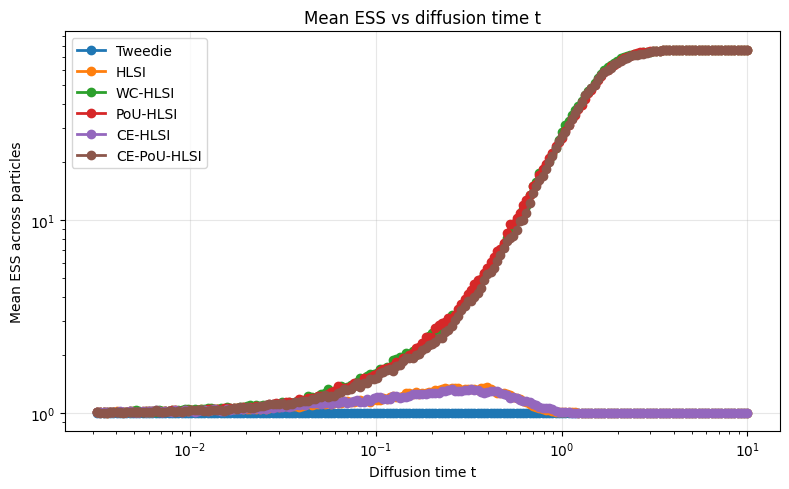


=== Evaluation (latent/coordinate metrics) ===
Method                   | RMSE_alpha | RelL2_alpha | MMD->Prior     | KSD        | KLdiag    
-----------------------------------------------------------------------------------------------
Prior                    | 0.4474     | 0.9507      | 0.0000         | 7.5650     | 79.4733   
Tweedie                  | 0.9387     | 1.9948      | 0.6769         | 1990.9227  | 140.6653  
Blend                    | 0.5687     | 1.2085      | 0.3777         | 2045131724.1403 | 299525.5434
HLSI                     | 0.3961     | 0.8417      | 0.2532         | 20.7683    | 53.0004   
WC-HLSI                  | 0.3947     | 0.8388      | 0.2219         | 43.4830    | 58.9807   
PoU-HLSI                 | 0.4005     | 0.8511      | 0.2214         | 43.4725    | 59.1564   
CE-HLSI                  | 0.3943     | 0.8379      | 0.2531         | 20.9848    | 53.1121   
CE-PoU-HLSI              | 0.4125     | 0.8765      | 0.2735         | 48.5399    | 61.742

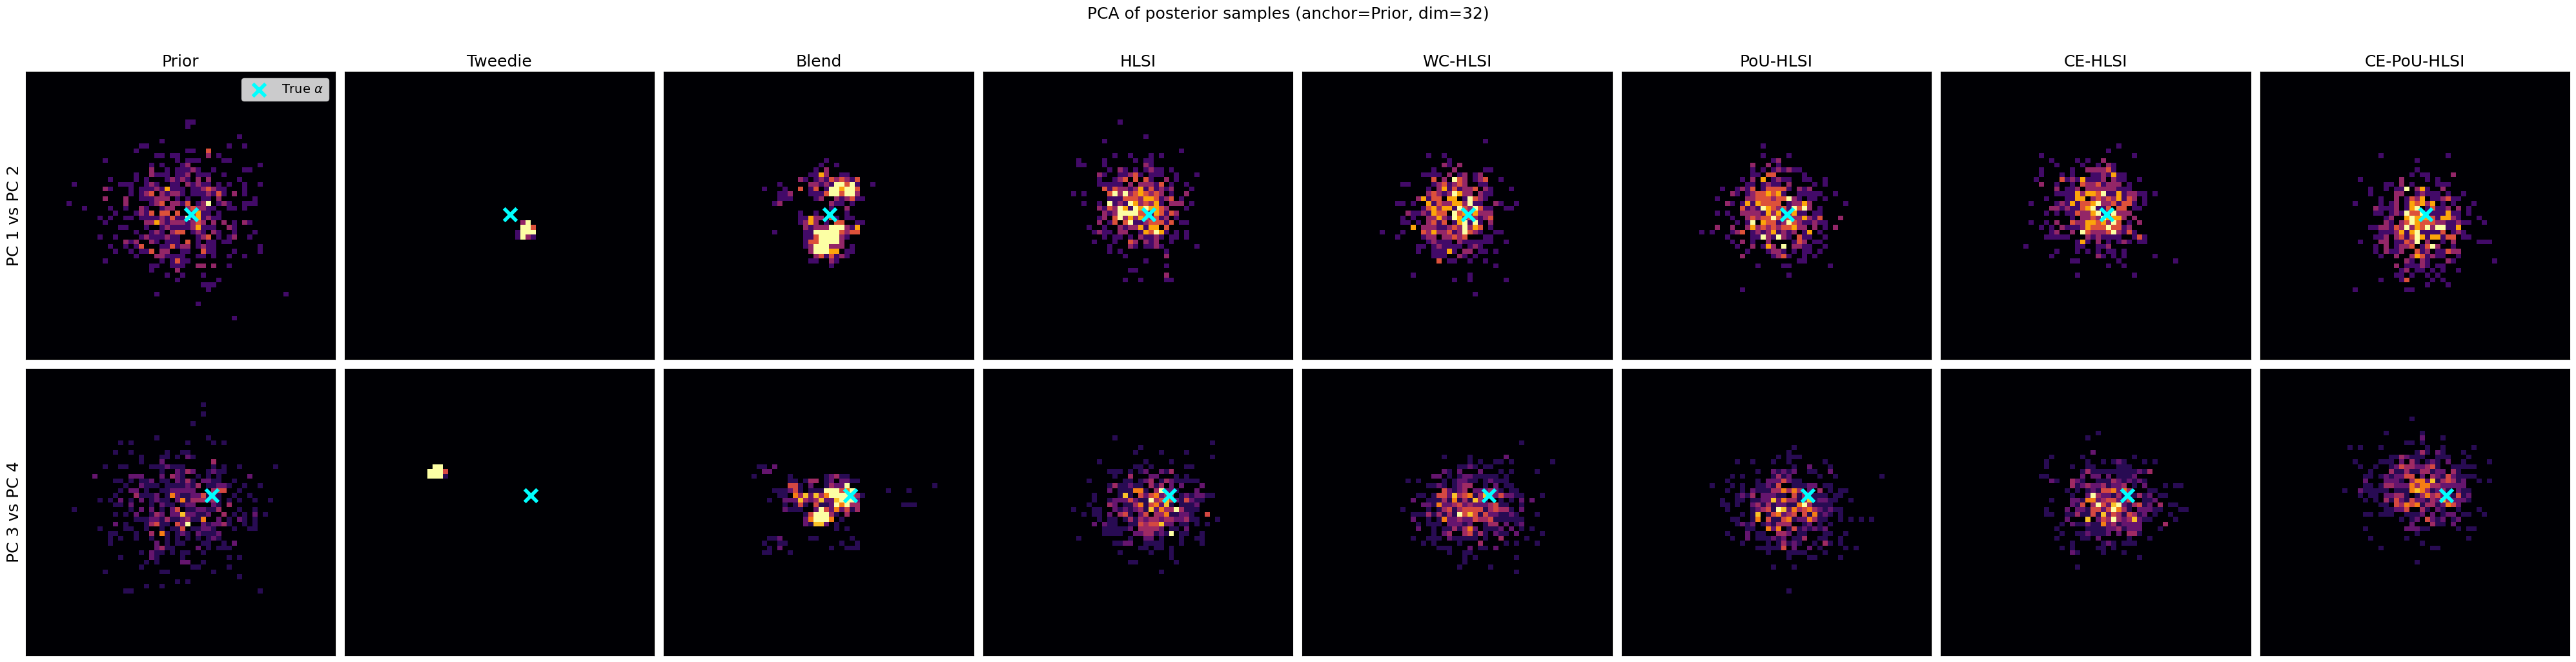


=== Physical Parameter Space Metrics (Log-Permeability + Forward) ===
Method                   | Inv RelL2(%) | RMSE_alpha   | FwdRelErr   
----------------------------------------------------------------------------
Prior                    | 80.8887      | 4.4739e-01   | 7.6777e-02  
Tweedie                  | 165.8684     | 9.3872e-01   | 1.0163e-01  
Blend                    | 141.9256     | 5.6848e-01   | 2.6294e-01  
HLSI                     | 70.6247      | 3.9608e-01   | 6.1446e-02  
WC-HLSI                  | 71.8479      | 3.9471e-01   | 7.3015e-02  
PoU-HLSI                 | 72.3981      | 4.0050e-01   | 7.3426e-02  
CE-HLSI                  | 69.8360      | 3.9429e-01   | 6.0537e-02  
CE-PoU-HLSI              | 72.6612      | 4.1248e-01   | 6.7218e-02  

=== Final Darcy metrics (paper-ready) ===
Method                   | RMSE_a    | RMSE_m    | FwdRel    | MMD->Prior   | KSD       | KLdiag   
-------------------------------------------------------------------------------

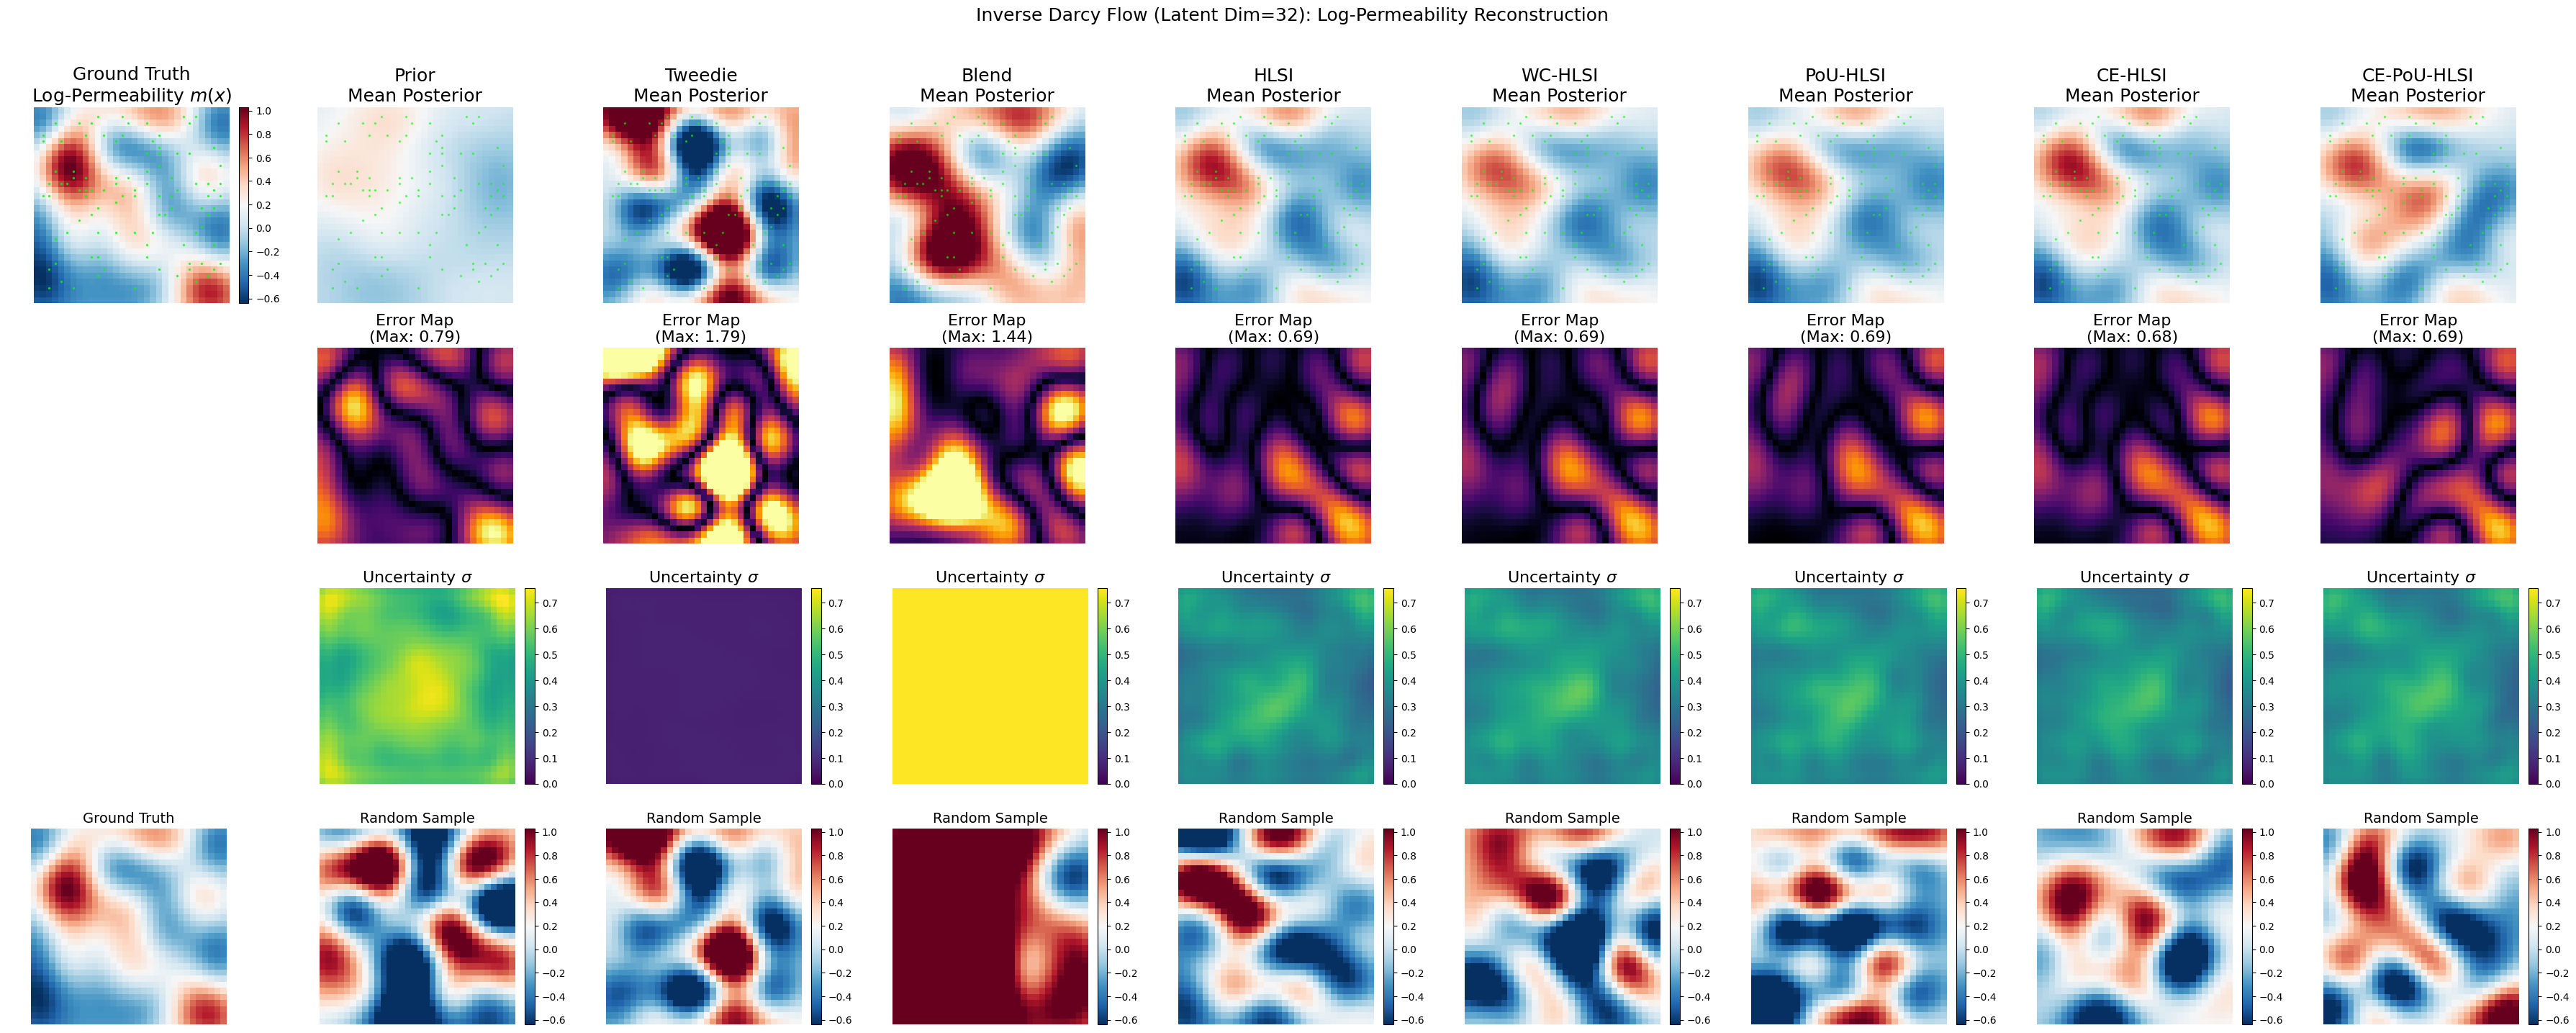


Visualizing Pressure Fields...


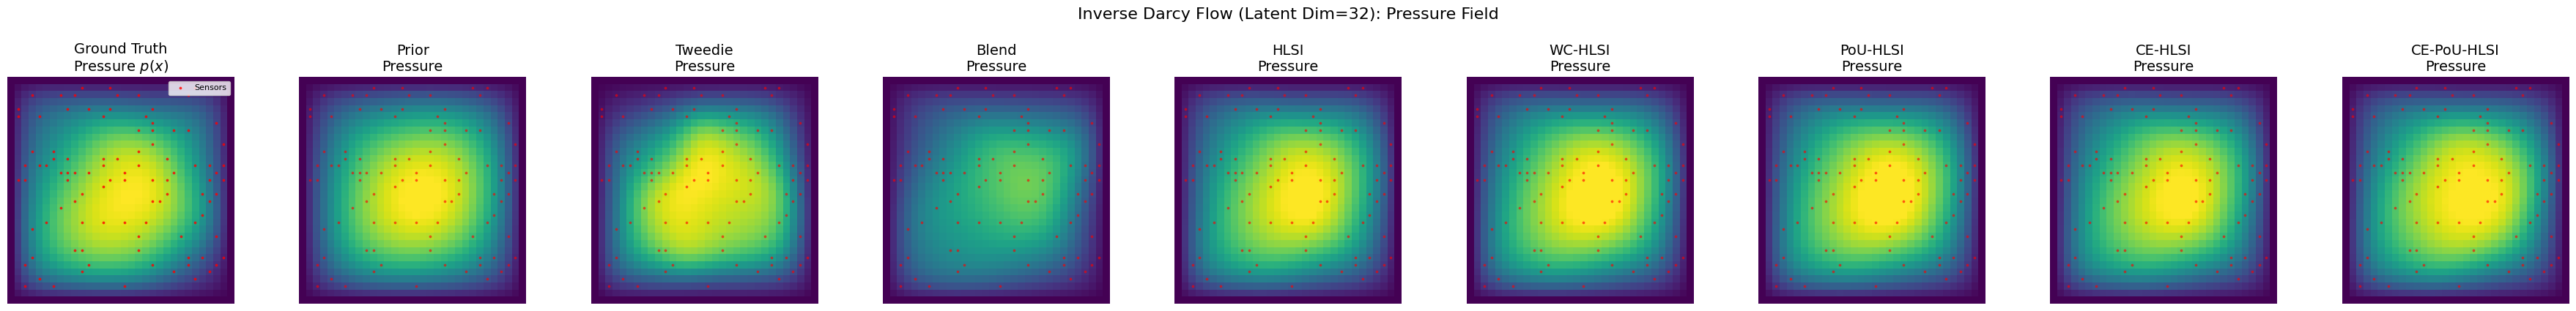


Visualizing Permeability exp(m) Fields...


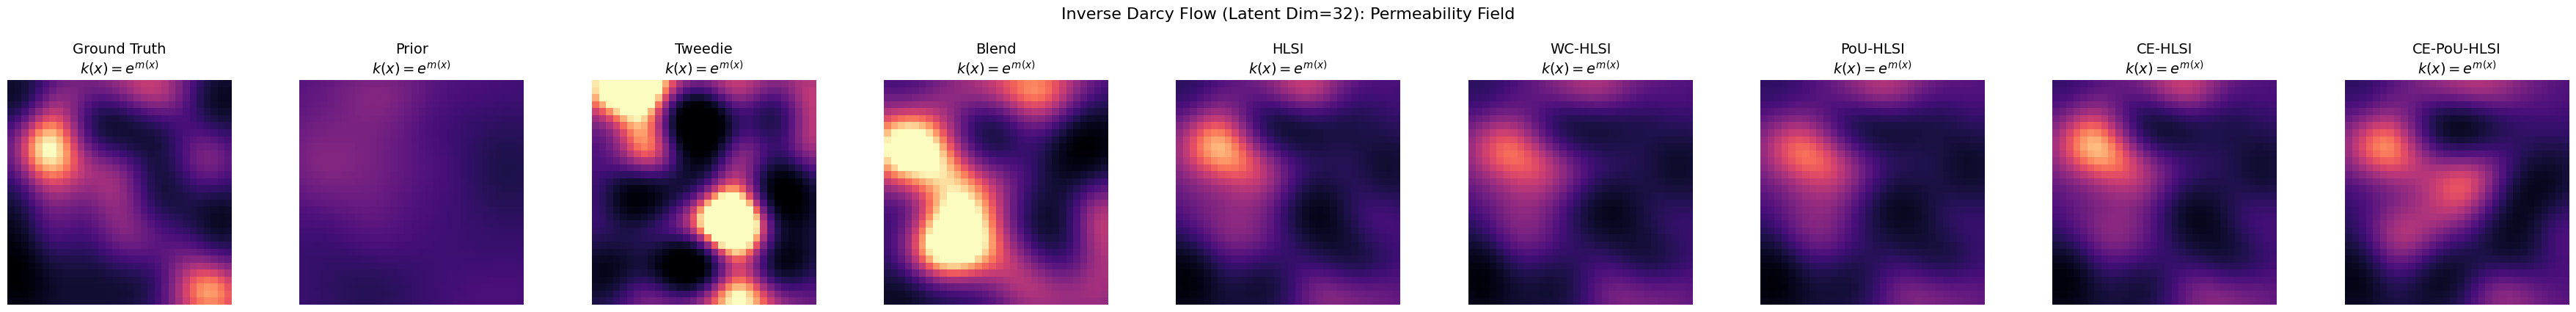


=== Darcy Flow HLSI Pipeline Complete ===


In [ ]:
# -*- coding: utf-8 -*-
"""Darcy_wc_ce_hlsi.ipynb

Automatically generated by Colab.

Original file is located at
    https://colab.research.google.com/drive/129GPfJ9seNMb7z8bjRArsjlVo0O_XDMA
"""

# One-time: generate KL basis for Darcy prior
import numpy as np
from scipy.spatial.distance import cdist
import os


os.makedirs('data', exist_ok=True)

N = 32
x = np.linspace(0, 1, N)
X, Y = np.meshgrid(x, x)
coords = np.column_stack([X.ravel(), Y.ravel()])  # (1024, 2)

# Matérn-like covariance: C(r) = sigma^2 * exp(-r/ell)
ell = 0.2   # correlation length
sigma_prior = 1.0
dists = cdist(coords, coords)
C = sigma_prior**2 * np.exp(-dists / ell)

# Eigendecompose
eigvals, eigvecs = np.linalg.eigh(C)
idx = np.argsort(eigvals)[::-1]
eigvals = eigvals[idx]
eigvecs = eigvecs[:, idx]

# KL modes: phi_i * sqrt(lambda_i), keep top q_max
q_max = 100
Basis_Modes = eigvecs[:, :q_max] * np.sqrt(eigvals[:q_max])
np.savetxt('data/Darcy_Basis_Modes.csv', Basis_Modes, delimiter=',')


###################################################################################################################################

# -*- coding: utf-8 -*-
"""Darcy_batched_hlsi.ipynb

Automatically generated by Colab.

Original file is located at
    https://colab.research.google.com/drive/1S4_amyhTBeteuk5q1IbMy_hRpEpv3HnG
"""

# -*- coding: utf-8 -*-
"""
darcy_solve_hlsi_banded.py

HLSI (Hessian-Laplace Score Identity) posterior sampling for the
Darcy flow inverse problem.

Refactored from NS_solve_hlsi_banded.ipynb.
Physics layer (Sections 1–2) replaced; HLSI core (Sections 3–6) unchanged.

PDE:   -div( exp(m(x)) grad p(x) ) = f(x)   on [0,1]^2,  p|_boundary = 0
Unknown:  log-permeability field  m(x) = sum_i sqrt(lam_i) phi_i(x) alpha_i
Prior:    alpha ~ N(0, I)  (KL coefficients)
Data:     noisy pressure measurements at sparse sensor locations
"""

import os
# Important: these must be set before importing jax, otherwise JAX may
# preallocate most of the GPU and starve PyTorch/HLSI. In a notebook, restart
# the runtime after adding these lines.
os.environ.setdefault("XLA_PYTHON_CLIENT_PREALLOCATE", "false")
os.environ.setdefault("XLA_PYTHON_CLIENT_MEM_FRACTION", "0.20")
import jax
import jax.numpy as jnp
import numpy as np
import pandas as pd
from functools import partial

# ==========================================
# CONFIGURATION GENERATOR (Darcy)
# ==========================================

# 1. Parameters
N = 32                     # Grid size 32x32
num_observation = 100      # Number of pressure sensors
num_truncated_series = 32  # Latent dimension (KL modes)
seed = 42

print(f"Generating Darcy configuration for {num_observation} observations...")

# 2. Generate Random Observation Locations (interior only for Dirichlet BC)
key = jax.random.PRNGKey(seed)

# Build interior index set: exclude boundary rows/cols for Dirichlet BC
interior_mask = np.ones((N, N), dtype=bool)
interior_mask[0, :] = False
interior_mask[-1, :] = False
interior_mask[:, 0] = False
interior_mask[:, -1] = False
interior_indices = jnp.array(np.where(interior_mask.ravel())[0])

obs_indices = jax.random.choice(key, interior_indices,
                                shape=(num_observation,), replace=False)
obs_indices = np.array(obs_indices)

# 3. Load and Truncate Basis
try:
    df_modes = pd.read_csv('data/Darcy_Basis_Modes.csv', header=None)
    if isinstance(df_modes.iloc[0, 0], str):
        df_modes = pd.read_csv('data/Darcy_Basis_Modes.csv')

    modes_raw = df_modes.to_numpy().flatten()
    full_dim = N * N
    num_modes_available = modes_raw.size // full_dim
    full_basis = modes_raw.reshape((full_dim, num_modes_available))

    basis_truncated = full_basis[:, :num_truncated_series]

    print(f"Loaded source basis with {num_modes_available} modes.")
    print(f"Truncated to {num_truncated_series} modes.")

    os.makedirs('data', exist_ok=True)
    pd.DataFrame(basis_truncated).to_csv('data/Basis.csv', index=False, header=False)
    print("Saved 'data/Basis.csv'")

    pd.DataFrame(obs_indices).to_csv('data/obs_locations.csv', index=False, header=False)
    print("Saved 'data/obs_locations.csv'")

except FileNotFoundError:
    raise FileNotFoundError(
        "Could not find 'data/Darcy_Basis_Modes.csv'. "
        "Generate it first with the KL eigendecomposition script."
    )

print("Configuration generation complete.\n")


# ==========================================
# Hardware setup
# ==========================================
jax.config.update("jax_enable_x64", True)

print("Initializing JAX Darcy Flow Physics Engine...")

# ==========================================
# 1. LOAD PHYSICAL CONSTANTS & BASIS
# ==========================================

N = 32
dimension_of_PoI = N ** 2   # 1024
num_observation = 100
num_truncated_series = 32    # KL modes for log-permeability

# Load Basis and Observation Locations
try:
    df_Basis = pd.read_csv('data/Basis.csv', header=None)
    df_obs = pd.read_csv('data/obs_locations.csv', header=None)

    basis_raw = df_Basis.to_numpy().flatten()
    if basis_raw.size % dimension_of_PoI == 1:
        print(f"Basis size is {basis_raw.size}. Detecting header artifact. Dropping first element.")
        basis_raw = basis_raw[1:]
    basis_raw = basis_raw.astype(np.float64)

    total_elements = basis_raw.size
    if total_elements % dimension_of_PoI != 0:
        raise ValueError(
            f"Basis file size {total_elements} is not divisible by "
            f"grid size {dimension_of_PoI} ({N}x{N})."
        )

    num_modes_in_file = total_elements // dimension_of_PoI
    full_basis = np.reshape(basis_raw, (dimension_of_PoI, num_modes_in_file))

    print(f"Basis file found with {num_modes_in_file} modes. "
          f"Truncating to first {num_truncated_series}...")
    Basis = jnp.array(full_basis[:, :num_truncated_series])

    obs_raw = df_obs.to_numpy().flatten()
    if obs_raw.size == num_observation + 1:
        print("Obs file has 1 extra element. Dropping first element.")
        obs_raw = obs_raw[1:]
    obs_raw = obs_raw.astype(int)
    if obs_raw.size > num_observation:
        print(f"Obs file has {obs_raw.size} locations. Using first {num_observation}.")
        obs_raw = obs_raw[:num_observation]
    elif obs_raw.size < num_observation:
        raise ValueError(f"Obs file only has {obs_raw.size} locations, need {num_observation}.")

    obs_locations = jnp.array(obs_raw, dtype=int)

    print(f"Loaded Final Basis shape: {Basis.shape}")
    print(f"Loaded Final Obs Indices shape: {obs_locations.shape}")

except FileNotFoundError:
    raise FileNotFoundError(
        "Please ensure 'data/Basis.csv' and 'data/obs_locations.csv' exist."
    )
except Exception as e:
    print(f"Error loading data: {e}")
    raise


# ==========================================
# 2. DEFINE FORWARD SOLVER (Darcy Flow)
# ==========================================
# PDE:  -div( k(x) grad p ) = f   on [0,1]^2,  p = 0 on boundary
# where k(x) = exp(m(x)),  m parameterized via KL expansion.
#
# Discretization: 2nd-order finite differences with variable coefficient.
# Interior solve via direct linear solve (dense, fine for N<=64).
# ==========================================

h = 1.0 / (N - 1)                     # grid spacing
x_1d = jnp.linspace(0, 1, N)
X_grid, Y_grid = jnp.meshgrid(x_1d, x_1d)

# Forcing: f(x,y) = 1.0  (constant unit source — simple and standard)
f_darcy = jnp.ones((N, N))

# Interior mask: boolean (N,N) — True for interior DOFs
_int_mask = jnp.zeros((N, N), dtype=bool)
_int_mask = _int_mask.at[1:-1, 1:-1].set(True)
_int_rows, _int_cols = jnp.where(_int_mask)
n_int = _int_rows.shape[0]                   # (N-2)^2

# Map (i,j) -> interior DOF index, -1 for boundary
_int_id = -jnp.ones((N, N), dtype=jnp.int32)
_int_id = _int_id.at[_int_rows, _int_cols].set(jnp.arange(n_int, dtype=jnp.int32))


def _assemble_darcy_vectorized(k_field):
    """
    Vectorized assembly of (n_int x n_int) stiffness matrix.
    Uses the 5-point FD stencil with harmonic-averaged permeability.
    """
    h2 = h * h

    # Harmonic averages at cell faces
    # k_xp[i,j] = harmonic avg of k[i,j] and k[i+1,j], shape (N-1, N)
    k_xp = 2.0 * k_field[:-1, :] * k_field[1:, :] / (k_field[:-1, :] + k_field[1:, :] + 1e-30)
    # k_yp[i,j] = harmonic avg of k[i,j] and k[i,j+1], shape (N, N-1)
    k_yp = 2.0 * k_field[:, :-1] * k_field[:, 1:] / (k_field[:, :-1] + k_field[:, 1:] + 1e-30)

    # For interior node (i,j), i in [1,N-2], j in [1,N-2]:
    #   c_E = k_xp[i, j]   / h^2   (coupling to (i+1, j))
    #   c_W = k_xp[i-1, j] / h^2   (coupling to (i-1, j))
    #   c_N = k_yp[i, j]   / h^2   (coupling to (i, j+1))
    #   c_S = k_yp[i, j-1] / h^2   (coupling to (i, j-1))
    #   diag = -(c_E + c_W + c_N + c_S)
    #   Row equation: -diag*p_{i,j} - c_E*p_{i+1,j} - ... = f_{i,j}
    #   i.e.  (c_E + c_W + c_N + c_S)*p_{i,j} - c_E*p_{i+1,j} - ... = f_{i,j}

    ir = _int_rows   # shape (n_int,)
    ic = _int_cols

    c_E = k_xp[ir, ic] / h2       # coupling east  (i+1, j)
    c_W = k_xp[ir - 1, ic] / h2   # coupling west  (i-1, j)
    c_N = k_yp[ir, ic] / h2       # coupling north (i, j+1)
    c_S = k_yp[ir, ic - 1] / h2   # coupling south (i, j-1)

    diag = c_E + c_W + c_N + c_S

    # Build matrix row by row using fancy indexing
    # Each interior DOF idx has up to 4 neighbors
    idx = jnp.arange(n_int)

    # Neighbor DOF indices (-1 means boundary = Dirichlet zero, no coupling)
    nbr_E = _int_id[ir + 1, ic]
    nbr_W = _int_id[ir - 1, ic]
    nbr_N = _int_id[ir, ic + 1]
    nbr_S = _int_id[ir, ic - 1]

    # Assemble dense matrix
    A = jnp.zeros((n_int, n_int))

    # Diagonal
    A = A.at[idx, idx].add(diag)

    # Off-diagonal: only where neighbor is interior (id >= 0)
    mask_E = nbr_E >= 0
    A = A.at[idx, nbr_E].add(jnp.where(mask_E, -c_E, 0.0))

    mask_W = nbr_W >= 0
    A = A.at[idx, nbr_W].add(jnp.where(mask_W, -c_W, 0.0))

    mask_N = nbr_N >= 0
    A = A.at[idx, nbr_N].add(jnp.where(mask_N, -c_N, 0.0))

    mask_S = nbr_S >= 0
    A = A.at[idx, nbr_S].add(jnp.where(mask_S, -c_S, 0.0))

    # RHS: f values at interior nodes
    # (Boundary contributions are zero because p=0 on boundary)
    rhs = f_darcy[ir, ic]

    return A, rhs


@jax.jit
def solve_forward(alpha):
    """
    The Forward Map F(alpha) for Darcy flow.
    Input:  alpha — KL coefficients, shape (q,)
    Output: y_pred — pressure at sensor locations, shape (n_obs,)
    """
    # 1. Map KL coefficients to log-permeability field
    log_k = jnp.reshape(Basis @ alpha, (N, N))
    k_field = jnp.exp(log_k)

    # 2. Assemble and solve  -div(k grad p) = f
    A, rhs = _assemble_darcy_vectorized(k_field)
    p_int = jnp.linalg.solve(A, rhs)

    # 3. Scatter interior solution back to full grid (boundary = 0)
    p_full = jnp.zeros(N * N)
    int_flat = _int_rows * N + _int_cols
    p_full = p_full.at[int_flat].set(p_int)

    # 4. Extract observations at sensor locations
    y_obs = p_full[obs_locations]
    return y_obs


print("Darcy Flow Physics Engine Loaded Successfully.")
print(f"Forward map 'solve_forward' is ready. "
      f"Input dim: {num_truncated_series}, Output dim: {num_observation}")


# ==========================================
# 3. BRIDGE: JAX PHYSICS -> PYTORCH SAMPLER
# ==========================================

import torch
import jax
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt
import time
import math

jax.config.update("jax_enable_x64", True)
torch.set_default_dtype(torch.float64)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Global Dtype set to: {torch.get_default_dtype()}")
print(f"Device: {device}")

# Configuration for Darcy Flow
ACTIVE_DIM = num_truncated_series  # Latent dimension (KL modes)
NOISE_STD = 0.005               # Observation noise std

# Hessian spectral band for HLSI (Section 5.3: Spectral band truncation)
HESS_MIN = 1e-4   # Lower bound: eigenvalues below this are too sloppy
HESS_MAX = 1e6    # Upper bound: eigenvalues above this are too stiff

# GNL (Gauss-Newton likelihood factorization) settings
GNL_PILOT_N = 1024              # pilot prior particles used to define the expansion point
GNL_STIFF_LAMBDA_CUT = HESS_MAX # absorb directions whose GN posterior eigenvalue exceeds this
GNL_USE_DOMINANT_PARTICLE_NEWTON = True


# A. Define JAX Likelihood Functions

@jax.jit
def darcy_log_likelihood_jax(alpha_k, y_obs_jax, sigma):
    y_pred = solve_forward(alpha_k)
    resid = y_pred - y_obs_jax
    return -jnp.sum(resid ** 2) / (2.0 * sigma ** 2)

# Gradient
darcy_grad_lik_jax = jax.jit(jax.grad(darcy_log_likelihood_jax, argnums=0))

# --- Hessian options ---
USE_GAUSS_NEWTON_HESSIAN = True  # recommended

# Jacobian of forward map
solve_forward_jac_jax = jax.jit(jax.jacfwd(solve_forward))

@jax.jit
def darcy_hess_lik_gn_jax(alpha_k, y_obs_jax, sigma):
    """Gauss-Newton Hessian of log-likelihood: -(J^T J)/sigma^2"""
    J = solve_forward_jac_jax(alpha_k)   # (m, d)
    return -(J.T @ J) / (sigma ** 2)

darcy_hess_lik_exact_jax = jax.jit(jax.hessian(darcy_log_likelihood_jax, argnums=0))

def darcy_hess_lik_jax(alpha_k, y_obs_jax, sigma):
    if USE_GAUSS_NEWTON_HESSIAN:
        return darcy_hess_lik_gn_jax(alpha_k, y_obs_jax, sigma)
    return darcy_hess_lik_exact_jax(alpha_k, y_obs_jax, sigma)

# Vectorize for batch processing
batch_log_lik  = jax.vmap(darcy_log_likelihood_jax, in_axes=(0, None, None))
batch_grad_lik = jax.vmap(darcy_grad_lik_jax,       in_axes=(0, None, None))
batch_hess_lik = jax.vmap(darcy_hess_lik_jax,       in_axes=(0, None, None))


# B. PyTorch Interface Class
class PhysicsLikelihood:
    """Generic likelihood wrapper: JAX physics -> PyTorch tensors."""

    def __init__(self, y_obs_np, sigma):
        self.y_obs_jax = jnp.array(y_obs_np)
        self.sigma = float(sigma)

    def log_likelihood(self, x_torch):
        x_np = x_torch.detach().cpu().numpy()
        ll_jax = batch_log_lik(x_np, self.y_obs_jax, self.sigma)
        return torch.tensor(np.array(ll_jax), device=x_torch.device, dtype=torch.float64)

    def grad_log_likelihood(self, x_torch):
        x_np = x_torch.detach().cpu().numpy()
        grad_jax = batch_grad_lik(x_np, self.y_obs_jax, self.sigma)
        return torch.tensor(np.array(grad_jax), device=x_torch.device, dtype=torch.float64)

    def hess_log_likelihood(self, x_torch):
        x_np = x_torch.detach().cpu().numpy()
        hess_jax = batch_hess_lik(x_np, self.y_obs_jax, self.sigma)
        return torch.tensor(np.array(hess_jax), device=x_torch.device, dtype=torch.float64)


# ==========================================
# 4. PRIOR
# ==========================================
class GaussianPrior(torch.nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.dim = dim

    def sample(self, n):
        return torch.randn(n, self.dim, device=device)

    def log_prob(self, x):
        return -0.5 * torch.sum(x ** 2, dim=1) - (self.dim / 2.0) * math.log(2 * math.pi)

    def score0(self, x):
        return -x


def _batched_log_likelihood_only(lik_model, x, batch_size=256):
    chunks = []
    with torch.no_grad():
        for i in range(0, x.shape[0], batch_size):
            chunks.append(lik_model.log_likelihood(x[i:i + batch_size]))
    return torch.cat(chunks, dim=0)


def sample_gaussian_from_precision(mean, precision, n_samples, eps=1e-10):
    """Sample x ~ N(mean, precision^{-1}) for dense SPD precision."""
    evals, evecs = torch.linalg.eigh(precision)
    evals = torch.clamp(evals, min=eps)
    transform = evecs * torch.rsqrt(evals).unsqueeze(0)
    z = torch.randn(n_samples, mean.numel(), device=mean.device, dtype=mean.dtype)
    return mean.unsqueeze(0) + z @ transform.T


def build_gnl_factorization(prior_model, lik_model, pilot_n=GNL_PILOT_N,
                            stiff_lambda_cut=GNL_STIFF_LAMBDA_CUT,
                            use_dominant_particle_newton=GNL_USE_DOMINANT_PARTICLE_NEWTON):
    """
    Build the partially informed base law ṡp0 ∝ p0 * L_S from the GN factorization
    around a fixed expansion point x_star. The expansion point is chosen once using
    a pilot prior cloud, then reused for all downstream queries.
    """
    d = prior_model.dim
    I = torch.eye(d, device=device, dtype=torch.float64)

    print(f"Building GNL factorization with pilot cloud of {pilot_n} prior samples...")
    x_pilot = prior_model.sample(pilot_n)
    log_lik_pilot = _batched_log_likelihood_only(lik_model, x_pilot, batch_size=256)
    best_idx = int(torch.argmax(log_lik_pilot).item())
    x_anchor = x_pilot[best_idx].clone()

    if use_dominant_particle_newton:
        grad_anchor = lik_model.grad_log_likelihood(x_anchor.unsqueeze(0))[0]
        hess_anchor = lik_model.hess_log_likelihood(x_anchor.unsqueeze(0))[0]
        P_anchor = I - 0.5 * (hess_anchor + hess_anchor.T)
        s_post_anchor = prior_model.score0(x_anchor.unsqueeze(0))[0] + grad_anchor
        delta_anchor = torch.linalg.solve(P_anchor + 1e-6 * I, s_post_anchor)
        x_star = x_anchor + delta_anchor
    else:
        x_star = x_anchor

    J_star_np = np.array(solve_forward_jac_jax(np.array(x_star.detach().cpu().numpy())))
    J_star = torch.tensor(J_star_np, device=device, dtype=torch.float64)

    # Thin SVD J = U diag(s) V^T. The GN likelihood precision along v_k is s_k^2 / sigma^2.
    _, singvals, Vh = torch.linalg.svd(J_star, full_matrices=False)
    V = Vh.mT
    lik_prec = (singvals ** 2) / (lik_model.sigma ** 2)
    post_lam = 1.0 + lik_prec

    stiff_mask = post_lam > stiff_lambda_cut
    residual_mask = ~stiff_mask

    VS = V[:, stiff_mask]
    VG = V[:, residual_mask]
    stiff_lik_prec = lik_prec[stiff_mask]
    residual_lik_prec = lik_prec[residual_mask]

    if stiff_lik_prec.numel() > 0:
        stiff_update = VS @ torch.diag(stiff_lik_prec) @ VS.T
    else:
        stiff_update = torch.zeros((d, d), device=device, dtype=torch.float64)

    P_tilde0 = I + stiff_update
    mu_tilde0 = torch.linalg.solve(P_tilde0, stiff_update @ x_star)

    print(f"  expansion index={best_idx}, pilot max logL={log_lik_pilot[best_idx].item():.4f}")
    print(f"  ||x_anchor||={torch.norm(x_anchor).item():.4f}, ||x_star||={torch.norm(x_star).item():.4f}")
    print(f"  stiff absorbed directions: {int(stiff_mask.sum().item())}/{post_lam.numel()}")

    return {
        'x_anchor': x_anchor.detach().clone(),
        'x_star': x_star.detach().clone(),
        'J_star': J_star.detach().clone(),
        'singvals': singvals.detach().clone(),
        'V': V.detach().clone(),
        'lik_prec': lik_prec.detach().clone(),
        'post_lam': post_lam.detach().clone(),
        'stiff_mask': stiff_mask.detach().clone(),
        'residual_mask': residual_mask.detach().clone(),
        'VS': VS.detach().clone(),
        'VG': VG.detach().clone(),
        'stiff_lik_prec': stiff_lik_prec.detach().clone(),
        'residual_lik_prec': residual_lik_prec.detach().clone(),
        'P_tilde0': P_tilde0.detach().clone(),
        'mu_tilde0': mu_tilde0.detach().clone(),
        'stiff_lambda_cut': float(stiff_lambda_cut),
    }


def eval_gnl_residual_loglik(x, gnl_info):
    """Residual GN log-likelihood ℓ~(x) = log L_G(x) + log L_F(x), up to an additive constant."""
    VG = gnl_info['VG']
    residual_lik_prec = gnl_info['residual_lik_prec']
    x_star = gnl_info['x_star']
    if residual_lik_prec.numel() == 0:
        return torch.zeros(x.shape[0], device=x.device, dtype=x.dtype)
    centered = x - x_star.unsqueeze(0)
    proj = centered @ VG
    return -0.5 * torch.sum((proj ** 2) * residual_lik_prec.unsqueeze(0), dim=1)


POU_QUERY_BLOCK = 128
POU_REF_BLOCK = 512


def _compute_log_pou_overlap_penalty(X_ref, mu_ref, eigvecs, prec_eig, trusted,
                                     label='base', query_block=POU_QUERY_BLOCK,
                                     ref_block=POU_REF_BLOCK):
    """
    Practical PoU correction for the WC masses:

        log m_i^{PoU} pprox log 	ilde m_i - log \sum_j H(mu_i; j),

    where H(\cdot; j) is the local Gaussian window centered at x_j with the same
    band-gated precision used by the HLSI geometry. We only change the global
    mixing weights here; the particle-wise score signal remains whatever the
    sampler config selects (HLSI, CE-HLSI, etc.).
    """
    n_ref = X_ref.shape[0]
    work_device = X_ref.device
    work_dtype = X_ref.dtype

    eig_for_logdet = torch.where(trusted, torch.clamp(prec_eig, min=1e-30), torch.ones_like(prec_eig))
    log_window_norm = 0.5 * torch.sum(torch.log(eig_for_logdet), dim=1)

    print(f"  [{label}] Computing PoU overlap penalties with query_block={query_block}, ref_block={ref_block}...")
    t0_pou = time.time()

    log_overlap = torch.empty((n_ref,), device=work_device, dtype=work_dtype)
    n_query_blocks = (n_ref + query_block - 1) // query_block

    for qb, q0 in enumerate(range(0, n_ref, query_block)):
        q1 = min(q0 + query_block, n_ref)
        mu_block = mu_ref[q0:q1]
        block_max = torch.full((q1 - q0,), -float('inf'), device=work_device, dtype=work_dtype)
        block_sumexp = torch.zeros((q1 - q0,), device=work_device, dtype=work_dtype)

        for r0 in range(0, n_ref, ref_block):
            r1 = min(r0 + ref_block, n_ref)
            X_block = X_ref[r0:r1]
            V_block = eigvecs[r0:r1]
            lam_block = prec_eig[r0:r1]
            norm_block = log_window_norm[r0:r1]

            diff = mu_block.unsqueeze(1) - X_block.unsqueeze(0)
            proj = torch.einsum('qrd,rdk->qrk', diff, V_block)
            mahal = torch.sum((proj ** 2) * lam_block.unsqueeze(0), dim=2)
            log_H = norm_block.unsqueeze(0) - 0.5 * mahal

            local_max = torch.max(log_H, dim=1).values
            new_max = torch.maximum(block_max, local_max)
            block_sumexp = (
                block_sumexp * torch.exp(block_max - new_max)
                + torch.sum(torch.exp(log_H - new_max.unsqueeze(1)), dim=1)
            )
            block_max = new_max

            del X_block, V_block, lam_block, norm_block, diff, proj, mahal, log_H, local_max, new_max

        log_overlap[q0:q1] = block_max + torch.log(torch.clamp(block_sumexp, min=1e-300))

        if (qb + 1) % max(1, n_query_blocks // 10) == 0 or q1 == n_ref:
            print(f"    [{label}] PoU overlap block {qb + 1}/{n_query_blocks} complete")

        del mu_block, block_max, block_sumexp
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

    print(f"  [{label}] PoU overlap time: {time.time() - t0_pou:.2f}s")
    return log_overlap

def _compute_log_pou_denom_grad_hess_at_points(points, X_ref, eigvecs, prec_eig, trusted,
                                              label='base', query_block=POU_QUERY_BLOCK,
                                              ref_block=POU_REF_BLOCK):
    """
    Evaluate the undiffused PoU denominator

        H̄(x) = sum_j H_j(x)

    together with its gradient and Hessian at a batch of query points.
    This is the Stage-A PoU object needed to build the PoU-adjusted local bank
        s_{i,0}^{PoU}, P_i^{PoU}, mu_i^{PoU}, m_i^{PoU}.
    """
    n_query, d = points.shape
    work_device = points.device
    work_dtype = points.dtype

    eig_for_logdet = torch.where(
        trusted, torch.clamp(prec_eig, min=1e-30), torch.ones_like(prec_eig)
    )
    log_window_norm = 0.5 * torch.sum(torch.log(eig_for_logdet), dim=1)

    print(f"  [{label}] Computing PoU denominator grad/Hess at query_block={query_block}, ref_block={ref_block}...")
    t0_pou = time.time()

    log_denom = torch.empty((n_query,), device=work_device, dtype=work_dtype)
    grad_log_denom = torch.empty((n_query, d), device=work_device, dtype=work_dtype)
    hess_log_denom = torch.empty((n_query, d, d), device=work_device, dtype=work_dtype)
    n_query_blocks = (n_query + query_block - 1) // query_block

    for qb, q0 in enumerate(range(0, n_query, query_block)):
        q1 = min(q0 + query_block, n_query)
        x_block = points[q0:q1]
        qsz = q1 - q0
        block_max = torch.full((qsz,), -float('inf'), device=work_device, dtype=work_dtype)
        block_sumexp = torch.zeros((qsz,), device=work_device, dtype=work_dtype)
        block_grad_num = torch.zeros((qsz, d), device=work_device, dtype=work_dtype)
        block_second_num = torch.zeros((qsz, d, d), device=work_device, dtype=work_dtype)

        for r0 in range(0, X_ref.shape[0], ref_block):
            r1 = min(r0 + ref_block, X_ref.shape[0])
            X_block = X_ref[r0:r1]
            V_block = eigvecs[r0:r1]
            lam_block = prec_eig[r0:r1]
            norm_block = log_window_norm[r0:r1]

            diff = x_block.unsqueeze(1) - X_block.unsqueeze(0)                       # [q, r, d]
            proj = torch.einsum('qrd,rdk->qrk', diff, V_block)                       # [q, r, d]
            mahal = torch.sum((proj ** 2) * lam_block.unsqueeze(0), dim=2)           # [q, r]
            log_H = norm_block.unsqueeze(0) - 0.5 * mahal                            # [q, r]

            scaled_proj = proj * lam_block.unsqueeze(0)
            grad_log_H = -torch.einsum('qrk,rdk->qrd', scaled_proj, V_block)         # [q, r, d]

            P_block = torch.einsum('rij,rj,rkj->rik', V_block, lam_block, V_block)   # [r, d, d]
            hess_log_H = -P_block                                                    # [r, d, d]
            second_term = hess_log_H.unsqueeze(0) + torch.einsum('qri,qrj->qrij', grad_log_H, grad_log_H)

            local_max = torch.max(log_H, dim=1).values
            new_max = torch.maximum(block_max, local_max)
            rescale_old = torch.exp(block_max - new_max)
            weights = torch.exp(log_H - new_max.unsqueeze(1))

            block_sumexp = rescale_old * block_sumexp + torch.sum(weights, dim=1)
            block_grad_num = rescale_old.unsqueeze(1) * block_grad_num + torch.einsum(
                'qr,qrd->qd', weights, grad_log_H
            )
            block_second_num = rescale_old.unsqueeze(-1).unsqueeze(-1) * block_second_num + torch.einsum(
                'qr,qrij->qij', weights, second_term
            )
            block_max = new_max

            del X_block, V_block, lam_block, norm_block
            del diff, proj, mahal, log_H, scaled_proj, grad_log_H, P_block, hess_log_H, second_term
            del local_max, new_max, rescale_old, weights

        block_sumexp = torch.clamp(block_sumexp, min=1e-300)
        grad = block_grad_num / block_sumexp.unsqueeze(1)
        second = block_second_num / block_sumexp.unsqueeze(-1).unsqueeze(-1)

        log_denom[q0:q1] = block_max + torch.log(block_sumexp)
        grad_log_denom[q0:q1] = grad
        hess_log_denom[q0:q1] = second - torch.einsum('qi,qj->qij', grad, grad)

        if (qb + 1) % max(1, n_query_blocks // 10) == 0 or q1 == n_query:
            print(f"    [{label}] PoU denominator grad/Hess block {qb + 1}/{n_query_blocks} complete")

        del x_block, block_max, block_sumexp, block_grad_num, block_second_num
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

    print(f"  [{label}] PoU denominator grad/Hess time: {time.time() - t0_pou:.2f}s")
    return log_denom, grad_log_denom, hess_log_denom


def _compute_log_pou_denom_and_grad_at_points(points, X_ref, eigvecs, prec_eig, trusted,
                                              label='base', query_block=POU_QUERY_BLOCK,
                                              ref_block=POU_REF_BLOCK):
    log_denom, grad_log_denom, _ = _compute_log_pou_denom_grad_hess_at_points(
        points, X_ref, eigvecs, prec_eig, trusted,
        label=label, query_block=query_block, ref_block=ref_block,
    )
    return log_denom, grad_log_denom

def precompute_reference_bank(X_ref, prior_model, lik_model, label='base',
                              residual_log_weights=None, compute_pou=True,
                              pou_query_block=POU_QUERY_BLOCK,
                              pou_ref_block=POU_REF_BLOCK):
    """
    Precompute the local posterior HLSI objects on a fixed reference bank.
    In Stage-A PoU mode we also build a PoU-adjusted local bank with
        s_{i,0}^{PoU}, P_i^{PoU}, mu_i^{PoU}, m_i^{PoU},
    so PoU-HLSI / CE-PoU-HLSI use PoU-adjusted local geometry rather than
    the old base bank plus a query-time denominator subtraction.
    """
    print(f"Precomputing {label} reference bank with {X_ref.shape[0]} particles...")
    t0_bank = time.time()

    with torch.no_grad():
        s0_prior = prior_model.score0(X_ref)
        log_prior = prior_model.log_prob(X_ref)

        BATCH_LIK = 500
        BATCH_HESS = 25

        print(f"  [{label}] Calculating Likelihoods / Grads (batched)...")
        log_lik_list = []
        grad_lik_list = []
        for i in range(0, X_ref.shape[0], BATCH_LIK):
            batch = X_ref[i:i + BATCH_LIK]
            log_lik_list.append(lik_model.log_likelihood(batch))
            grad_lik_list.append(lik_model.grad_log_likelihood(batch))
        log_lik = torch.cat(log_lik_list, dim=0)
        grad_lik = torch.cat(grad_lik_list, dim=0)

        print(f"  [{label}] Calculating Hessians (batched)...")
        hess_lik_list = []
        for i in range(0, X_ref.shape[0], BATCH_HESS):
            if i % (BATCH_HESS * 20) == 0:
                print(f"    [{label}] Hessian batch {i}/{X_ref.shape[0]}...")
            batch = X_ref[i:i + BATCH_HESS]
            hess_lik_list.append(lik_model.hess_log_likelihood(batch))
        hess_lik = torch.cat(hess_lik_list, dim=0)

        s0_post = s0_prior + grad_lik

        d = X_ref.shape[1]
        I = torch.eye(d, device=device, dtype=torch.float64).unsqueeze(0)
        P_raw = I - hess_lik
        P_raw = 0.5 * (P_raw + P_raw.transpose(-1, -2))

        print(f"  [{label}] Spectral band gating: [{HESS_MIN:.1e}, {HESS_MAX:.1e}]")
        eigvals, eigvecs = torch.linalg.eigh(P_raw)
        trusted = (eigvals >= HESS_MIN) & (eigvals <= HESS_MAX)

        n_below = (eigvals < HESS_MIN).float().sum(dim=1).mean().item()
        n_above = (eigvals > HESS_MAX).float().sum(dim=1).mean().item()
        n_band = trusted.float().sum(dim=1).mean().item()
        print(f"    [{label}] mean {n_band:.1f} in-band, {n_below:.1f} too-sloppy, {n_above:.1f} too-stiff (of {d})")

        prec_eig = torch.where(trusted, eigvals, torch.zeros_like(eigvals))
        P_ref = torch.einsum('nij,nj,nkj->nik', eigvecs, prec_eig, eigvecs)
        P_ref = P_ref + 1e-6 * I

        s_eig = (eigvecs.mT @ s0_post.unsqueeze(-1)).squeeze(-1)
        delta_eig = torch.where(
            trusted,
            s_eig / torch.clamp(prec_eig, min=HESS_MIN),
            torch.zeros_like(s_eig),
        )
        delta = (eigvecs @ delta_eig.unsqueeze(-1)).squeeze(-1)
        mu_ref = X_ref + delta

        gated_info = {
            'eigvecs': eigvecs,
            'eigvals': prec_eig,
            'trusted': trusted,
        }

        log_post_x = log_prior + log_lik
        quad_gain = 0.5 * torch.sum(s0_post * delta, dim=1)
        eig_for_logdet = torch.where(trusted, eigvals, torch.ones_like(eigvals))
        logdet_P = torch.sum(torch.log(torch.clamp(eig_for_logdet, min=1e-30)), dim=1)
        log_mass = (log_post_x + quad_gain) - 0.5 * logdet_P

        log_pou = None
        log_window_overlap = None
        log_pou_denom_ref = None
        grad_log_pou_denom_ref = None
        hess_log_pou_denom_ref = None
        s0_pou = None
        P_pou_ref = None
        mu_pou_ref = None
        gated_info_pou = None
        if compute_pou:
            log_window_norm = 0.5 * torch.sum(torch.log(torch.clamp(eig_for_logdet, min=1e-30)), dim=1)
            P_window_ref = torch.einsum('nij,nj,nkj->nik', eigvecs, prec_eig, eigvecs)

            log_pou_denom_ref, grad_log_pou_denom_ref, hess_log_pou_denom_ref = _compute_log_pou_denom_grad_hess_at_points(
                X_ref, X_ref, eigvecs, prec_eig, trusted,
                label=label, query_block=pou_query_block, ref_block=pou_ref_block,
            )

            s0_pou = s0_post - grad_log_pou_denom_ref
            # For q_i^*(x) = pi(x) H_i(x) / Hbar(x),
            #   -∇² log q_i^* = P_post + P_window + ∇² log Hbar.
            # The denominator Hessian therefore enters with a plus sign.
            P_pou_raw = P_raw + P_window_ref + hess_log_pou_denom_ref
            P_pou_raw = 0.5 * (P_pou_raw + P_pou_raw.transpose(-1, -2))

            eigvals_pou, eigvecs_pou = torch.linalg.eigh(P_pou_raw)
            trusted_pou = (eigvals_pou >= HESS_MIN) & (eigvals_pou <= HESS_MAX)
            prec_eig_pou = torch.where(trusted_pou, eigvals_pou, torch.zeros_like(eigvals_pou))
            P_pou_ref = torch.einsum('nij,nj,nkj->nik', eigvecs_pou, prec_eig_pou, eigvecs_pou) + 1e-6 * I

            s0_pou_eig = torch.einsum('nij,nj->ni', eigvecs_pou.transpose(-1, -2), s0_pou)
            delta_pou_eig = torch.where(
                trusted_pou,
                s0_pou_eig / torch.clamp(prec_eig_pou, min=HESS_MIN),
                torch.zeros_like(s0_pou_eig),
            )
            delta_pou = torch.einsum('nij,nj->ni', eigvecs_pou, delta_pou_eig)
            mu_pou_ref = X_ref + delta_pou

            gated_info_pou = {
                'eigvecs': eigvecs_pou,
                'eigvals': prec_eig_pou,
                'trusted': trusted_pou,
            }

            quad_gain_pou = 0.5 * torch.sum(s0_pou * delta_pou, dim=1)
            eig_for_logdet_pou = torch.where(trusted_pou, eigvals_pou, torch.ones_like(eigvals_pou))
            logdet_P_pou = torch.sum(torch.log(torch.clamp(eig_for_logdet_pou, min=1e-30)), dim=1)
            log_pou = (log_post_x + log_window_norm - log_pou_denom_ref + quad_gain_pou) - 0.5 * logdet_P_pou
            log_window_overlap = log_pou_denom_ref

        norm_prior = torch.norm(s0_prior, dim=1).mean().item()
        norm_lik = torch.norm(grad_lik, dim=1).mean().item()
        avg_ll = log_lik.mean().item()
        print(f"  [{label}] Avg Prior Score Norm:     {norm_prior:.4f}")
        print(f"  [{label}] Avg Likelihood Grad Norm: {norm_lik:.4f}")
        print(f"  [{label}] Avg Log-Likelihood:       {avg_ll:.4f}")

        bank = {
            'X_ref': X_ref.detach().cpu(),
            's0_post_ref': s0_post.detach().cpu(),
            'log_lik_ref': log_lik.detach().cpu(),
            'log_mass_ref': log_mass.detach().cpu(),
            'P_ref': P_ref.detach().cpu(),
            'mu_ref': mu_ref.detach().cpu(),
            'gated_info': {k: v.detach().cpu() for k, v in gated_info.items()},
        }
        if log_pou is not None:
            bank['s0_pou_ref'] = s0_pou.detach().cpu()
            bank['log_pou_ref'] = log_pou.detach().cpu()
            bank['log_window_overlap_ref'] = log_window_overlap.detach().cpu()
            bank['log_pou_denom_ref'] = log_pou_denom_ref.detach().cpu()
            bank['grad_log_pou_denom_ref'] = grad_log_pou_denom_ref.detach().cpu()
            bank['hess_log_pou_denom_ref'] = hess_log_pou_denom_ref.detach().cpu()
            bank['P_pou_ref'] = P_pou_ref.detach().cpu()
            bank['mu_pou_ref'] = mu_pou_ref.detach().cpu()
            bank['gated_info_pou'] = {k: v.detach().cpu() for k, v in gated_info_pou.items()}
        if residual_log_weights is not None:
            bank['log_lik_res_ref'] = residual_log_weights.detach().cpu()

    print(f"  [{label}] Precomputation time: {time.time() - t0_bank:.2f}s")

    del s0_prior, log_prior, log_lik, grad_lik, hess_lik, s0_post
    del P_raw, eigvals, eigvecs, trusted, prec_eig, delta, P_ref, mu_ref, gated_info
    del log_post_x, quad_gain, eig_for_logdet, logdet_P, I, log_mass
    if log_pou is not None:
        del log_pou, log_window_overlap, log_pou_denom_ref, grad_log_pou_denom_ref, hess_log_pou_denom_ref
        del s0_pou, P_pou_ref, mu_pou_ref, gated_info_pou
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    return bank


# ==========================================
# 5. SAMPLERS (physics-agnostic — updated to stream reference chunks)
# ==========================================

REF_STREAM_BATCH = 512


def _canonicalize_time(t):
    t_val = t.item() if isinstance(t, torch.Tensor) else float(t)
    return max(t_val, 1e-4)


def _streaming_max_logw(y, t, X_ref_cpu, log_lik_ref_cpu, batch_size=REF_STREAM_BATCH):
    t_val = _canonicalize_time(t)
    et = math.exp(-t_val)
    var_t = 1.0 - math.exp(-2.0 * t_val)

    m_query = y.shape[0]
    n_ref = X_ref_cpu.shape[0]
    max_log_w = torch.full((m_query,), -float('inf'), device=y.device, dtype=y.dtype)

    for i in range(0, n_ref, batch_size):
        X_batch = X_ref_cpu[i:i + batch_size].to(y.device, non_blocking=True)
        ll_batch = log_lik_ref_cpu[i:i + batch_size].to(y.device, non_blocking=True)
        mus = et * X_batch
        diff = y.unsqueeze(1) - mus.unsqueeze(0)
        dists_sq = torch.sum(diff * diff, dim=2)
        log_w_batch = -dists_sq / (2.0 * var_t) + ll_batch.unsqueeze(0)
        current_max = torch.max(log_w_batch, dim=1).values
        max_log_w = torch.maximum(max_log_w, current_max)
        del X_batch, ll_batch, mus, diff, dists_sq, log_w_batch, current_max

    return t_val, et, var_t, max_log_w


def get_posterior_snis_weights(y, t, X_ref_cpu, log_lik_ref_cpu, batch_size=REF_STREAM_BATCH):
    """
    Memory-safe two-pass SNIS weights. This still materializes the final [M, N]
    weight matrix, but avoids the catastrophic [M, N, d] allocation.
    """
    t_val, et, var_t, max_log_w = _streaming_max_logw(
        y, t, X_ref_cpu, log_lik_ref_cpu, batch_size=batch_size)

    chunks = []
    denom_Z = torch.zeros((y.shape[0], 1), device=y.device, dtype=y.dtype)

    for i in range(0, X_ref_cpu.shape[0], batch_size):
        X_batch = X_ref_cpu[i:i + batch_size].to(y.device, non_blocking=True)
        ll_batch = log_lik_ref_cpu[i:i + batch_size].to(y.device, non_blocking=True)
        mus = et * X_batch
        diff = y.unsqueeze(1) - mus.unsqueeze(0)
        dists_sq = torch.sum(diff * diff, dim=2)
        log_w_batch = -dists_sq / (2.0 * var_t) + ll_batch.unsqueeze(0)
        w_batch = torch.exp(log_w_batch - max_log_w.unsqueeze(1))
        denom_Z += torch.sum(w_batch, dim=1, keepdim=True)
        chunks.append(w_batch)
        del X_batch, ll_batch, mus, diff, dists_sq, log_w_batch

    w = torch.cat(chunks, dim=1)
    return w / torch.clamp(denom_Z, min=1e-30)


def eval_blend_posterior_score(y, t, X_ref_cpu, s0_post_ref_cpu, log_lik_ref_cpu,
                               batch_size=REF_STREAM_BATCH):
    return eval_score_batched(
        y, t, X_ref_cpu, s0_post_ref_cpu, log_lik_ref_cpu,
        batch_size=batch_size, mode='blend_posterior')


def eval_score_batched(y, t, X_ref_cpu, s0_ref_cpu, log_lik_ref_cpu,
                       batch_size=REF_STREAM_BATCH, mode='blend_posterior'):
    """
    Streaming batched Tweedie / Blend Posterior score to avoid OOM.
    X_ref_cpu / s0_ref_cpu / log_lik_ref_cpu are expected to live on CPU.
    """
    t_val = _canonicalize_time(t)

    et = math.exp(-t_val)
    var_t = 1.0 - math.exp(-2 * t_val)
    inv_v = 1.0 / var_t
    scale_factor = 1.0 / et

    m_query = y.shape[0]
    n_ref = X_ref_cpu.shape[0]

    # --- PASS 1: Find Global Max Log-Weight ---
    max_log_w = torch.full((m_query,), -float('inf'), device=y.device, dtype=y.dtype)

    for i in range(0, n_ref, batch_size):
        X_batch = X_ref_cpu[i:i + batch_size].to(y.device, non_blocking=True)
        ll_batch = log_lik_ref_cpu[i:i + batch_size].to(y.device, non_blocking=True)
        mus = et * X_batch
        dists_sq = torch.sum((y.unsqueeze(1) - mus.unsqueeze(0)) ** 2, dim=2)
        log_w_batch = -dists_sq / (2 * var_t) + ll_batch.unsqueeze(0)
        current_max = torch.max(log_w_batch, dim=1).values
        max_log_w = torch.maximum(max_log_w, current_max)
        del X_batch, ll_batch, mus, dists_sq, log_w_batch, current_max

    # --- PASS 2: Accumulate Moments ---
    denom_Z = torch.zeros((m_query, 1), device=y.device, dtype=y.dtype)
    numer_mu_x = torch.zeros_like(y)

    if mode == 'blend_posterior':
        numer_s0 = torch.zeros_like(y)
        acc_w2 = torch.zeros((m_query, 1), device=y.device, dtype=y.dtype)
        acc_w2_s0_norm = torch.zeros((m_query,), device=y.device, dtype=y.dtype)
        acc_w2_s0 = torch.zeros_like(y)
        acc_w2_x = torch.zeros_like(y)
        acc_w2_x_norm = torch.zeros((m_query,), device=y.device, dtype=y.dtype)
        acc_w2_dot = torch.zeros((m_query,), device=y.device, dtype=y.dtype)

    for i in range(0, n_ref, batch_size):
        X_batch = X_ref_cpu[i:i + batch_size].to(y.device, non_blocking=True)
        ll_batch = log_lik_ref_cpu[i:i + batch_size].to(y.device, non_blocking=True)
        mus = et * X_batch
        dists_sq = torch.sum((y.unsqueeze(1) - mus.unsqueeze(0)) ** 2, dim=2)
        log_w = -dists_sq / (2 * var_t) + ll_batch.unsqueeze(0)
        w_batch = torch.exp(log_w - max_log_w.unsqueeze(1))

        denom_Z += torch.sum(w_batch, dim=1, keepdim=True)
        numer_mu_x += torch.einsum('mb,bd->md', w_batch, X_batch)

        if mode == 'blend_posterior':
            s0_batch = s0_ref_cpu[i:i + batch_size].to(y.device, non_blocking=True)
            numer_s0 += torch.einsum('mb,bd->md', w_batch, s0_batch)

            w2_batch = w_batch ** 2
            acc_w2 += torch.sum(w2_batch, dim=1, keepdim=True)
            s0_sq_batch = torch.sum(s0_batch ** 2, dim=1)
            x_sq_batch = torch.sum(X_batch ** 2, dim=1)
            dot_batch = torch.sum(s0_batch * X_batch, dim=1)

            acc_w2_s0_norm += torch.mv(w2_batch, s0_sq_batch)
            acc_w2_s0 += torch.mm(w2_batch, s0_batch)
            acc_w2_x += torch.mm(w2_batch, X_batch)
            acc_w2_x_norm += torch.mv(w2_batch, x_sq_batch)
            acc_w2_dot += torch.mv(w2_batch, dot_batch)
            del s0_batch, w2_batch, s0_sq_batch, x_sq_batch, dot_batch

        del X_batch, ll_batch, mus, dists_sq, log_w, w_batch

    # --- FINALIZE ---
    eps = 1e-12
    mu_x = numer_mu_x / denom_Z
    score_twd = -inv_v * (y - et * mu_x)

    if mode == 'tweedie':
        return score_twd

    Z_sq = denom_Z ** 2
    mu_a = scale_factor * (numer_s0 / denom_Z)
    mu_b = score_twd
    S0 = acc_w2 / Z_sq

    S1a = (scale_factor ** 2) * (acc_w2_s0_norm.unsqueeze(1) / Z_sq)
    S2a = scale_factor * (acc_w2_s0 / Z_sq)

    den_sn = torch.clamp(1.0 - S0, min=eps)
    mu_a_norm2 = torch.sum(mu_a ** 2, dim=1, keepdim=True)
    num_Vk = S1a - 2.0 * torch.sum(mu_a * S2a, dim=1, keepdim=True) + mu_a_norm2 * S0
    Vk = num_Vk / den_sn

    term_w2_x = acc_w2_x / Z_sq
    S2b = -inv_v * (y * S0 - et * term_w2_x)
    y_norm2 = torch.sum(y ** 2, dim=1, keepdim=True)
    y_dot_w2x = torch.sum(y * term_w2_x, dim=1, keepdim=True)
    term_w2_x_norm = acc_w2_x_norm.unsqueeze(1) / Z_sq
    S1b = (inv_v ** 2) * (y_norm2 * S0 - 2.0 * et * y_dot_w2x + (et ** 2) * term_w2_x_norm)
    mu_b_norm2 = torch.sum(mu_b ** 2, dim=1, keepdim=True)
    num_Vt = S1b - 2.0 * torch.sum(mu_b * S2b, dim=1, keepdim=True) + mu_b_norm2 * S0
    Vt = num_Vt / den_sn

    term_w2_dot = acc_w2_dot.unsqueeze(1) / Z_sq
    term_c2 = scale_factor * term_w2_dot
    term_c1 = torch.sum(S2a * y, dim=1, keepdim=True)
    Sab = -inv_v * (term_c1 - et * term_c2)
    num_C = (Sab
             - torch.sum(mu_a * S2b, dim=1, keepdim=True)
             - torch.sum(mu_b * S2a, dim=1, keepdim=True)
             + torch.sum(mu_a * mu_b, dim=1, keepdim=True) * S0)
    C = num_C / den_sn

    denom = torch.clamp(Vk + Vt - 2.0 * C, min=eps)
    lam = (Vk - C) / denom
    lam = torch.clamp(lam, 0.0, 0.95)

    return lam * score_twd + (1.0 - lam) * mu_a


def _get_ce_hlsi_gate_eigenbasis(P_bar, et2, var_t):
    """
    Given the SNIS-averaged posterior Hessian P_bar [M, d, d],
    returns the gate eigenvalues and eigenvectors for the
    certainty-equivalent CE-HLSI gate

        A_bar = e^{-2t} (e^{-2t} I + v_t P_bar)^{-1}.

    In the eigenbasis of P_bar with eigenvalues lam_k, the gate
    eigenvalues are

        A_k = e^{-2t} / (e^{-2t} + v_t * lam_k).
    """
    lam, V = torch.linalg.eigh(P_bar)
    lam = lam.clamp(min=1e-6)
    gate_eig = et2 / (et2 + var_t * lam)
    return gate_eig, V


def eval_ce_hlsi_posterior_score(y, t, X_ref_cpu, log_lik_ref_cpu,
                                 P_ref_cpu, s0_post_ref_cpu,
                                 gated_info=None, batch_size=REF_STREAM_BATCH,
                                 apply_pou_correction=False):
    """
    Certainty-Equivalent HLSI with externally supplied SNIS weights.

    The caller provides the log-weights used to form

        w_i(y,t) ∝ p_{t|0}(y | x_i) * weight_i,

    then forms the measurable gate from the correspondingly weighted
    SNIS-averaged posterior Hessian

        P_bar(y,t) = sum_i w_i P_i,
        A_bar(y,t) = e^{-2t} (e^{-2t} I + v_t P_bar)^{-1}.

    The CE-HLSI score is

        s_CE = s_Tweedie + A_bar (s_TSI - s_Tweedie),

    where both s_Tweedie and s_TSI use the same standard SNIS weights.
    """
    t_val = _canonicalize_time(t)
    et = math.exp(-t_val)
    et2 = et * et
    var_t = 1.0 - math.exp(-2.0 * t_val)

    w = get_posterior_snis_weights(
        y, t_val, X_ref_cpu, log_lik_ref_cpu, batch_size=batch_size)

    m_query, d = y.shape
    mu_x = torch.zeros((m_query, d), device=y.device, dtype=y.dtype)
    s_tsi_num = torch.zeros((m_query, d), device=y.device, dtype=y.dtype)
    P_bar = torch.zeros((m_query, d, d), device=y.device, dtype=y.dtype)

    for i in range(0, X_ref_cpu.shape[0], batch_size):
        sl = slice(i, i + batch_size)
        w_batch = w[:, sl]
        X_batch = X_ref_cpu[sl].to(y.device, non_blocking=True)
        s0_batch = s0_post_ref_cpu[sl].to(y.device, non_blocking=True)
        P_batch = P_ref_cpu[sl].to(y.device, non_blocking=True)

        mu_x += torch.einsum('mb,bd->md', w_batch, X_batch)
        s_tsi_num += torch.einsum('mb,bd->md', w_batch, s0_batch)
        P_bar += torch.einsum('mb,bij->mij', w_batch, P_batch)

        del w_batch, X_batch, s0_batch, P_batch

    s_twd = -(1.0 / var_t) * (y - et * mu_x)
    s_tsi = (1.0 / et) * s_tsi_num

    gate_eig, V = _get_ce_hlsi_gate_eigenbasis(P_bar, et2, var_t)

    diff = s_tsi - s_twd
    diff_eig = torch.einsum('mji,mj->mi', V, diff)
    A_diff = torch.einsum('mij,mj->mi', V, gate_eig * diff_eig)
    score = s_twd + A_diff
    return score



def compute_pou_weighted_denominator_score(y, t, X_ref, log_lik_ref,
                                           grad_log_pou_denom_ref,
                                           batch_size=REF_STREAM_BATCH):
    """
    Coherent PoU denominator correction available from the existing SNIS bank.

    The final PoU mixture score should subtract
        E[∇_x log H̄(X) | Y=y]
    under the same PoU-weighted reference law already used for the SNIS weights.
    """
    if grad_log_pou_denom_ref is None:
        raise ValueError("PoU correction requires grad_log_pou_denom_ref")
    w = get_posterior_snis_weights(
        y, t, X_ref, log_lik_ref, batch_size=batch_size)
    return torch.einsum('mb,bd->md', w, grad_log_pou_denom_ref.to(y.device, non_blocking=True))


def get_score_wrapper(y, t, mode, X_ref, s0_post_ref, log_lik_ref,
                      P_ref=None, mu_ref=None, gated_info=None, init_weights='L',
                      grad_log_pou_denom_ref=None):
    """
    No-CFG wrapper: returns only the conditional/posterior score estimate.
    mode in {'tweedie', 'blend_posterior', 'hlsi_posterior', 'ce_hlsi'}.
    Stage-A PoU is realized by selecting a PoU-adjusted local bank; there is no
    additional query-time denominator subtraction here.
    """
    t_val = t.item() if isinstance(t, torch.Tensor) else float(t)
    if t_val < 1e-4:
        t_val = 1e-4

    if mode == 'tweedie':
        score = eval_score_batched(
            y, t_val, X_ref, s0_post_ref, log_lik_ref,
            batch_size=REF_STREAM_BATCH, mode='tweedie')

    elif mode == 'blend_posterior':
        score = eval_blend_posterior_score(
            y, t_val, X_ref, s0_post_ref, log_lik_ref,
            batch_size=REF_STREAM_BATCH)

    elif mode == 'hlsi_posterior':
        if P_ref is None or mu_ref is None:
            raise ValueError("mode='hlsi_posterior' requires P_ref and mu_ref.")
        score = eval_hlsi_posterior_score(
            y, t_val, X_ref, log_lik_ref, P_ref, mu_ref,
            gated_info=gated_info)

    elif mode == 'wc_hlsi':
        if P_ref is None or mu_ref is None:
            raise ValueError("mode='wc_hlsi' requires P_ref and mu_ref.")
        score = eval_hlsi_posterior_score(
            y, t_val, X_ref, log_lik_ref, P_ref, mu_ref,
            gated_info=gated_info)

    elif mode == 'ce_hlsi':
        if P_ref is None:
            raise ValueError("mode='ce_hlsi' requires P_ref.")
        score = eval_ce_hlsi_posterior_score(
            y, t_val, X_ref, log_lik_ref, P_ref, s0_post_ref,
            gated_info=gated_info, batch_size=REF_STREAM_BATCH)

    elif mode == 'gnl_hlsi':
        if P_ref is None or mu_ref is None:
            raise ValueError("mode='gnl_hlsi' requires P_ref and mu_ref.")
        score = eval_hlsi_posterior_score(
            y, t_val, X_ref, log_lik_ref, P_ref, mu_ref,
            gated_info=gated_info)

    elif mode == 'gnl_ce_hlsi':
        if P_ref is None:
            raise ValueError("mode='gnl_ce_hlsi' requires P_ref.")
        score = eval_ce_hlsi_posterior_score(
            y, t_val, X_ref, log_lik_ref, P_ref, s0_post_ref,
            gated_info=gated_info, batch_size=REF_STREAM_BATCH)

    else:
        raise ValueError(f"Unknown mode: {mode}")

    return score


def compute_mean_ess(y, t, X_ref_cpu, log_lik_ref_cpu, eps=1e-30,
                     batch_size=REF_STREAM_BATCH):
    t_val, et, var_t, max_log_w = _streaming_max_logw(
        y, t, X_ref_cpu, log_lik_ref_cpu, batch_size=batch_size)

    del et, var_t  # not needed below, but returned by helper for symmetry.

    z1 = torch.zeros((y.shape[0], 1), device=y.device, dtype=y.dtype)
    z2 = torch.zeros((y.shape[0], 1), device=y.device, dtype=y.dtype)

    for i in range(0, X_ref_cpu.shape[0], batch_size):
        X_batch = X_ref_cpu[i:i + batch_size].to(y.device, non_blocking=True)
        ll_batch = log_lik_ref_cpu[i:i + batch_size].to(y.device, non_blocking=True)
        mus = math.exp(-t_val) * X_batch
        diff = y.unsqueeze(1) - mus.unsqueeze(0)
        dists_sq = torch.sum(diff * diff, dim=2)
        log_w_batch = -dists_sq / (2.0 * (1.0 - math.exp(-2.0 * t_val))) + ll_batch.unsqueeze(0)
        w_batch = torch.exp(log_w_batch - max_log_w.unsqueeze(1))
        z1 += torch.sum(w_batch, dim=1, keepdim=True)
        z2 += torch.sum(w_batch ** 2, dim=1, keepdim=True)
        del X_batch, ll_batch, mus, diff, dists_sq, log_w_batch, w_batch

    ess_per_particle = (z1 ** 2) / torch.clamp(z2, min=eps)
    return ess_per_particle.mean().item()



def run_sampler_heun(n_samples, mode, X_ref, s0_post_ref, log_lik_ref,
                     P_ref=None, mu_ref=None, gated_info=None, init_weights='L',
                     steps=40, dim=15, log_mean_ess=False, x_init=None,
                     t_max=2.0, t_min=10 ** (-2.0),
                     grad_log_pou_denom_ref=None):
    if x_init is None:
        y = torch.randn(n_samples, dim, device=device, dtype=torch.float64)
    else:
        y = x_init.detach().clone().to(device=device, dtype=torch.float64)
        if y.ndim != 2:
            raise ValueError('x_init must have shape [n_samples, dim].')
        n_samples = y.shape[0]
        dim = y.shape[1]

    if steps <= 0:
        if log_mean_ess:
            return y, {'t': np.array([]), 'mean_ess': np.array([])}
        return y

    ts = torch.logspace(math.log10(t_max), math.log10(t_min), steps + 1,
                        device=device, dtype=torch.float64)

    ess_trace = None
    if log_mean_ess:
        ess_trace = {
            't': [ts[0].item()],
            'mean_ess': [compute_mean_ess(y, ts[0].item(), X_ref, log_lik_ref)],
        }

    for i in range(steps):
        t_cur = ts[i]
        t_next = ts[i + 1]
        dt = t_cur - t_next

        s_cur = get_score_wrapper(y, t_cur, mode, X_ref, s0_post_ref, log_lik_ref,
                                  P_ref=P_ref, mu_ref=mu_ref, gated_info=gated_info,
                                  init_weights=init_weights,
                                  grad_log_pou_denom_ref=grad_log_pou_denom_ref)
        d_cur = y + 2.0 * s_cur

        z = torch.randn_like(y)
        y_hat = y + d_cur * dt + math.sqrt(2.0 * dt.item()) * z

        s_next = get_score_wrapper(y_hat, t_next, mode, X_ref, s0_post_ref, log_lik_ref,
                                   P_ref=P_ref, mu_ref=mu_ref, gated_info=gated_info,
                                   init_weights=init_weights,
                                   grad_log_pou_denom_ref=grad_log_pou_denom_ref)
        d_next = y_hat + 2.0 * s_next

        y = y + 0.5 * (d_cur + d_next) * dt + math.sqrt(2.0 * dt.item()) * z

        if log_mean_ess:
            ess_trace['t'].append(t_next.item())
            ess_trace['mean_ess'].append(compute_mean_ess(y, t_next.item(), X_ref, log_lik_ref))

    if log_mean_ess:
        ess_trace = {k: np.array(v) for k, v in ess_trace.items()}
        return y, ess_trace

    return y


def run_mala_sampler(n_samples, prior_model, lik_model, steps=1000, dt=5e-4,
                     burn_in=200, x_init=None, verbose=True, return_info=False):
    if x_init is None:
        x = prior_model.sample(n_samples)
    else:
        x = x_init.detach().clone().to(device=device, dtype=torch.float64)
        if x.ndim != 2:
            raise ValueError('x_init must have shape [n_samples, dim].')
        n_samples = x.shape[0]

    log_prior = prior_model.log_prob(x)
    log_lik = lik_model.log_likelihood(x)
    score_prior = prior_model.score0(x)
    grad_lik = lik_model.grad_log_likelihood(x)

    log_post = log_prior + log_lik
    grad_log_post = score_prior + grad_lik

    accept_count = 0.0
    denom_accept = max(1, steps - burn_in)

    for i in range(steps):
        noise = torch.randn_like(x)
        x_prop = x + dt * grad_log_post + math.sqrt(2.0 * dt) * noise

        log_prior_prop = prior_model.log_prob(x_prop)
        log_lik_prop = lik_model.log_likelihood(x_prop)
        score_prior_prop = prior_model.score0(x_prop)
        grad_lik_prop = lik_model.grad_log_likelihood(x_prop)

        log_post_prop = log_prior_prop + log_lik_prop
        grad_log_post_prop = score_prior_prop + grad_lik_prop

        log_q_fwd = -torch.sum((x_prop - x - dt * grad_log_post) ** 2, dim=1) / (4.0 * dt)
        log_q_bwd = -torch.sum((x - x_prop - dt * grad_log_post_prop) ** 2, dim=1) / (4.0 * dt)

        log_alpha = log_post_prop - log_post + log_q_bwd - log_q_fwd
        accept = torch.log(torch.rand(n_samples, device=device)) < log_alpha

        x[accept] = x_prop[accept]
        log_post[accept] = log_post_prop[accept]
        grad_log_post[accept] = grad_log_post_prop[accept]

        if i >= burn_in:
            accept_count += accept.float().mean().item()

        if verbose and (i % 100 == 0):
            print(f"MALA Iteration {i}/{steps}")

    accept_rate = accept_count / denom_accept
    if verbose:
        print(f"MALA Acceptance: {accept_rate:.2f}")

    info = {
        'acceptance_post_burnin': accept_rate,
        'steps': steps,
        'burn_in': burn_in,
        'dt': dt,
    }
    if return_info:
        return x, info
    return x


# ==========================================
# 6. EVALUATION UTILS (physics-agnostic — unchanged)
# ==========================================

def robust_clean_samples(samps):
    samps_np = samps.cpu().numpy() if isinstance(samps, torch.Tensor) else samps
    valid_mask = np.isfinite(samps_np).all(axis=1)
    if valid_mask.sum() < 10:
        return torch.tensor(samps_np[valid_mask], device=device)
    q25 = np.percentile(samps_np[valid_mask], 25, axis=0)
    q75 = np.percentile(samps_np[valid_mask], 75, axis=0)
    iqr = q75 - q25
    lower = q25 - 5.0 * iqr
    upper = q75 + 5.0 * iqr
    in_bounds = (samps_np >= lower) & (samps_np <= upper)
    valid_mask = valid_mask & in_bounds.all(axis=1)
    return torch.tensor(samps_np[valid_mask], device=device)


def sliced_wasserstein_distance(X_a, X_b, num_projections=500, p=2):
    n_a = X_a.shape[0]
    n_b = X_b.shape[0]
    if n_a > n_b:
        idx = torch.randperm(n_a)[:n_b]
        X_a = X_a[idx]
    elif n_b > n_a:
        idx = torch.randperm(n_b)[:n_a]
        X_b = X_b[idx]
    dim = X_a.shape[1]
    projections = torch.randn((num_projections, dim), device=X_a.device)
    projections = projections / torch.norm(projections, dim=1, keepdim=True)
    proj_a = torch.matmul(X_a, projections.t())
    proj_b = torch.matmul(X_b, projections.t())
    proj_a_sorted, _ = torch.sort(proj_a, dim=0)
    proj_b_sorted, _ = torch.sort(proj_b, dim=0)
    wd = torch.pow(torch.abs(proj_a_sorted - proj_b_sorted), p).mean()
    return torch.pow(wd, 1.0 / p).item()


def compute_moment_errors(samples_approx, samples_ref):
    mean_approx = torch.mean(samples_approx, dim=0)
    mean_ref = torch.mean(samples_ref, dim=0)
    mean_err = torch.norm(mean_approx - mean_ref).item()
    centered_approx = samples_approx - mean_approx
    centered_ref = samples_ref - mean_ref
    cov_approx = torch.matmul(centered_approx.t(), centered_approx) / (samples_approx.shape[0] - 1)
    cov_ref = torch.matmul(centered_ref.t(), centered_ref) / (samples_ref.shape[0] - 1)
    cov_err = torch.norm(cov_approx - cov_ref).item()
    return mean_err, cov_err


def compute_mmd_rbf(X, Y, sigma=None):
    n_max = 2000
    if X.shape[0] > n_max:
        X = X[:n_max]
    if Y.shape[0] > n_max:
        Y = Y[:n_max]
    dist_xx = torch.cdist(X, X, p=2) ** 2
    dist_yy = torch.cdist(Y, Y, p=2) ** 2
    dist_xy = torch.cdist(X, Y, p=2) ** 2
    if sigma is None:
        combined = torch.cat([dist_xx.view(-1), dist_yy.view(-1), dist_xy.view(-1)])
        sigma = torch.median(combined[combined > 0])
        sigma = torch.sqrt(sigma) if sigma > 0 else 1.0
    gamma = 1.0 / (2 * sigma ** 2)
    K_xx = torch.exp(-gamma * dist_xx)
    K_yy = torch.exp(-gamma * dist_yy)
    K_xy = torch.exp(-gamma * dist_xy)
    mmd_sq = K_xx.mean() + K_yy.mean() - 2 * K_xy.mean()
    return torch.sqrt(torch.clamp(mmd_sq, min=0.0)).item()


def rmse_vec(x_hat, x_true, eps=1e-12):
    return torch.sqrt(torch.mean((x_hat - x_true) ** 2)).item()


def rel_l2_vec(x_hat, x_true, eps=1e-12):
    num = torch.norm(x_hat - x_true).item()
    den = torch.norm(x_true).item() + eps
    return num / den


def compute_knn_entropy(samples, k=5):
    n, d = samples.shape
    if n <= k:
        return 0.0
    dists = torch.cdist(samples, samples)
    k_dists, _ = torch.topk(dists, k + 1, largest=False, dim=1)
    r_k = k_dists[:, k]
    log_vd = (d / 2.0) * math.log(math.pi) - torch.lgamma(
        torch.tensor(d / 2.0 + 1.0, device=samples.device))
    avg_log_dist = torch.log(r_k + 1e-10).mean()
    digamma_k = torch.digamma(torch.tensor(float(k), device=samples.device))
    entropy = d * avg_log_dist + math.log(n) - digamma_k + log_vd
    return entropy.item()


def compute_kl_divergence(samples, prior_model, lik_model):
    clean_x = robust_clean_samples(samples)
    if len(clean_x) < 20:
        return float('inf')
    entropy = compute_knn_entropy(clean_x, k=5)
    with torch.no_grad():
        log_prior = prior_model.log_prob(clean_x)
        log_lik = lik_model.log_likelihood(clean_x)
        unnorm_log_post = log_prior + log_lik
        expected_log_p = torch.mean(unnorm_log_post).item()
    return -entropy - expected_log_p


def compute_multiscale_ksd(samples, score_func, sigmas=(0.1, 0.2, 0.4, 0.8)):
    N = samples.shape[0]
    if N > 1000:
        idx = torch.randperm(N)[:1000]
        samples = samples[idx]
        N = 1000

    X = samples
    D = X.shape[1]
    s = score_func(X)

    diff = X.unsqueeze(1) - X.unsqueeze(0)
    r2 = torch.sum(diff ** 2, dim=-1)

    ksd2 = 0.0
    for sigma in sigmas:
        K = torch.exp(-r2 / (2 * sigma ** 2))
        sdot = torch.matmul(s, s.t())
        term1 = sdot * K

        r_dot_sx = torch.einsum('ijd,id->ij', diff, s)
        r_dot_sy = torch.einsum('ijd,jd->ij', diff, s)
        term2 = (r_dot_sx - r_dot_sy) / (sigma ** 2) * K

        term3 = (D / (sigma ** 2) - r2 / (sigma ** 4)) * K

        U = term1 + term2 + term3
        ksd2 += torch.sum(U) / (N * N)

    return ksd2.item() / len(sigmas)


# ==========================================
# 7. PCA VISUALIZATION (unchanged)
# ==========================================

def plot_pca_histograms(samples_dict, alpha_true, display_names=None, reference_key=None):
    if len(samples_dict) == 0:
        raise ValueError('samples_dict is empty.')

    if display_names is None:
        display_names = {k: k for k in samples_dict.keys()}

    if "ACTIVE_DIM" in globals():
        d_lat = int(ACTIVE_DIM)
    else:
        any_key = next(iter(samples_dict.keys()))
        d_lat = int(robust_clean_samples(samples_dict[any_key]).shape[1])

    alpha_true = np.asarray(alpha_true).reshape(-1)[:d_lat]

    anchor = reference_key if reference_key in samples_dict else next(iter(samples_dict.keys()))
    anchor_data = robust_clean_samples(samples_dict[anchor])
    if anchor_data.shape[0] < 10:
        raise ValueError(f"Not enough valid samples in anchor method '{anchor}' for PCA.")

    mean_anchor = torch.mean(anchor_data[:, :d_lat], dim=0)
    centered_anchor = anchor_data[:, :d_lat] - mean_anchor
    U, S, Vh = torch.linalg.svd(centered_anchor, full_matrices=False)
    V = Vh.T

    pairs = [(0, 1)]
    if V.shape[1] >= 4:
        pairs.append((2, 3))

    methods = list(samples_dict.keys())
    fig, axes = plt.subplots(len(pairs), len(methods), figsize=(5 * len(methods), 5 * len(pairs)))
    if len(pairs) == 1:
        axes = np.expand_dims(axes, axis=0)
    if len(methods) == 1:
        axes = np.expand_dims(axes, axis=1)

    for row_idx, (d1, d2) in enumerate(pairs):
        v1 = V[:, d1]
        v2 = V[:, d2]

        true_cent = torch.tensor(alpha_true, device=mean_anchor.device,
                                 dtype=mean_anchor.dtype) - mean_anchor
        t1 = torch.dot(true_cent, v1).item()
        t2 = torch.dot(true_cent, v2).item()

        proj_anchor_1 = torch.matmul(centered_anchor, v1).detach().cpu().numpy()
        proj_anchor_2 = torch.matmul(centered_anchor, v2).detach().cpu().numpy()
        q01_x, q99_x = np.percentile(proj_anchor_1, [1, 99])
        q01_y, q99_y = np.percentile(proj_anchor_2, [1, 99])
        span_x = max(q99_x - q01_x, 1e-12)
        span_y = max(q99_y - q01_y, 1e-12)
        pad = 0.5
        xlims = [q01_x - pad * span_x, q99_x + pad * span_x]
        ylims = [q01_y - pad * span_y, q99_y + pad * span_y]

        ref_hist, _, _ = np.histogram2d(
            proj_anchor_1, proj_anchor_2,
            bins=60, range=[xlims, ylims], density=True,
        )
        hist_vmax = max(float(np.nanmax(ref_hist)), 1e-12)

        for col_idx, label in enumerate(methods):
            ax = axes[row_idx, col_idx]
            ax.set_xticks([])
            ax.set_yticks([])

            samps = robust_clean_samples(samples_dict[label])
            if samps.shape[0] < 10:
                ax.set_title(f"{display_names.get(label, label)} (unstable)", fontsize=16)
                ax.axis('off')
                continue

            centered = samps[:, :d_lat] - mean_anchor
            p1 = torch.matmul(centered, v1).detach().cpu().numpy()
            p2 = torch.matmul(centered, v2).detach().cpu().numpy()

            ax.hist2d(
                p1, p2, bins=60, range=[xlims, ylims],
                cmap='inferno', density=True, vmax=hist_vmax,
            )
            ax.scatter(t1, t2, c='cyan', marker='x', s=200, linewidth=4,
                       label='True $\\alpha$')

            if row_idx == 0:
                ax.set_title(display_names.get(label, label), fontsize=18)
            if col_idx == 0:
                ax.set_ylabel(f"PC {d1 + 1} vs PC {d2 + 1}", fontsize=18)
            if row_idx == 0 and col_idx == 0:
                ax.legend(fontsize=14)

    plt.suptitle(
        f"PCA of posterior samples (anchor={display_names.get(anchor, anchor)}, dim={d_lat})",
        fontsize=18, y=1.02,
    )
    plt.tight_layout()
    plt.show()


def plot_mean_ess_logs(ess_logs_dict, display_names=None):
    if len(ess_logs_dict) == 0:
        print('\n=== Mean ESS vs t ===')
        print('No ESS traces were requested.')
        return

    plt.figure(figsize=(8, 5))
    for label, trace in ess_logs_dict.items():
        if trace is None or len(trace.get('t', [])) == 0:
            continue
        title = display_names.get(label, label) if display_names is not None else label
        t_vec = trace['t']
        ess_vec = trace['mean_ess']
        order = np.argsort(t_vec)
        plt.plot(t_vec[order], ess_vec[order], marker='o', linewidth=2, label=title)
    plt.xscale('log')
    plt.yscale('log')
    plt.xlabel('Diffusion time t')
    plt.ylabel('Mean ESS across particles')
    plt.title('Mean ESS vs diffusion time t')
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()



# ==========================================
# 8. HLSI CORE (streaming, no full time-cache)
# ==========================================

def _compute_sigmainv_gated(gated_info, et2, var_t):
    eigvecs = gated_info['eigvecs']
    eigvals = gated_info['eigvals']
    trusted = gated_info['trusted']
    hlsi_eig = eigvals / (et2 + var_t * eigvals + 1e-30)
    twd_eig = torch.full_like(eigvals, 1.0 / var_t)
    sigmainv_eig = torch.where(trusted, hlsi_eig, twd_eig)
    SigmaInv = torch.einsum('nij,nj,nkj->nik', eigvecs, sigmainv_eig, eigvecs)
    return SigmaInv
def _get_hlsi_chunk_time_mats(t, P_chunk, mu_chunk, gated_chunk=None):
    t_val = _canonicalize_time(t)
    et = math.exp(-t_val)
    et2 = et * et
    var_t = 1.0 - math.exp(-2.0 * t_val)
    if gated_chunk is not None:
        SigmaInv = _compute_sigmainv_gated(gated_chunk, et2, var_t)
    else:
        _, d = mu_chunk.shape
        I = torch.eye(d, device=P_chunk.device, dtype=P_chunk.dtype).unsqueeze(0)
        A = et2 * I + var_t * P_chunk
        SigmaInv = torch.linalg.solve(A, P_chunk)
    mu_t = et * mu_chunk
    b = torch.einsum('nij,nj->ni', SigmaInv, mu_t)
    return SigmaInv, b


def _get_pou_window_chunk_time_mats(t, P_chunk, X_chunk, gated_chunk=None):
    """
    Diffused PoU window parameters for H_t(y; i), where the base window is

        H_i(x) \propto exp[-0.5 (x - x_i)^T P_i (x - x_i)].

    After the OU forward process,

        Y_t | i  ~  N(e^{-t} x_i,\; e^{-2t} P_i^{-1} + v_t I),

    with score

        ∇_y log H_t(y; i) = -SigmaInv_i(t) y + b_i(t).

    The returned log_norm is the component-dependent normalization term
    (up to an additive constant common across components), needed so the
    PoU denominator uses the properly normalized diffused windows.
    """
    t_val = _canonicalize_time(t)
    et = math.exp(-t_val)
    et2 = et * et
    var_t = 1.0 - math.exp(-2.0 * t_val)

    if gated_chunk is not None:
        eigvecs = gated_chunk['eigvecs']
        eigvals = gated_chunk['eigvals']
        trusted = gated_chunk['trusted']

        denom_eig = et2 + var_t * eigvals
        sigmainv_eig = torch.where(
            trusted,
            eigvals / torch.clamp(denom_eig, min=1e-30),
            torch.zeros_like(eigvals),
        )
        SigmaInv = torch.einsum('nij,nj,nkj->nik', eigvecs, sigmainv_eig, eigvecs)

        log_norm_eig = torch.where(
            trusted,
            torch.log(torch.clamp(eigvals, min=1e-30))
            - torch.log(torch.clamp(denom_eig, min=1e-30)),
            torch.zeros_like(eigvals),
        )
        log_norm = 0.5 * torch.sum(log_norm_eig, dim=1)
    else:
        _, d = X_chunk.shape
        I = torch.eye(d, device=P_chunk.device, dtype=P_chunk.dtype).unsqueeze(0)
        A = et2 * I + var_t * P_chunk
        SigmaInv = torch.linalg.solve(A, P_chunk)
        sign_P, logabsdet_P = torch.linalg.slogdet(P_chunk)
        sign_A, logabsdet_A = torch.linalg.slogdet(A)
        if not torch.all(sign_P > 0):
            raise RuntimeError('PoU window precision must be positive definite.')
        if not torch.all(sign_A > 0):
            raise RuntimeError('PoU diffused window covariance term must be positive definite.')
        log_norm = 0.5 * (logabsdet_P - logabsdet_A)

    mu_t = et * X_chunk
    b = torch.einsum('nij,nj->ni', SigmaInv, mu_t)
    return SigmaInv, b, log_norm


def eval_pou_coverage_score(y, t, X_ref_cpu, P_ref_cpu, gated_info=None,
                            batch_size=REF_STREAM_BATCH):
    """
    Compute the PoU denominator correction

        ∇_y log sum_j H_t(y; j),

    where H_t(y; j) is the OU-diffused Gaussian window associated with
    reference j. This is the score of the diffused reference coverage density
    and is subtracted from PoU-HLSI / CE-PoU-HLSI.
    """
    t_val = _canonicalize_time(t)
    quad_y = torch.sum(y * y, dim=1, keepdim=True)
    max_log_h = torch.full((y.shape[0], 1), -float('inf'), device=y.device, dtype=y.dtype)

    for i in range(0, X_ref_cpu.shape[0], batch_size):
        X_chunk = X_ref_cpu[i:i + batch_size].to(y.device, non_blocking=True)
        if gated_info is not None:
            gated_chunk = {
                'eigvecs': gated_info['eigvecs'][i:i + batch_size].to(y.device, non_blocking=True),
                'eigvals': gated_info['eigvals'][i:i + batch_size].to(y.device, non_blocking=True),
                'trusted': gated_info['trusted'][i:i + batch_size].to(y.device, non_blocking=True),
            }
            P_chunk = None
        else:
            gated_chunk = None
            P_chunk = P_ref_cpu[i:i + batch_size].to(y.device, non_blocking=True)

        SigmaInv_chunk, b_chunk, log_norm_chunk = _get_pou_window_chunk_time_mats(
            t_val, P_chunk, X_chunk, gated_chunk=gated_chunk)
        sigma_y = torch.einsum('bij,mj->mbi', SigmaInv_chunk, y)
        quad_sigma = torch.sum(sigma_y * y.unsqueeze(1), dim=2)
        cross = torch.einsum('md,bd->mb', y, b_chunk)
        quad_mu = torch.sum((math.exp(-t_val) * X_chunk) * b_chunk, dim=1).unsqueeze(0)
        log_h = log_norm_chunk.unsqueeze(0) - 0.5 * (quad_sigma - 2.0 * cross + quad_mu)
        max_log_h = torch.maximum(max_log_h, torch.max(log_h, dim=1, keepdim=True).values)

        del X_chunk, SigmaInv_chunk, b_chunk, log_norm_chunk, sigma_y, quad_sigma, cross, quad_mu, log_h
        if gated_chunk is not None:
            del gated_chunk
        if P_chunk is not None:
            del P_chunk

    denom_Z = torch.zeros((y.shape[0], 1), device=y.device, dtype=y.dtype)
    term1_num = torch.zeros_like(y)
    term2_num = torch.zeros_like(y)

    for i in range(0, X_ref_cpu.shape[0], batch_size):
        X_chunk = X_ref_cpu[i:i + batch_size].to(y.device, non_blocking=True)
        if gated_info is not None:
            gated_chunk = {
                'eigvecs': gated_info['eigvecs'][i:i + batch_size].to(y.device, non_blocking=True),
                'eigvals': gated_info['eigvals'][i:i + batch_size].to(y.device, non_blocking=True),
                'trusted': gated_info['trusted'][i:i + batch_size].to(y.device, non_blocking=True),
            }
            P_chunk = None
        else:
            gated_chunk = None
            P_chunk = P_ref_cpu[i:i + batch_size].to(y.device, non_blocking=True)

        SigmaInv_chunk, b_chunk, log_norm_chunk = _get_pou_window_chunk_time_mats(
            t_val, P_chunk, X_chunk, gated_chunk=gated_chunk)
        sigma_y = torch.einsum('bij,mj->mbi', SigmaInv_chunk, y)
        quad_sigma = torch.sum(sigma_y * y.unsqueeze(1), dim=2)
        cross = torch.einsum('md,bd->mb', y, b_chunk)
        quad_mu = torch.sum((math.exp(-t_val) * X_chunk) * b_chunk, dim=1).unsqueeze(0)
        log_h = log_norm_chunk.unsqueeze(0) - 0.5 * (quad_sigma - 2.0 * cross + quad_mu)
        h_batch = torch.exp(log_h - max_log_h)

        denom_Z += torch.sum(h_batch, dim=1, keepdim=True)
        term2_num += torch.einsum('mb,bd->md', h_batch, b_chunk)
        term1_num += torch.einsum('mb,mbd->md', h_batch, sigma_y)

        del X_chunk, SigmaInv_chunk, b_chunk, log_norm_chunk, sigma_y, quad_sigma, cross, quad_mu, log_h, h_batch
        if gated_chunk is not None:
            del gated_chunk
        if P_chunk is not None:
            del P_chunk

    denom_Z = torch.clamp(denom_Z, min=1e-30)
    return -term1_num / denom_Z + term2_num / denom_Z


def eval_hlsi_posterior_score(y, t, X_ref_cpu, log_lik_ref_cpu, P_ref_cpu, mu_ref_cpu,
                              gated_info=None, batch_size=REF_STREAM_BATCH,
                              apply_pou_correction=False):
    t_val, et, var_t, max_log_w = _streaming_max_logw(
        y, t, X_ref_cpu, log_lik_ref_cpu, batch_size=batch_size)
    denom_Z = torch.zeros((y.shape[0], 1), device=y.device, dtype=y.dtype)
    term1_num = torch.zeros_like(y)
    term2_num = torch.zeros_like(y)
    for i in range(0, X_ref_cpu.shape[0], batch_size):
        X_batch = X_ref_cpu[i:i + batch_size].to(y.device, non_blocking=True)
        ll_batch = log_lik_ref_cpu[i:i + batch_size].to(y.device, non_blocking=True)
        mus = et * X_batch
        diff = y.unsqueeze(1) - mus.unsqueeze(0)
        dists_sq = torch.sum(diff * diff, dim=2)
        log_w = -dists_sq / (2.0 * var_t) + ll_batch.unsqueeze(0)
        w_batch = torch.exp(log_w - max_log_w.unsqueeze(1))
        mu_chunk = mu_ref_cpu[i:i + batch_size].to(y.device, non_blocking=True)
        if gated_info is not None:
            gated_chunk = {
                'eigvecs': gated_info['eigvecs'][i:i + batch_size].to(y.device, non_blocking=True),
                'eigvals': gated_info['eigvals'][i:i + batch_size].to(y.device, non_blocking=True),
                'trusted': gated_info['trusted'][i:i + batch_size].to(y.device, non_blocking=True),
            }
            P_chunk = None
        else:
            gated_chunk = None
            P_chunk = P_ref_cpu[i:i + batch_size].to(y.device, non_blocking=True)
        SigmaInv_chunk, b_chunk = _get_hlsi_chunk_time_mats(
            t_val, P_chunk, mu_chunk, gated_chunk=gated_chunk)
        denom_Z += torch.sum(w_batch, dim=1, keepdim=True)
        term2_num += torch.einsum('mb,bd->md', w_batch, b_chunk)
        sigma_y = torch.einsum('bij,mj->mbi', SigmaInv_chunk, y)
        term1_num += torch.einsum('mb,mbd->md', w_batch, sigma_y)
        del X_batch, ll_batch, mus, diff, dists_sq, log_w, w_batch
        del mu_chunk, SigmaInv_chunk, b_chunk, sigma_y
        if gated_chunk is not None:
            del gated_chunk
        if P_chunk is not None:
            del P_chunk
    denom_Z = torch.clamp(denom_Z, min=1e-30)
    score = -term1_num / denom_Z + term2_num / denom_Z
    return score


# ==========================================
# 9. SAMPLER CONFIG MACHINERY
# ==========================================
from collections import OrderedDict


def _normalize_sampler_key(name):
    if name is None:
        raise ValueError('Sampler/init name cannot be None.')
    key = str(name).strip().lower().replace('_', ' ').replace('-', ' ')
    return ' '.join(key.split())


INIT_ALIASES = {
    _normalize_sampler_key('prior'): 'prior',
    _normalize_sampler_key('tweedie'): 'tweedie',
    _normalize_sampler_key('blend'): 'blend_posterior',
    _normalize_sampler_key('blend_posterior'): 'blend_posterior',
    _normalize_sampler_key('hlsi'): 'hlsi_posterior',
    _normalize_sampler_key('hlsi_posterior'): 'hlsi_posterior',
    _normalize_sampler_key('ce-hlsi'): 'ce_hlsi',
    _normalize_sampler_key('ce_hlsi'): 'ce_hlsi',
    _normalize_sampler_key('ce hlsi'): 'ce_hlsi',
}

INIT_DISPLAY_NAMES = {
    'prior': 'Prior',
    'tweedie': 'Tweedie',
    'blend_posterior': 'Blend',
    'hlsi_posterior': 'HLSI',
    'ce_hlsi': 'CE-HLSI',
    'mala': 'MALA',
}

INIT_WEIGHT_ALIASES = {
    _normalize_sampler_key('l'): 'L',
    _normalize_sampler_key('likelihood'): 'L',
    _normalize_sampler_key('default'): 'L',
    _normalize_sampler_key('posterior'): 'L',
    _normalize_sampler_key('wc'): 'WC',
    _normalize_sampler_key('weight corrected'): 'WC',
    _normalize_sampler_key('pou'): 'PoU',
    _normalize_sampler_key('po u'): 'PoU',
    _normalize_sampler_key('p ou'): 'PoU',
    _normalize_sampler_key('partition of unity'): 'PoU',
}

INIT_WEIGHT_BANK_KEYS = {
    'L': 'log_lik_ref',
    'WC': 'log_mass_ref',
    'PoU': 'log_pou_ref',
}


LEGACY_INIT_SPECS = {
    _normalize_sampler_key('wc-hlsi'): ('hlsi_posterior', 'WC'),
    _normalize_sampler_key('wc_hlsi'): ('hlsi_posterior', 'WC'),
    _normalize_sampler_key('wc hlsi'): ('hlsi_posterior', 'WC'),
    _normalize_sampler_key('pou-hlsi'): ('hlsi_posterior', 'PoU'),
    _normalize_sampler_key('pou_hlsi'): ('hlsi_posterior', 'PoU'),
    _normalize_sampler_key('pou hlsi'): ('hlsi_posterior', 'PoU'),
    _normalize_sampler_key('ce-wc-hlsi'): ('ce_hlsi', 'WC'),
    _normalize_sampler_key('ce_wc_hlsi'): ('ce_hlsi', 'WC'),
    _normalize_sampler_key('ce wc hlsi'): ('ce_hlsi', 'WC'),
    _normalize_sampler_key('ce-pou-hlsi'): ('ce_hlsi', 'PoU'),
    _normalize_sampler_key('ce_pou_hlsi'): ('ce_hlsi', 'PoU'),
    _normalize_sampler_key('ce pou hlsi'): ('ce_hlsi', 'PoU'),
}



def canonicalize_init_name(name):
    key = _normalize_sampler_key(name)
    if key not in INIT_ALIASES:
        raise ValueError(f"Unknown sampler/init family: {name}")
    return INIT_ALIASES[key]



def canonicalize_init_weights(name):
    if name is None:
        return 'L'
    key = _normalize_sampler_key(name)
    if key not in INIT_WEIGHT_ALIASES:
        raise ValueError(f"Unknown init_weights mode: {name}")
    return INIT_WEIGHT_ALIASES[key]



def parse_init_spec(name):
    key = _normalize_sampler_key(name)
    if key in LEGACY_INIT_SPECS:
        return LEGACY_INIT_SPECS[key]
    return canonicalize_init_name(name), None



def format_sampler_display_name(init_mode, init_weights='L'):
    if init_mode == 'prior':
        return 'Prior'
    base = INIT_DISPLAY_NAMES.get(init_mode, str(init_mode))
    if init_weights == 'L':
        return base
    if init_mode == 'hlsi_posterior' and init_weights == 'WC':
        return 'WC-HLSI'
    if init_mode == 'hlsi_posterior' and init_weights == 'PoU':
        return 'PoU-HLSI'
    if init_mode == 'ce_hlsi' and init_weights == 'WC':
        return 'CE-WC-HLSI'
    if init_mode == 'ce_hlsi' and init_weights == 'PoU':
        return 'CE-PoU-HLSI'
    return f"{base} [{init_weights}]"



def get_sampler_bank_key(init_mode):
    init_mode = canonicalize_init_name(init_mode)
    return 'base'



def get_sampler_precomp_bank(precomp, init_mode):
    bank_key = get_sampler_bank_key(init_mode)
    if bank_key not in precomp:
        raise KeyError(f"Reference bank '{bank_key}' was requested by init='{init_mode}' but was not precomputed.")
    return precomp[bank_key]



def get_sampler_log_weights(init_weights, bank):
    init_weights = canonicalize_init_weights(init_weights)
    bank_key = INIT_WEIGHT_BANK_KEYS[init_weights]
    if bank_key not in bank:
        raise KeyError(
            f"Reference bank is missing '{bank_key}'. Available keys: {sorted(bank.keys())}"
        )
    return bank[bank_key]



def get_sampler_log_weight_name(init_weights):
    init_weights = canonicalize_init_weights(init_weights)
    return INIT_WEIGHT_BANK_KEYS[init_weights]



def select_local_bank(bank, init_weights):
    init_weights = canonicalize_init_weights(init_weights)
    if init_weights == 'PoU':
        required = ['s0_pou_ref', 'P_pou_ref', 'mu_pou_ref', 'gated_info_pou']
        missing = [k for k in required if k not in bank]
        if missing:
            raise KeyError(f"PoU local bank is missing {missing}. Available keys: {sorted(bank.keys())}")
        return {
            'X_ref': bank['X_ref'],
            's0_post_ref': bank['s0_pou_ref'],
            'P_ref': bank['P_pou_ref'],
            'mu_ref': bank['mu_pou_ref'],
            'gated_info': bank['gated_info_pou'],
            'bank_name': 'pou',
        }
    return {
        'X_ref': bank['X_ref'],
        's0_post_ref': bank['s0_post_ref'],
        'P_ref': bank['P_ref'],
        'mu_ref': bank['mu_ref'],
        'gated_info': bank['gated_info'],
        'bank_name': 'base',
    }


def choose_reference_key(samples_dict, sampler_run_info=None, preferred=None):
    if preferred is not None and preferred in samples_dict:
        return preferred
    if sampler_run_info is not None:
        for label, info in sampler_run_info.items():
            if info.get('is_reference', False) and label in samples_dict:
                return label
        for label, info in sampler_run_info.items():
            if info.get('mala_steps', 0) > 0 and label in samples_dict:
                return label
    for label in samples_dict:
        return label
    raise ValueError('No sampler outputs available to choose a reference key.')



def normalize_sampler_config(label, config, default_n_samples, default_dim):
    cfg = dict(config)
    cfg.setdefault('init', 'prior')

    init_raw = cfg['init']
    if str(init_raw).lower() == 'prior':
        cfg['init'] = 'prior'
        implied_weights = None
    else:
        cfg['init'], implied_weights = parse_init_spec(init_raw)

    if cfg['init'] == 'prior':
        cfg['init_weights'] = 'prior'
    else:
        cfg['init_weights'] = canonicalize_init_weights(
            cfg.get('init_weights', implied_weights if implied_weights is not None else 'L')
        )

    cfg.setdefault('display_name', format_sampler_display_name(
        cfg['init'], 'L' if cfg['init'] == 'prior' else cfg['init_weights']))
    cfg.setdefault('init_steps', 0 if cfg['init'] == 'prior' else 200)
    cfg.setdefault('init_tmax', 10.0)
    cfg.setdefault('init_tmin', 10 ** (-2.5))
    cfg.setdefault('log_mean_ess', cfg['init'] != 'prior')
    cfg.setdefault('n_samples', default_n_samples)
    cfg.setdefault('dim', default_dim)
    cfg.setdefault('mala_steps', 0)
    cfg.setdefault('mala_burnin', 0)
    cfg.setdefault('mala_dt', 5e-4)
    cfg.setdefault('is_reference', False)

    if cfg['init'] == 'prior' and cfg['init_steps'] != 0:
        print(f"[normalize_sampler_config] '{label}': init='prior' ignores "
              f"init_steps={cfg['init_steps']}; setting to 0.")
        cfg['init_steps'] = 0

    if cfg['mala_steps'] <= 0:
        cfg['mala_steps'] = 0
        cfg['mala_burnin'] = 0

    return cfg



def run_single_sampler_config(label, config, prior_model, lik_model, precomp):
    cfg = normalize_sampler_config(label, config, DEFAULT_N_GEN, ACTIVE_DIM)
    display_name = cfg['display_name']

    print(f"\n=== Running {display_name} ===")
    print(
        f"  init={cfg['init']} | init_weights={cfg['init_weights']} | "
        f"init_steps={cfg['init_steps']} | mala_steps={cfg['mala_steps']} | "
        f"mala_burnin={cfg['mala_burnin']} | mala_dt={cfg['mala_dt']}"
    )

    init_samples = None
    ess_trace = None

    if cfg['init'] != 'prior' and cfg['init_steps'] > 0:
        bank = get_sampler_precomp_bank(precomp, cfg['init'])
        local_bank = select_local_bank(bank, cfg['init_weights'])
        init_log_weights = get_sampler_log_weights(cfg['init_weights'], bank)
        init_out = run_sampler_heun(
            cfg['n_samples'], cfg['init'],
            local_bank['X_ref'], local_bank['s0_post_ref'], init_log_weights,
            P_ref=local_bank['P_ref'], mu_ref=local_bank['mu_ref'],
            gated_info=local_bank['gated_info'], init_weights=cfg['init_weights'],
            steps=cfg['init_steps'], dim=cfg['dim'],
            log_mean_ess=cfg['log_mean_ess'],
            t_max=cfg['init_tmax'], t_min=cfg['init_tmin'],
            grad_log_pou_denom_ref=bank.get('grad_log_pou_denom_ref'),
        )
        if cfg['log_mean_ess']:
            init_samples, ess_trace = init_out
        else:
            init_samples = init_out
    else:
        init_samples = prior_model.sample(cfg['n_samples'])

    final_samples = init_samples
    mala_info = None
    if cfg['mala_steps'] > 0:
        final_samples, mala_info = run_mala_sampler(
            cfg['n_samples'], prior_model, lik_model,
            steps=cfg['mala_steps'], dt=cfg['mala_dt'],
            burn_in=cfg['mala_burnin'],
            x_init=init_samples, verbose=True, return_info=True,
        )

    run_info = dict(cfg)
    run_info['init_bank'] = local_bank['bank_name'] if cfg['init'] != 'prior' else 'base'
    run_info['init_log_weights'] = get_sampler_log_weight_name(cfg['init_weights']) if cfg['init'] != 'prior' else 'prior'
    if mala_info is not None:
        run_info.update(mala_info)

    return final_samples.cpu(), ess_trace, run_info



def run_sampler_suite(sampler_configs, prior_model, lik_model, precomp):
    samples = OrderedDict()
    ess_logs = OrderedDict()
    run_info = OrderedDict()

    for label, cfg in sampler_configs.items():
        t_start = time.time()
        samps, ess_trace, info = run_single_sampler_config(
            label, cfg, prior_model, lik_model, precomp)
        elapsed = time.time() - t_start
        samples[label] = samps
        if ess_trace is not None and len(ess_trace.get('t', [])) > 0:
            ess_logs[label] = ess_trace
        info = dict(info)
        info['runtime_seconds'] = elapsed
        run_info[label] = info
        print(f"{label}: {elapsed:.2f}s")

    return samples, ess_logs, run_info


# ==========================================
# 10. EXECUTION: DARCY FLOW INVERSE PROBLEM
# ==========================================

print(f"--- Setting up {ACTIVE_DIM}D Darcy Flow Inverse Problem ---")

import gc
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

# 1. Ground Truth
np.random.seed(42)
alpha_true_np = np.random.randn(ACTIVE_DIM) * 0.5
y_clean = solve_forward(jnp.array(alpha_true_np))
y_obs_np = np.array(y_clean) + np.random.normal(0, NOISE_STD, size=y_clean.shape)

# 2. Models
prior_model = GaussianPrior(dim=ACTIVE_DIM)
lik_model = PhysicsLikelihood(y_obs_np, NOISE_STD)

# 3. Precompute reference quantities
N_REF = 10000
BUILD_GNL_BANKS = False  # kept only as an optional extension; not used in the 7-way comparison below.
print(f"Generating {N_REF} reference particles for the base bank...")
t0 = time.time()

X_ref_base = prior_model.sample(N_REF)
base_bank = precompute_reference_bank(
    X_ref_base, prior_model, lik_model, label='base',
    compute_pou=True,
)

PRECOMP = {
    'base': base_bank,
}

if BUILD_GNL_BANKS:
    gnl_info = build_gnl_factorization(
        prior_model, lik_model,
        pilot_n=GNL_PILOT_N,
        stiff_lambda_cut=GNL_STIFF_LAMBDA_CUT,
        use_dominant_particle_newton=GNL_USE_DOMINANT_PARTICLE_NEWTON,
    )
    X_ref_gnl = sample_gaussian_from_precision(
        gnl_info['mu_tilde0'], gnl_info['P_tilde0'], N_REF)
    log_lik_res_gnl = eval_gnl_residual_loglik(X_ref_gnl, gnl_info)
    gnl_bank = precompute_reference_bank(
        X_ref_gnl, prior_model, lik_model, label='gnl',
        residual_log_weights=log_lik_res_gnl, compute_pou=True,
    )
    PRECOMP['gnl'] = gnl_bank
    PRECOMP['gnl_info'] = {
        'x_anchor': gnl_info['x_anchor'].cpu(),
        'x_star': gnl_info['x_star'].cpu(),
        'singvals': gnl_info['singvals'].cpu(),
        'lik_prec': gnl_info['lik_prec'].cpu(),
        'post_lam': gnl_info['post_lam'].cpu(),
        'stiff_mask': gnl_info['stiff_mask'].cpu(),
        'residual_mask': gnl_info['residual_mask'].cpu(),
        'P_tilde0': gnl_info['P_tilde0'].cpu(),
        'mu_tilde0': gnl_info['mu_tilde0'].cpu(),
        'stiff_lambda_cut': gnl_info['stiff_lambda_cut'],
    }
    del X_ref_gnl, log_lik_res_gnl, gnl_info, gnl_bank

print(f"Total bank construction time: {time.time() - t0:.2f}s")

del X_ref_base
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()


# Posterior score function for KSD evaluation
def posterior_score_fn(x):
    with torch.no_grad():
        s_prior = -x
        s_lik = lik_model.grad_log_likelihood(x)
        return s_prior + s_lik


# ==========================================
# 11. SAMPLER SUITE CONFIGURATION
# ==========================================

DEFAULT_N_GEN = 500

# The score signal is chosen by `init` (HLSI vs CE-HLSI).
# The global SNIS weighting is chosen independently by `init_weights`:
#   L   -> standard posterior pointwise likelihood weights L(x_i)
#   WC  -> Laplace mass correction (WC-HLSI weighting)
#   PoU -> practical partition-of-unity mass correction
# In Stage-A PoU mode we instead switch to a PoU-adjusted local bank
#   (s0_pou_ref, P_pou_ref, mu_pou_ref, log_pou_ref),
# so PoU-HLSI / CE-PoU-HLSI use PoU-adjusted local geometry rather than an
# extra query-time denominator correction


SAMPLER_CONFIGS = OrderedDict([
      (
        'MALA (prior)',
        {
            'init': 'prior',
            'init_steps': 0,
            'mala_steps': 200,
            'mala_burnin': 50,
            'mala_dt': 1e-4,
            'is_reference': True,
        },
    ),

     (
        'Tweedie',
        {
            'init': 'tweedie',
            'init_weights': 'L',
            'init_steps': 200,
            'mala_steps': 0,
            'mala_burnin': 0,
            'log_mean_ess': True,
        },
    ),

    (
        'Blend',
        {
            'init': 'blend',
            'init_weights': 'L',
            'init_steps': 200,
            'mala_steps': 0,
            'mala_burnin': 0,
            'log_mean_ess': False,
        },
    ),

    (
        'HLSI',
        {
            'init': 'HLSI',
            'init_weights': 'L',
            'init_steps': 200,
            'mala_steps': 0,
            'mala_burnin': 0,
            'log_mean_ess': True,
        },
    ),
    (
        'WC-HLSI',
        {
            'init': 'HLSI',
            'init_weights': 'WC',
            'init_steps': 200,
            'mala_steps': 0,
            'mala_burnin': 0,
            'log_mean_ess': True,
        },
    ),
    (
        'PoU-HLSI',
        {
            'init': 'HLSI',
            'init_weights': 'PoU',
            'init_steps': 200,
            'mala_steps': 0,
            'mala_burnin': 0,
            'log_mean_ess': True,
        },
    ),

    (
        'CE-HLSI',
        {
            'init': 'CE-HLSI',
            'init_weights': 'L',
            'init_steps': 200,
            'mala_steps': 0,
            'mala_burnin': 0,
            'log_mean_ess': True,
        },
    ),

    (
        'CE-WC-HLSI',
          {
            'init': 'CE-HLSI',
            'init_weights': 'WC',
            'init_steps': 200,
           'mala_steps': 0,
            'mala_burnin': 0,
            'log_mean_ess': True,
        },
    ),


    (
        'CE-PoU-HLSI',
       {
            'init': 'CE-HLSI',
            'init_weights': 'PoU',
            'init_steps': 200,
            'mala_steps': 0,
            'mala_burnin': 0,
            'log_mean_ess': True,
        },
    ),
])

# --- RUN ---
samples_darcy, ess_logs_darcy, sampler_run_info = run_sampler_suite(
    SAMPLER_CONFIGS, prior_model, lik_model, PRECOMP,
)

display_names = {label: info.get('display_name', label)
                 for label, info in sampler_run_info.items()}
reference_key = choose_reference_key(samples_darcy, sampler_run_info)
reference_title = display_names.get(reference_key, reference_key)

print('\n=== Config summary ===')
for label, info in sampler_run_info.items():
    init_mode = info.get('init', 'prior')
    init_weights = info.get('init_weights', 'prior')
    print(
        f"{label:<16} -> init={init_mode:<14} | init_weights={init_weights:<5} | "
        f"weight_tensor={info.get('init_log_weights', 'prior')}"
    )

print('\n=== Mean ESS vs t (across particles) ===')
plot_mean_ess_logs(ess_logs_darcy, display_names=display_names)

# ==========================================
# 12. LATENT-SPACE EVALUATION
# ==========================================

print('\n=== Evaluation (latent/coordinate metrics) ===')
print(
    f"{'Method':<24} | {'RMSE_alpha':<10} | {'RelL2_alpha':<11} | "
    f"{('MMD->' + reference_title)[:14]:<14} | {'KSD':<10} | {'KLdiag':<10}"
)
print('-' * 95)

ref_clean = robust_clean_samples(samples_darcy[reference_key])
alpha_true_t = torch.tensor(alpha_true_np, device=device, dtype=torch.float64)
metrics = {}

for label, raw in samples_darcy.items():
    samps = robust_clean_samples(raw)
    if samps.shape[0] < 50:
        continue

    mean_latent = torch.mean(samps, dim=0)
    rmse_alpha = rmse_vec(mean_latent, alpha_true_t)
    rel_alpha = rel_l2_vec(mean_latent, alpha_true_t)
    mmd = compute_mmd_rbf(samps, ref_clean)
    ksd = compute_multiscale_ksd(samps, posterior_score_fn)
    kl = compute_kl_divergence(samps, prior_model, lik_model)

    metrics[label] = dict(
        mean_latent=mean_latent.detach().cpu().numpy(),
        RMSE_alpha=rmse_alpha,
        RelL2_alpha=rel_alpha,
        MMD_to_reference=mmd,
        KSD=ksd,
        KLdiag=kl,
    )

    print(
        f"{display_names.get(label, label):<24} | {rmse_alpha:<10.4f} | "
        f"{rel_alpha:<11.4f} | {mmd:<14.4f} | {ksd:<10.4f} | {kl:<10.4f}"
    )

print('\n=== PCA Histograms ===')
plot_pca_histograms(
    samples_darcy,
    alpha_true_np,
    display_names=display_names,
    reference_key=reference_key,
)


# ==========================================
# 13. SCIENTIFIC VISUALIZATION (Darcy-specific)
# ==========================================

Basis_np = np.array(Basis)
y_clean_np = np.array(y_clean)


def reconstruct_log_permeability(latents):
    """Map KL coefficients -> log-permeability field on (N, N) grid."""
    if isinstance(latents, torch.Tensor):
        latents = latents.detach().cpu().numpy()
    latents = np.asarray(latents)
    if latents.ndim == 1:
        latents = latents[None, :]
    d_lat = latents.shape[1]
    if Basis_np.shape[1] < d_lat:
        raise ValueError(
            f"Basis has only {Basis_np.shape[1]} columns but latents have dim {d_lat}."
        )
    B = Basis_np[:, :d_lat]
    fields_flat = latents @ B.T
    grid_size = int(np.sqrt(fields_flat.shape[1]))
    return fields_flat.reshape(latents.shape[0], grid_size, grid_size)


def solve_pressure_field(alpha_vec):
    """Solve Darcy PDE for given KL coefficients, return full pressure on (N,N)."""
    alpha_jax = jnp.array(alpha_vec)
    log_k = jnp.reshape(Basis @ alpha_jax, (N, N))
    k_field = jnp.exp(log_k)
    A, rhs = _assemble_darcy_vectorized(k_field)
    p_int = jnp.linalg.solve(A, rhs)
    p_full = jnp.zeros(N * N)
    int_flat = _int_rows * N + _int_cols
    p_full = p_full.at[int_flat].set(p_int)
    return np.array(p_full.reshape(N, N))


def get_valid_samples(samps):
    if isinstance(samps, torch.Tensor):
        samps = samps.detach().cpu().numpy()
    samps = np.asarray(samps)
    return samps[np.isfinite(samps).all(axis=1)]


def rmse_array(a_hat, a_true):
    return float(np.sqrt(np.mean((np.asarray(a_hat) - np.asarray(a_true)) ** 2)))


# --- Sensor coordinates for scatter overlay ---
obs_locs_np = np.array(obs_locations)
obs_row = obs_locs_np // N
obs_col = obs_locs_np % N

if 'ACTIVE_DIM' in globals():
    d_lat = int(ACTIVE_DIM)
else:
    any_key = next(iter(samples_darcy.keys()))
    d_lat = int(get_valid_samples(samples_darcy[any_key]).shape[1])

alpha_true_lat = np.asarray(alpha_true_np).reshape(-1)[:d_lat]
true_field = reconstruct_log_permeability(alpha_true_lat)[0]
true_pressure = solve_pressure_field(alpha_true_lat)
norm_true = np.linalg.norm(true_field) + 1e-12
norm_y_clean = np.linalg.norm(y_clean_np) + 1e-12

print('\n=== Physical Parameter Space Metrics (Log-Permeability + Forward) ===')
print(f"{'Method':<24} | {'Inv RelL2(%)':<12} | {'RMSE_alpha':<12} | {'FwdRelErr':<12}")
print('-' * 76)

mean_fields = {}
for label, samps in samples_darcy.items():
    samps_clean = get_valid_samples(samps)
    if samps_clean.shape[0] < 10:
        print(f"{display_names.get(label, label):<24} | FAILED (Unstable / too few valid)")
        continue

    mean_latent = np.mean(samps_clean, axis=0)[:d_lat]
    mean_field = reconstruct_log_permeability(mean_latent)[0]
    mean_fields[label] = mean_field

    inv_rel_l2_pct = 100.0 * (np.linalg.norm(mean_field - true_field) / norm_true)
    rmse_a = rmse_array(mean_latent, alpha_true_lat)

    try:
        y_pred = np.array(solve_forward(jnp.array(mean_latent)))
        fwd_rel = float(np.linalg.norm(y_pred - y_clean_np) / norm_y_clean)
    except Exception:
        fwd_rel = float('nan')

    if label not in metrics:
        metrics[label] = {}
    metrics[label].update(dict(
        mean_latent=mean_latent,
        RMSE_alpha=rmse_a,
        RMSE_field=rmse_array(mean_field, true_field),
        RelL2_field=float(np.linalg.norm(mean_field - true_field) / norm_true),
        FwdRelErr=fwd_rel,
    ))

    print(f"{display_names.get(label, label):<24} | {inv_rel_l2_pct:<12.4f} | "
          f"{rmse_a:<12.4e} | {fwd_rel:<12.4e}")

# Paper-ready table
print('\n=== Final Darcy metrics (paper-ready) ===')
print(
    f"{'Method':<24} | {'RMSE_a':<9} | {'RMSE_m':<9} | {'FwdRel':<9} | "
    f"{('MMD->' + reference_title)[:12]:<12} | {'KSD':<9} | {'KLdiag':<9}"
)
print('-' * 98)
for label, data in metrics.items():
    mmd = data.get('MMD_to_reference', float('nan'))
    ksd = data.get('KSD', float('nan'))
    kld = data.get('KLdiag', float('nan'))
    print(
        f"{display_names.get(label, label):<24} | "
        f"{data.get('RMSE_alpha', float('nan')):<9.3e} | "
        f"{data.get('RMSE_field', float('nan')):<9.3e} | "
        f"{data.get('FwdRelErr', float('nan')):<9.3e} | "
        f"{mmd:<12.3e} | {ksd:<9.3e} | {kld:<9.3e}"
    )


# ==========================================
# 12B. RESULTS DATAFRAME SAVING
# ==========================================

def _results_method_family(label, info):
    init_mode = str(info.get('init', label))
    label_l = str(label).lower()
    if 'mala' in label_l or init_mode == 'prior':
        return 'Prior'
    if init_mode == 'CE-HLSI':
        return 'CE-HLSI'
    if init_mode == 'HLSI':
        return 'HLSI'
    if init_mode == 'tweedie':
        return 'Tweedie'
    if init_mode == 'blend':
        return 'Blend'
    return init_mode


def _results_weight_mode(label, info):
    init_mode = str(info.get('init', label))
    if 'mala' in str(label).lower() or init_mode == 'prior':
        return 'prior'
    return str(info.get('init_weights', 'L'))


def build_results_dataframes(metrics_dict, run_info_dict, n_ref, target_name, reference_name=None):
    metric_rows = [
        'RMSE_alpha',
        'RelL2_alpha',
        'MMD_to_reference',
        'KSD',
        'KLdiag',
        'RMSE_field',
        'RelL2_field',
        'FwdRelErr',
    ]

    ordered_methods = [label for label in run_info_dict.keys() if label in metrics_dict]
    results_df = pd.DataFrame(index=metric_rows, columns=ordered_methods, dtype=np.float64)
    results_df.index.name = 'metric'

    runinfo_rows = []
    for label in ordered_methods:
        info = dict(run_info_dict[label])
        metric_dict = metrics_dict.get(label, {})
        for metric_name in metric_rows:
            results_df.loc[metric_name, label] = metric_dict.get(metric_name, np.nan)

        runinfo_rows.append({
            'target': target_name,
            'label': label,
            'display_name': display_names.get(label, label),
            'method': _results_method_family(label, info),
            'weight_mode': _results_weight_mode(label, info),
            'N_ref': int(n_ref),
            'steps': int(info.get('init_steps', 0)),
            'mala_steps': int(info.get('mala_steps', info.get('steps', 0))),
            'mala_burnin': int(info.get('mala_burnin', info.get('burn_in', 0))),
            'mala_step_size': float(info.get('mala_dt', info.get('dt', np.nan))),
            'runtime_seconds': float(info.get('runtime_seconds', np.nan)),
            'reference_method': reference_name,
        })

    results_runinfo_df = pd.DataFrame(runinfo_rows)
    return results_df, results_runinfo_df


RESULTS_DIR = 'results'
os.makedirs(RESULTS_DIR, exist_ok=True)
RESULTS_STEM = 'darcy_wc_ce_hlsi_results'

results_df, results_runinfo_df = build_results_dataframes(
    metrics,
    sampler_run_info,
    n_ref=N_REF,
    target_name='Darcy flow',
    reference_name=reference_title,
)

results_df_path = os.path.join(RESULTS_DIR, f'{RESULTS_STEM}_metrics.csv')
results_runinfo_df_path = os.path.join(RESULTS_DIR, f'{RESULTS_STEM}_runinfo.csv')
results_df.to_csv(results_df_path)
results_runinfo_df.to_csv(results_runinfo_df_path, index=False)

print(f"\nSaved results dataframe to {results_df_path}")
print(f"Saved run-info dataframe to {results_runinfo_df_path}")


# ==========================================
# FIELD VISUALIZATION
# ==========================================

print('\nVisualizing Log-Permeability Fields, Pressure, and Error Maps...')

methods_to_plot = [label for label in samples_darcy.keys() if label in mean_fields]
n_cols = len(methods_to_plot) + 1

# --- Figure 1: Log-permeability reconstruction ---
fig, axes = plt.subplots(4, n_cols, figsize=(4 * n_cols, 14))

vis_anchor_key = reference_key if reference_key in mean_fields else next(iter(mean_fields.keys()))

# Use the ground-truth log-permeability field to normalize the conductivity
# visualizations whenever that ground truth is available. This keeps the top
# and bottom rows on a stable, physically meaningful scale even if the
# reference sampler (e.g. MALA) collapses or becomes nearly constant.
vmin = float(np.min(true_field))
vmax = float(np.max(true_field))

if vis_anchor_key in samples_darcy and vis_anchor_key in mean_fields:
    anchor_vis_samps = get_valid_samples(samples_darcy[vis_anchor_key])[:1000]
    if anchor_vis_samps.shape[0] > 0:
        anchor_vis_fields = reconstruct_log_permeability(anchor_vis_samps[:, :d_lat])
        max_err = max(1e-12, float(np.abs(mean_fields[vis_anchor_key] - true_field).max()))
        max_std = max(1e-12, float(np.std(anchor_vis_fields, axis=0).max()))
    else:
        max_err = 1e-12
        max_std = 1e-12
else:
    max_err = 1e-12
    max_std = 1e-12

# Ground truth column
im0 = axes[0, 0].imshow(true_field, cmap='RdBu_r', origin='lower', vmin=vmin, vmax=vmax)
axes[0, 0].scatter(obs_col, obs_row, c='lime', s=8, marker='.', alpha=0.7, label='Sensors')
axes[0, 0].set_title('Ground Truth\nLog-Permeability $m(x)$', fontsize=18)
axes[0, 0].axis('off')
plt.colorbar(im0, ax=axes[0, 0], fraction=0.046, pad=0.04)

axes[3, 0].imshow(true_field, cmap='RdBu_r', origin='lower', vmin=vmin, vmax=vmax)
axes[3, 0].set_title('Ground Truth', fontsize=14)
axes[3, 0].axis('off')
axes[1, 0].axis('off')
axes[2, 0].axis('off')

if vis_anchor_key not in mean_fields:
    max_err = 1e-12
    max_std = 1e-12
    for label in methods_to_plot:
        mean_f = mean_fields[label]
        max_err = max(max_err, np.abs(mean_f - true_field).max())
        samps = get_valid_samples(samples_darcy[label])[:500]
        if samps.shape[0] > 0:
            fields = reconstruct_log_permeability(samps[:, :d_lat])
            max_std = max(max_std, np.std(fields, axis=0).max())

for i, label in enumerate(methods_to_plot):
    col = i + 1
    mean_f = mean_fields[label]

    # Row 0: Mean posterior log-permeability
    axes[0, col].imshow(mean_f, cmap='RdBu_r', origin='lower', vmin=vmin, vmax=vmax)
    axes[0, col].scatter(obs_col, obs_row, c='lime', s=8, marker='.', alpha=0.5)
    axes[0, col].set_title(f"{display_names.get(label, label)}\nMean Posterior", fontsize=18)
    axes[0, col].axis('off')

    # Row 1: Error map
    err_f = np.abs(mean_f - true_field)
    axes[1, col].imshow(err_f, cmap='inferno', origin='lower', vmin=0, vmax=max_err)
    axes[1, col].set_title(f"Error Map\n(Max: {err_f.max():.2f})", fontsize=16)
    axes[1, col].axis('off')

    # Row 2: Uncertainty
    samps = get_valid_samples(samples_darcy[label])[:1000]
    if samps.shape[0] > 0:
        fields = reconstruct_log_permeability(samps[:, :d_lat])
        std_f = np.std(fields, axis=0)
    else:
        fields = None
        std_f = np.zeros_like(true_field)

    im_std = axes[2, col].imshow(std_f, cmap='viridis', origin='lower', vmin=0, vmax=max_std)
    axes[2, col].set_title('Uncertainty $\\sigma$', fontsize=16)
    axes[2, col].axis('off')
    plt.colorbar(im_std, ax=axes[2, col], fraction=0.046, pad=0.04)

    # Row 3: Random sample
    if fields is not None and samps.shape[0] > 0:
        samp_f = fields[-1]
        im_samp = axes[3, col].imshow(samp_f, cmap='RdBu_r', origin='lower',
                                       vmin=vmin, vmax=vmax)
        axes[3, col].set_title('Random Sample', fontsize=14)
        axes[3, col].axis('off')
        plt.colorbar(im_samp, ax=axes[3, col], fraction=0.046, pad=0.04)
    else:
        axes[3, col].axis('off')

plt.suptitle(
    f"Inverse Darcy Flow (Latent Dim={d_lat}): Log-Permeability Reconstruction",
    fontsize=18, y=1.02,
)
plt.tight_layout()
plt.show()


# --- Figure 2: Pressure field comparison ---
print('\nVisualizing Pressure Fields...')
fig2, axes2 = plt.subplots(1, n_cols, figsize=(4 * n_cols, 4))

axes2[0].imshow(true_pressure, cmap='viridis', origin='lower')
axes2[0].scatter(obs_col, obs_row, c='red', s=12, marker='.', alpha=0.7, label='Sensors')
axes2[0].set_title('Ground Truth\nPressure $p(x)$', fontsize=14)
axes2[0].axis('off')
axes2[0].legend(fontsize=8, loc='upper right')

for i, label in enumerate(methods_to_plot):
    col = i + 1
    samps_clean = get_valid_samples(samples_darcy[label])
    if samps_clean.shape[0] < 10:
        axes2[col].axis('off')
        continue
    mean_lat = np.mean(samps_clean, axis=0)[:d_lat]
    try:
        p_field = solve_pressure_field(mean_lat)
        axes2[col].imshow(p_field, cmap='viridis', origin='lower',
                          vmin=true_pressure.min(), vmax=true_pressure.max())
        axes2[col].scatter(obs_col, obs_row, c='red', s=12, marker='.', alpha=0.5)
        axes2[col].set_title(f"{display_names.get(label, label)}\nPressure", fontsize=14)
    except Exception:
        axes2[col].set_title(f"{display_names.get(label, label)}\n(solve failed)", fontsize=14)
    axes2[col].axis('off')

plt.suptitle(
    f"Inverse Darcy Flow (Latent Dim={d_lat}): Pressure Field",
    fontsize=16, y=1.05,
)
plt.tight_layout()
plt.show()


# --- Figure 3: Permeability exp(m) ---
print('\nVisualizing Permeability exp(m) Fields...')
fig3, axes3 = plt.subplots(1, n_cols, figsize=(4 * n_cols, 4))

true_perm = np.exp(true_field)
perm_vmin = true_perm.min()
perm_vmax = true_perm.max()

axes3[0].imshow(true_perm, cmap='magma', origin='lower', vmin=perm_vmin, vmax=perm_vmax)
axes3[0].set_title('Ground Truth\n$k(x) = e^{m(x)}$', fontsize=14)
axes3[0].axis('off')

for i, label in enumerate(methods_to_plot):
    col = i + 1
    if label in mean_fields:
        perm_f = np.exp(mean_fields[label])
        axes3[col].imshow(perm_f, cmap='magma', origin='lower',
                          vmin=perm_vmin, vmax=perm_vmax)
        axes3[col].set_title(f"{display_names.get(label, label)}\n$k(x) = e^{{m(x)}}$",
                             fontsize=14)
    axes3[col].axis('off')

plt.suptitle(
    f"Inverse Darcy Flow (Latent Dim={d_lat}): Permeability Field",
    fontsize=16, y=1.05,
)
plt.tight_layout()
plt.show()

print("\n=== Darcy Flow HLSI Pipeline Complete ===")

In [ ]:
# -*- coding: utf-8 -*-
"""Darcy_wc_ce_hlsi.ipynb

Automatically generated by Colab.

Original file is located at
    https://colab.research.google.com/drive/129GPfJ9seNMb7z8bjRArsjlVo0O_XDMA
"""

# -*- coding: utf-8 -*-
"""Darcy_wc_ce_hlsi.ipynb

Automatically generated by Colab.

Original file is located at
    https://colab.research.google.com/drive/129GPfJ9seNMb7z8bjRArsjlVo0O_XDMA
"""

# One-time: generate KL basis for Darcy prior
import numpy as np
from scipy.spatial.distance import cdist
import os


os.makedirs('data', exist_ok=True)

N = 32
x = np.linspace(0, 1, N)
X, Y = np.meshgrid(x, x)
coords = np.column_stack([X.ravel(), Y.ravel()])  # (1024, 2)

# Matérn-like covariance: C(r) = sigma^2 * exp(-r/ell)
ell = 0.2   # correlation length
sigma_prior = 1.0
dists = cdist(coords, coords)
C = sigma_prior**2 * np.exp(-dists / ell)

# Eigendecompose
eigvals, eigvecs = np.linalg.eigh(C)
idx = np.argsort(eigvals)[::-1]
eigvals = eigvals[idx]
eigvecs = eigvecs[:, idx]

# KL modes: phi_i * sqrt(lambda_i), keep top q_max
q_max = 100
Basis_Modes = eigvecs[:, :q_max] * np.sqrt(eigvals[:q_max])
np.savetxt('data/Darcy_Basis_Modes.csv', Basis_Modes, delimiter=',')


###################################################################################################################################

# -*- coding: utf-8 -*-
"""Darcy_batched_hlsi.ipynb

Automatically generated by Colab.

Original file is located at
    https://colab.research.google.com/drive/1S4_amyhTBeteuk5q1IbMy_hRpEpv3HnG
"""

# -*- coding: utf-8 -*-
"""
darcy_solve_hlsi_banded.py

HLSI (Hessian-Laplace Score Identity) posterior sampling for the
Darcy flow inverse problem.

Refactored from NS_solve_hlsi_banded.ipynb.
Physics layer (Sections 1–2) replaced; HLSI core (Sections 3–6) unchanged.

PDE:   -div( exp(m(x)) grad p(x) ) = f(x)   on [0,1]^2,  p|_boundary = 0
Unknown:  log-permeability field  m(x) = sum_i sqrt(lam_i) phi_i(x) alpha_i
Prior:    alpha ~ N(0, I)  (KL coefficients)
Data:     noisy pressure measurements at sparse sensor locations
"""

import os
# Important: these must be set before importing jax, otherwise JAX may
# preallocate most of the GPU and starve PyTorch/HLSI. In a notebook, restart
# the runtime after adding these lines.
os.environ.setdefault("XLA_PYTHON_CLIENT_PREALLOCATE", "false")
os.environ.setdefault("XLA_PYTHON_CLIENT_MEM_FRACTION", "0.20")
import jax
import jax.numpy as jnp
import numpy as np
import pandas as pd
from functools import partial

# ==========================================
# CONFIGURATION GENERATOR (Darcy)
# ==========================================

# 1. Parameters
N = 32                     # Grid size 32x32
num_observation = 100      # Number of pressure sensors
num_truncated_series = 32  # Latent dimension (KL modes)
seed = 42

print(f"Generating Darcy configuration for {num_observation} observations...")

# 2. Generate Random Observation Locations (interior only for Dirichlet BC)
key = jax.random.PRNGKey(seed)

# Build interior index set: exclude boundary rows/cols for Dirichlet BC
interior_mask = np.ones((N, N), dtype=bool)
interior_mask[0, :] = False
interior_mask[-1, :] = False
interior_mask[:, 0] = False
interior_mask[:, -1] = False
interior_indices = jnp.array(np.where(interior_mask.ravel())[0])

obs_indices = jax.random.choice(key, interior_indices,
                                shape=(num_observation,), replace=False)
obs_indices = np.array(obs_indices)

# 3. Load and Truncate Basis
try:
    df_modes = pd.read_csv('data/Darcy_Basis_Modes.csv', header=None)
    if isinstance(df_modes.iloc[0, 0], str):
        df_modes = pd.read_csv('data/Darcy_Basis_Modes.csv')

    modes_raw = df_modes.to_numpy().flatten()
    full_dim = N * N
    num_modes_available = modes_raw.size // full_dim
    full_basis = modes_raw.reshape((full_dim, num_modes_available))

    basis_truncated = full_basis[:, :num_truncated_series]

    print(f"Loaded source basis with {num_modes_available} modes.")
    print(f"Truncated to {num_truncated_series} modes.")

    os.makedirs('data', exist_ok=True)
    pd.DataFrame(basis_truncated).to_csv('data/Basis.csv', index=False, header=False)
    print("Saved 'data/Basis.csv'")

    pd.DataFrame(obs_indices).to_csv('data/obs_locations.csv', index=False, header=False)
    print("Saved 'data/obs_locations.csv'")

except FileNotFoundError:
    raise FileNotFoundError(
        "Could not find 'data/Darcy_Basis_Modes.csv'. "
        "Generate it first with the KL eigendecomposition script."
    )

print("Configuration generation complete.\n")


# ==========================================
# Hardware setup
# ==========================================
jax.config.update("jax_enable_x64", True)

print("Initializing JAX Darcy Flow Physics Engine...")

# ==========================================
# 1. LOAD PHYSICAL CONSTANTS & BASIS
# ==========================================

N = 32
dimension_of_PoI = N ** 2   # 1024
num_observation = 100
num_truncated_series = 32    # KL modes for log-permeability

# Load Basis and Observation Locations
try:
    df_Basis = pd.read_csv('data/Basis.csv', header=None)
    df_obs = pd.read_csv('data/obs_locations.csv', header=None)

    basis_raw = df_Basis.to_numpy().flatten()
    if basis_raw.size % dimension_of_PoI == 1:
        print(f"Basis size is {basis_raw.size}. Detecting header artifact. Dropping first element.")
        basis_raw = basis_raw[1:]
    basis_raw = basis_raw.astype(np.float64)

    total_elements = basis_raw.size
    if total_elements % dimension_of_PoI != 0:
        raise ValueError(
            f"Basis file size {total_elements} is not divisible by "
            f"grid size {dimension_of_PoI} ({N}x{N})."
        )

    num_modes_in_file = total_elements // dimension_of_PoI
    full_basis = np.reshape(basis_raw, (dimension_of_PoI, num_modes_in_file))

    print(f"Basis file found with {num_modes_in_file} modes. "
          f"Truncating to first {num_truncated_series}...")
    Basis = jnp.array(full_basis[:, :num_truncated_series])

    obs_raw = df_obs.to_numpy().flatten()
    if obs_raw.size == num_observation + 1:
        print("Obs file has 1 extra element. Dropping first element.")
        obs_raw = obs_raw[1:]
    obs_raw = obs_raw.astype(int)
    if obs_raw.size > num_observation:
        print(f"Obs file has {obs_raw.size} locations. Using first {num_observation}.")
        obs_raw = obs_raw[:num_observation]
    elif obs_raw.size < num_observation:
        raise ValueError(f"Obs file only has {obs_raw.size} locations, need {num_observation}.")

    obs_locations = jnp.array(obs_raw, dtype=int)

    print(f"Loaded Final Basis shape: {Basis.shape}")
    print(f"Loaded Final Obs Indices shape: {obs_locations.shape}")

except FileNotFoundError:
    raise FileNotFoundError(
        "Please ensure 'data/Basis.csv' and 'data/obs_locations.csv' exist."
    )
except Exception as e:
    print(f"Error loading data: {e}")
    raise


# ==========================================
# 2. DEFINE FORWARD SOLVER (Darcy Flow)
# ==========================================
# PDE:  -div( k(x) grad p ) = f   on [0,1]^2,  p = 0 on boundary
# where k(x) = exp(m(x)),  m parameterized via KL expansion.
#
# Discretization: 2nd-order finite differences with variable coefficient.
# Interior solve via direct linear solve (dense, fine for N<=64).
# ==========================================

h = 1.0 / (N - 1)                     # grid spacing
x_1d = jnp.linspace(0, 1, N)
X_grid, Y_grid = jnp.meshgrid(x_1d, x_1d)

# Forcing: f(x,y) = 1.0  (constant unit source — simple and standard)
f_darcy = jnp.ones((N, N))

# Interior mask: boolean (N,N) — True for interior DOFs
_int_mask = jnp.zeros((N, N), dtype=bool)
_int_mask = _int_mask.at[1:-1, 1:-1].set(True)
_int_rows, _int_cols = jnp.where(_int_mask)
n_int = _int_rows.shape[0]                   # (N-2)^2

# Map (i,j) -> interior DOF index, -1 for boundary
_int_id = -jnp.ones((N, N), dtype=jnp.int32)
_int_id = _int_id.at[_int_rows, _int_cols].set(jnp.arange(n_int, dtype=jnp.int32))


def _assemble_darcy_vectorized(k_field):
    """
    Vectorized assembly of (n_int x n_int) stiffness matrix.
    Uses the 5-point FD stencil with harmonic-averaged permeability.
    """
    h2 = h * h

    # Harmonic averages at cell faces
    # k_xp[i,j] = harmonic avg of k[i,j] and k[i+1,j], shape (N-1, N)
    k_xp = 2.0 * k_field[:-1, :] * k_field[1:, :] / (k_field[:-1, :] + k_field[1:, :] + 1e-30)
    # k_yp[i,j] = harmonic avg of k[i,j] and k[i,j+1], shape (N, N-1)
    k_yp = 2.0 * k_field[:, :-1] * k_field[:, 1:] / (k_field[:, :-1] + k_field[:, 1:] + 1e-30)

    # For interior node (i,j), i in [1,N-2], j in [1,N-2]:
    #   c_E = k_xp[i, j]   / h^2   (coupling to (i+1, j))
    #   c_W = k_xp[i-1, j] / h^2   (coupling to (i-1, j))
    #   c_N = k_yp[i, j]   / h^2   (coupling to (i, j+1))
    #   c_S = k_yp[i, j-1] / h^2   (coupling to (i, j-1))
    #   diag = -(c_E + c_W + c_N + c_S)
    #   Row equation: -diag*p_{i,j} - c_E*p_{i+1,j} - ... = f_{i,j}
    #   i.e.  (c_E + c_W + c_N + c_S)*p_{i,j} - c_E*p_{i+1,j} - ... = f_{i,j}

    ir = _int_rows   # shape (n_int,)
    ic = _int_cols

    c_E = k_xp[ir, ic] / h2       # coupling east  (i+1, j)
    c_W = k_xp[ir - 1, ic] / h2   # coupling west  (i-1, j)
    c_N = k_yp[ir, ic] / h2       # coupling north (i, j+1)
    c_S = k_yp[ir, ic - 1] / h2   # coupling south (i, j-1)

    diag = c_E + c_W + c_N + c_S

    # Build matrix row by row using fancy indexing
    # Each interior DOF idx has up to 4 neighbors
    idx = jnp.arange(n_int)

    # Neighbor DOF indices (-1 means boundary = Dirichlet zero, no coupling)
    nbr_E = _int_id[ir + 1, ic]
    nbr_W = _int_id[ir - 1, ic]
    nbr_N = _int_id[ir, ic + 1]
    nbr_S = _int_id[ir, ic - 1]

    # Assemble dense matrix
    A = jnp.zeros((n_int, n_int))

    # Diagonal
    A = A.at[idx, idx].add(diag)

    # Off-diagonal: only where neighbor is interior (id >= 0)
    mask_E = nbr_E >= 0
    A = A.at[idx, nbr_E].add(jnp.where(mask_E, -c_E, 0.0))

    mask_W = nbr_W >= 0
    A = A.at[idx, nbr_W].add(jnp.where(mask_W, -c_W, 0.0))

    mask_N = nbr_N >= 0
    A = A.at[idx, nbr_N].add(jnp.where(mask_N, -c_N, 0.0))

    mask_S = nbr_S >= 0
    A = A.at[idx, nbr_S].add(jnp.where(mask_S, -c_S, 0.0))

    # RHS: f values at interior nodes
    # (Boundary contributions are zero because p=0 on boundary)
    rhs = f_darcy[ir, ic]

    return A, rhs


@jax.jit
def solve_forward(alpha):
    """
    The Forward Map F(alpha) for Darcy flow.
    Input:  alpha — KL coefficients, shape (q,)
    Output: y_pred — pressure at sensor locations, shape (n_obs,)
    """
    # 1. Map KL coefficients to log-permeability field
    log_k = jnp.reshape(Basis @ alpha, (N, N))
    k_field = jnp.exp(log_k)

    # 2. Assemble and solve  -div(k grad p) = f
    A, rhs = _assemble_darcy_vectorized(k_field)
    p_int = jnp.linalg.solve(A, rhs)

    # 3. Scatter interior solution back to full grid (boundary = 0)
    p_full = jnp.zeros(N * N)
    int_flat = _int_rows * N + _int_cols
    p_full = p_full.at[int_flat].set(p_int)

    # 4. Extract observations at sensor locations
    y_obs = p_full[obs_locations]
    return y_obs


print("Darcy Flow Physics Engine Loaded Successfully.")
print(f"Forward map 'solve_forward' is ready. "
      f"Input dim: {num_truncated_series}, Output dim: {num_observation}")


# ==========================================
# 3. BRIDGE: JAX PHYSICS -> PYTORCH SAMPLER
# ==========================================

import torch
import jax
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime
from pprint import pformat
import platform
import shutil
import types
import time
import math

RUN_TIMESTAMP = datetime.now().strftime('%Y%m%d_%H%M%S')
RUN_RESULTS_ROOT = 'run_results'
RUN_RESULTS_DIR = os.path.join(RUN_RESULTS_ROOT, f'darcy_wc_ce_hlsi_{RUN_TIMESTAMP}')
os.makedirs(RUN_RESULTS_DIR, exist_ok=True)
RUN_RESULTS_STEM = f'darcy_wc_ce_hlsi_{RUN_TIMESTAMP}'

_PLOT_SAVE_COUNTER = 0
_ORIGINAL_PLT_SHOW = plt.show


def _sanitize_run_results_name(text, max_len=96):
    text = str(text).strip().replace('\n', ' ')
    safe = ''.join(ch if ch.isalnum() or ch in ('-', '_') else '_' for ch in text)
    while '__' in safe:
        safe = safe.replace('__', '_')
    safe = safe.strip('_')
    if not safe:
        safe = 'figure'
    return safe[:max_len]


def _infer_figure_basename(fig, fallback):
    title_candidates = []
    suptitle = getattr(fig, '_suptitle', None)
    if suptitle is not None:
        try:
            txt = suptitle.get_text().strip()
            if txt:
                title_candidates.append(txt)
        except Exception:
            pass
    for ax in fig.axes:
        try:
            txt = ax.get_title().strip()
            if txt:
                title_candidates.append(txt)
                break
        except Exception:
            pass
    if title_candidates:
        return _sanitize_run_results_name(title_candidates[0])
    return _sanitize_run_results_name(fallback)


def _save_all_open_figures_to_run_results():
    global _PLOT_SAVE_COUNTER
    for fig_num in plt.get_fignums():
        fig = plt.figure(fig_num)
        if getattr(fig, '_run_results_saved', False):
            continue
        _PLOT_SAVE_COUNTER += 1
        basename = _infer_figure_basename(fig, f'figure_{_PLOT_SAVE_COUNTER:02d}')
        png_path = os.path.join(
            RUN_RESULTS_DIR,
            f'{RUN_RESULTS_STEM}_figure_{_PLOT_SAVE_COUNTER:02d}_{basename}.png',
        )
        fig.savefig(png_path, dpi=300, bbox_inches='tight')
        fig._run_results_saved = True
        print(f'Saved figure to {png_path}')


def _patched_show(*args, **kwargs):
    _save_all_open_figures_to_run_results()
    return _ORIGINAL_PLT_SHOW(*args, **kwargs)


plt.show = _patched_show


def _summarize_for_repro(value):
    if isinstance(value, (bool, int, float, str, type(None))):
        return repr(value)
    if isinstance(value, np.ndarray):
        if value.size <= 32:
            return repr(value.tolist())
        return (
            f'np.ndarray(shape={value.shape}, dtype={value.dtype}, '
            f'min={float(np.min(value)):.6g}, max={float(np.max(value)):.6g}, '
            f'mean={float(np.mean(value)):.6g}, std={float(np.std(value)):.6g})'
        )
    if torch.is_tensor(value):
        value_cpu = value.detach().cpu()
        if value_cpu.numel() <= 32:
            return repr(value_cpu.tolist())
        return (
            f'torch.Tensor(shape={tuple(value_cpu.shape)}, dtype={value_cpu.dtype}, '
            f'min={float(value_cpu.min().item()):.6g}, max={float(value_cpu.max().item()):.6g}, '
            f'mean={float(value_cpu.double().mean().item()):.6g}, '
            f'std={float(value_cpu.double().std(unbiased=False).item()):.6g})'
        )
    if isinstance(value, (list, tuple, dict, set)):
        try:
            formatted = pformat(value, width=100, compact=False, sort_dicts=False)
        except TypeError:
            formatted = pformat(value, width=100, compact=False)
        if len(formatted) > 5000:
            formatted = formatted[:5000] + '\n... [truncated]'
        return formatted
    if hasattr(value, 'shape') and hasattr(value, 'dtype'):
        shape = getattr(value, 'shape', None)
        dtype = getattr(value, 'dtype', None)
        return f'{type(value).__name__}(shape={shape}, dtype={dtype})'
    return repr(value)


def save_reproducibility_log(extra_sections=None):
    log_path = os.path.join(RUN_RESULTS_DIR, f'{RUN_RESULTS_STEM}_parameters.txt')
    lines = []
    lines.append('Darcy flow HLSI run reproducibility log')
    lines.append('=' * 72)
    lines.append(f'run_timestamp = {RUN_TIMESTAMP}')
    lines.append(f'script_path = {globals().get("__file__", "<interactive>")}')
    lines.append(f'python_version = {platform.python_version()}')
    lines.append(f'platform = {platform.platform()}')
    lines.append(f'numpy_version = {np.__version__}')
    lines.append(f'pandas_version = {pd.__version__}')
    lines.append(f'torch_version = {torch.__version__}')
    lines.append(f'jax_version = {jax.__version__}')
    lines.append(f'device = {device}')
    lines.append(f'cuda_available = {torch.cuda.is_available()}')
    lines.append(f'run_results_dir = {RUN_RESULTS_DIR}')
    lines.append('')
    lines.append('Key configuration values')
    lines.append('-' * 72)

    excluded_names = {
        'PRECOMP', 'samples_darcy', 'ess_logs_darcy', 'metrics', 'results_df', 'results_runinfo_df',
        'X_ref_base', 'X_ref_gnl', 'base_bank', 'gnl_bank', 'mean_fields', 'anchor_vis_fields',
        'fields', 'ref_hist', 'true_perm', 'true_pressure', 'p_field'
    }
    config_names = []
    for name, value in globals().items():
        if name in excluded_names:
            continue
        if name.startswith('_'):
            continue
        if isinstance(value, types.ModuleType):
            continue
        if callable(value):
            continue
        if name.isupper() or name in {
            'seed', 'device', 'N_REF', 'BUILD_GNL_BANKS', 'SAMPLER_CONFIGS',
            'reference_key', 'reference_title', 'display_names', 'sampler_run_info',
            'num_observation', 'num_truncated_series', 'dimension_of_PoI', 'num_modes_available',
            'obs_indices', 'obs_locations', 'obs_row', 'obs_col', 'd_lat', 'n_int',
            'interior_indices', 'interior_mask'
        }:
            config_names.append(name)

    for name in sorted(set(config_names)):
        try:
            lines.append(f'{name} = {_summarize_for_repro(globals()[name])}')
        except Exception as exc:
            lines.append(f'{name} = <unable to serialize: {exc}>')
        lines.append('')

    if extra_sections:
        for section_name, section_value in extra_sections.items():
            lines.append(section_name)
            lines.append('-' * 72)
            lines.append(_summarize_for_repro(section_value))
            lines.append('')

    with open(log_path, 'w', encoding='utf-8') as f:
        f.write('\n'.join(lines))

    print(f'Saved reproducibility log to {log_path}')
    return log_path


def zip_run_results_dir():
    _save_all_open_figures_to_run_results()
    zip_path = shutil.make_archive(
        RUN_RESULTS_DIR,
        'zip',
        root_dir=RUN_RESULTS_ROOT,
        base_dir=os.path.basename(RUN_RESULTS_DIR),
    )
    print(f'Compressed run-results directory to {zip_path}')
    return zip_path

jax.config.update("jax_enable_x64", True)
torch.set_default_dtype(torch.float64)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Global Dtype set to: {torch.get_default_dtype()}")
print(f"Device: {device}")

# Configuration for Darcy Flow
ACTIVE_DIM = num_truncated_series  # Latent dimension (KL modes)
NOISE_STD = 0.005               # Observation noise std

# Hessian spectral band for HLSI (Section 5.3: Spectral band truncation)
HESS_MIN = 1e-4   # Lower bound: eigenvalues below this are too sloppy
HESS_MAX = 1e6    # Upper bound: eigenvalues above this are too stiff

# GNL (Gauss-Newton likelihood factorization) settings
GNL_PILOT_N = 1024              # pilot prior particles used to define the expansion point
GNL_STIFF_LAMBDA_CUT = HESS_MAX # absorb directions whose GN posterior eigenvalue exceeds this
GNL_USE_DOMINANT_PARTICLE_NEWTON = True


# A. Define JAX Likelihood Functions

@jax.jit
def darcy_log_likelihood_jax(alpha_k, y_obs_jax, sigma):
    y_pred = solve_forward(alpha_k)
    resid = y_pred - y_obs_jax
    return -jnp.sum(resid ** 2) / (2.0 * sigma ** 2)

# Gradient
darcy_grad_lik_jax = jax.jit(jax.grad(darcy_log_likelihood_jax, argnums=0))

# --- Hessian options ---
USE_GAUSS_NEWTON_HESSIAN = True  # recommended

# Jacobian of forward map
solve_forward_jac_jax = jax.jit(jax.jacfwd(solve_forward))

@jax.jit
def darcy_hess_lik_gn_jax(alpha_k, y_obs_jax, sigma):
    """Gauss-Newton Hessian of log-likelihood: -(J^T J)/sigma^2"""
    J = solve_forward_jac_jax(alpha_k)   # (m, d)
    return -(J.T @ J) / (sigma ** 2)

darcy_hess_lik_exact_jax = jax.jit(jax.hessian(darcy_log_likelihood_jax, argnums=0))

def darcy_hess_lik_jax(alpha_k, y_obs_jax, sigma):
    if USE_GAUSS_NEWTON_HESSIAN:
        return darcy_hess_lik_gn_jax(alpha_k, y_obs_jax, sigma)
    return darcy_hess_lik_exact_jax(alpha_k, y_obs_jax, sigma)

# Vectorize for batch processing
batch_log_lik  = jax.vmap(darcy_log_likelihood_jax, in_axes=(0, None, None))
batch_grad_lik = jax.vmap(darcy_grad_lik_jax,       in_axes=(0, None, None))
batch_hess_lik = jax.vmap(darcy_hess_lik_jax,       in_axes=(0, None, None))


# B. PyTorch Interface Class
class PhysicsLikelihood:
    """Generic likelihood wrapper: JAX physics -> PyTorch tensors."""

    def __init__(self, y_obs_np, sigma):
        self.y_obs_jax = jnp.array(y_obs_np)
        self.sigma = float(sigma)

    def log_likelihood(self, x_torch):
        x_np = x_torch.detach().cpu().numpy()
        ll_jax = batch_log_lik(x_np, self.y_obs_jax, self.sigma)
        return torch.tensor(np.array(ll_jax), device=x_torch.device, dtype=torch.float64)

    def grad_log_likelihood(self, x_torch):
        x_np = x_torch.detach().cpu().numpy()
        grad_jax = batch_grad_lik(x_np, self.y_obs_jax, self.sigma)
        return torch.tensor(np.array(grad_jax), device=x_torch.device, dtype=torch.float64)

    def hess_log_likelihood(self, x_torch):
        x_np = x_torch.detach().cpu().numpy()
        hess_jax = batch_hess_lik(x_np, self.y_obs_jax, self.sigma)
        return torch.tensor(np.array(hess_jax), device=x_torch.device, dtype=torch.float64)


# ==========================================
# 4. PRIOR
# ==========================================
class GaussianPrior(torch.nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.dim = dim

    def sample(self, n):
        return torch.randn(n, self.dim, device=device)

    def log_prob(self, x):
        return -0.5 * torch.sum(x ** 2, dim=1) - (self.dim / 2.0) * math.log(2 * math.pi)

    def score0(self, x):
        return -x


def _batched_log_likelihood_only(lik_model, x, batch_size=256):
    chunks = []
    with torch.no_grad():
        for i in range(0, x.shape[0], batch_size):
            chunks.append(lik_model.log_likelihood(x[i:i + batch_size]))
    return torch.cat(chunks, dim=0)


def sample_gaussian_from_precision(mean, precision, n_samples, eps=1e-10):
    """Sample x ~ N(mean, precision^{-1}) for dense SPD precision."""
    evals, evecs = torch.linalg.eigh(precision)
    evals = torch.clamp(evals, min=eps)
    transform = evecs * torch.rsqrt(evals).unsqueeze(0)
    z = torch.randn(n_samples, mean.numel(), device=mean.device, dtype=mean.dtype)
    return mean.unsqueeze(0) + z @ transform.T


def build_gnl_factorization(prior_model, lik_model, pilot_n=GNL_PILOT_N,
                            stiff_lambda_cut=GNL_STIFF_LAMBDA_CUT,
                            use_dominant_particle_newton=GNL_USE_DOMINANT_PARTICLE_NEWTON):
    """
    Build the partially informed base law ṡp0 ∝ p0 * L_S from the GN factorization
    around a fixed expansion point x_star. The expansion point is chosen once using
    a pilot prior cloud, then reused for all downstream queries.
    """
    d = prior_model.dim
    I = torch.eye(d, device=device, dtype=torch.float64)

    print(f"Building GNL factorization with pilot cloud of {pilot_n} prior samples...")
    x_pilot = prior_model.sample(pilot_n)
    log_lik_pilot = _batched_log_likelihood_only(lik_model, x_pilot, batch_size=256)
    best_idx = int(torch.argmax(log_lik_pilot).item())
    x_anchor = x_pilot[best_idx].clone()

    if use_dominant_particle_newton:
        grad_anchor = lik_model.grad_log_likelihood(x_anchor.unsqueeze(0))[0]
        hess_anchor = lik_model.hess_log_likelihood(x_anchor.unsqueeze(0))[0]
        P_anchor = I - 0.5 * (hess_anchor + hess_anchor.T)
        s_post_anchor = prior_model.score0(x_anchor.unsqueeze(0))[0] + grad_anchor
        delta_anchor = torch.linalg.solve(P_anchor + 1e-6 * I, s_post_anchor)
        x_star = x_anchor + delta_anchor
    else:
        x_star = x_anchor

    J_star_np = np.array(solve_forward_jac_jax(np.array(x_star.detach().cpu().numpy())))
    J_star = torch.tensor(J_star_np, device=device, dtype=torch.float64)

    # Thin SVD J = U diag(s) V^T. The GN likelihood precision along v_k is s_k^2 / sigma^2.
    _, singvals, Vh = torch.linalg.svd(J_star, full_matrices=False)
    V = Vh.mT
    lik_prec = (singvals ** 2) / (lik_model.sigma ** 2)
    post_lam = 1.0 + lik_prec

    stiff_mask = post_lam > stiff_lambda_cut
    residual_mask = ~stiff_mask

    VS = V[:, stiff_mask]
    VG = V[:, residual_mask]
    stiff_lik_prec = lik_prec[stiff_mask]
    residual_lik_prec = lik_prec[residual_mask]

    if stiff_lik_prec.numel() > 0:
        stiff_update = VS @ torch.diag(stiff_lik_prec) @ VS.T
    else:
        stiff_update = torch.zeros((d, d), device=device, dtype=torch.float64)

    P_tilde0 = I + stiff_update
    mu_tilde0 = torch.linalg.solve(P_tilde0, stiff_update @ x_star)

    print(f"  expansion index={best_idx}, pilot max logL={log_lik_pilot[best_idx].item():.4f}")
    print(f"  ||x_anchor||={torch.norm(x_anchor).item():.4f}, ||x_star||={torch.norm(x_star).item():.4f}")
    print(f"  stiff absorbed directions: {int(stiff_mask.sum().item())}/{post_lam.numel()}")

    return {
        'x_anchor': x_anchor.detach().clone(),
        'x_star': x_star.detach().clone(),
        'J_star': J_star.detach().clone(),
        'singvals': singvals.detach().clone(),
        'V': V.detach().clone(),
        'lik_prec': lik_prec.detach().clone(),
        'post_lam': post_lam.detach().clone(),
        'stiff_mask': stiff_mask.detach().clone(),
        'residual_mask': residual_mask.detach().clone(),
        'VS': VS.detach().clone(),
        'VG': VG.detach().clone(),
        'stiff_lik_prec': stiff_lik_prec.detach().clone(),
        'residual_lik_prec': residual_lik_prec.detach().clone(),
        'P_tilde0': P_tilde0.detach().clone(),
        'mu_tilde0': mu_tilde0.detach().clone(),
        'stiff_lambda_cut': float(stiff_lambda_cut),
    }


def eval_gnl_residual_loglik(x, gnl_info):
    """Residual GN log-likelihood ℓ~(x) = log L_G(x) + log L_F(x), up to an additive constant."""
    VG = gnl_info['VG']
    residual_lik_prec = gnl_info['residual_lik_prec']
    x_star = gnl_info['x_star']
    if residual_lik_prec.numel() == 0:
        return torch.zeros(x.shape[0], device=x.device, dtype=x.dtype)
    centered = x - x_star.unsqueeze(0)
    proj = centered @ VG
    return -0.5 * torch.sum((proj ** 2) * residual_lik_prec.unsqueeze(0), dim=1)


POU_QUERY_BLOCK = 128
POU_REF_BLOCK = 512


def _compute_log_pou_overlap_penalty(X_ref, mu_ref, eigvecs, prec_eig, trusted,
                                     label='base', query_block=POU_QUERY_BLOCK,
                                     ref_block=POU_REF_BLOCK):
    """
    Practical PoU correction for the WC masses:

        log m_i^{PoU} pprox log 	ilde m_i - log \sum_j H(mu_i; j),

    where H(\cdot; j) is the local Gaussian window centered at x_j with the same
    band-gated precision used by the HLSI geometry. We only change the global
    mixing weights here; the particle-wise score signal remains whatever the
    sampler config selects (HLSI, CE-HLSI, etc.).
    """
    n_ref = X_ref.shape[0]
    work_device = X_ref.device
    work_dtype = X_ref.dtype

    eig_for_logdet = torch.where(trusted, torch.clamp(prec_eig, min=1e-30), torch.ones_like(prec_eig))
    log_window_norm = 0.5 * torch.sum(torch.log(eig_for_logdet), dim=1)

    print(f"  [{label}] Computing PoU overlap penalties with query_block={query_block}, ref_block={ref_block}...")
    t0_pou = time.time()

    log_overlap = torch.empty((n_ref,), device=work_device, dtype=work_dtype)
    n_query_blocks = (n_ref + query_block - 1) // query_block

    for qb, q0 in enumerate(range(0, n_ref, query_block)):
        q1 = min(q0 + query_block, n_ref)
        mu_block = mu_ref[q0:q1]
        block_max = torch.full((q1 - q0,), -float('inf'), device=work_device, dtype=work_dtype)
        block_sumexp = torch.zeros((q1 - q0,), device=work_device, dtype=work_dtype)

        for r0 in range(0, n_ref, ref_block):
            r1 = min(r0 + ref_block, n_ref)
            X_block = X_ref[r0:r1]
            V_block = eigvecs[r0:r1]
            lam_block = prec_eig[r0:r1]
            norm_block = log_window_norm[r0:r1]

            diff = mu_block.unsqueeze(1) - X_block.unsqueeze(0)
            proj = torch.einsum('qrd,rdk->qrk', diff, V_block)
            mahal = torch.sum((proj ** 2) * lam_block.unsqueeze(0), dim=2)
            log_H = norm_block.unsqueeze(0) - 0.5 * mahal

            local_max = torch.max(log_H, dim=1).values
            new_max = torch.maximum(block_max, local_max)
            block_sumexp = (
                block_sumexp * torch.exp(block_max - new_max)
                + torch.sum(torch.exp(log_H - new_max.unsqueeze(1)), dim=1)
            )
            block_max = new_max

            del X_block, V_block, lam_block, norm_block, diff, proj, mahal, log_H, local_max, new_max

        log_overlap[q0:q1] = block_max + torch.log(torch.clamp(block_sumexp, min=1e-300))

        if (qb + 1) % max(1, n_query_blocks // 10) == 0 or q1 == n_ref:
            print(f"    [{label}] PoU overlap block {qb + 1}/{n_query_blocks} complete")

        del mu_block, block_max, block_sumexp
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

    print(f"  [{label}] PoU overlap time: {time.time() - t0_pou:.2f}s")
    return log_overlap

def _compute_log_pou_denom_grad_hess_at_points(points, X_ref, eigvecs, prec_eig, trusted,
                                              label='base', query_block=POU_QUERY_BLOCK,
                                              ref_block=POU_REF_BLOCK):
    """
    Evaluate the undiffused PoU denominator

        H̄(x) = sum_j H_j(x)

    together with its gradient and Hessian at a batch of query points.
    This is the Stage-A PoU object needed to build the PoU-adjusted local bank
        s_{i,0}^{PoU}, P_i^{PoU}, mu_i^{PoU}, m_i^{PoU}.
    """
    n_query, d = points.shape
    work_device = points.device
    work_dtype = points.dtype

    eig_for_logdet = torch.where(
        trusted, torch.clamp(prec_eig, min=1e-30), torch.ones_like(prec_eig)
    )
    log_window_norm = 0.5 * torch.sum(torch.log(eig_for_logdet), dim=1)

    print(f"  [{label}] Computing PoU denominator grad/Hess at query_block={query_block}, ref_block={ref_block}...")
    t0_pou = time.time()

    log_denom = torch.empty((n_query,), device=work_device, dtype=work_dtype)
    grad_log_denom = torch.empty((n_query, d), device=work_device, dtype=work_dtype)
    hess_log_denom = torch.empty((n_query, d, d), device=work_device, dtype=work_dtype)
    n_query_blocks = (n_query + query_block - 1) // query_block

    for qb, q0 in enumerate(range(0, n_query, query_block)):
        q1 = min(q0 + query_block, n_query)
        x_block = points[q0:q1]
        qsz = q1 - q0
        block_max = torch.full((qsz,), -float('inf'), device=work_device, dtype=work_dtype)
        block_sumexp = torch.zeros((qsz,), device=work_device, dtype=work_dtype)
        block_grad_num = torch.zeros((qsz, d), device=work_device, dtype=work_dtype)
        block_second_num = torch.zeros((qsz, d, d), device=work_device, dtype=work_dtype)

        for r0 in range(0, X_ref.shape[0], ref_block):
            r1 = min(r0 + ref_block, X_ref.shape[0])
            X_block = X_ref[r0:r1]
            V_block = eigvecs[r0:r1]
            lam_block = prec_eig[r0:r1]
            norm_block = log_window_norm[r0:r1]

            diff = x_block.unsqueeze(1) - X_block.unsqueeze(0)                       # [q, r, d]
            proj = torch.einsum('qrd,rdk->qrk', diff, V_block)                       # [q, r, d]
            mahal = torch.sum((proj ** 2) * lam_block.unsqueeze(0), dim=2)           # [q, r]
            log_H = norm_block.unsqueeze(0) - 0.5 * mahal                            # [q, r]

            scaled_proj = proj * lam_block.unsqueeze(0)
            grad_log_H = -torch.einsum('qrk,rdk->qrd', scaled_proj, V_block)         # [q, r, d]

            P_block = torch.einsum('rij,rj,rkj->rik', V_block, lam_block, V_block)   # [r, d, d]
            hess_log_H = -P_block                                                    # [r, d, d]
            second_term = hess_log_H.unsqueeze(0) + torch.einsum('qri,qrj->qrij', grad_log_H, grad_log_H)

            local_max = torch.max(log_H, dim=1).values
            new_max = torch.maximum(block_max, local_max)
            rescale_old = torch.exp(block_max - new_max)
            weights = torch.exp(log_H - new_max.unsqueeze(1))

            block_sumexp = rescale_old * block_sumexp + torch.sum(weights, dim=1)
            block_grad_num = rescale_old.unsqueeze(1) * block_grad_num + torch.einsum(
                'qr,qrd->qd', weights, grad_log_H
            )
            block_second_num = rescale_old.unsqueeze(-1).unsqueeze(-1) * block_second_num + torch.einsum(
                'qr,qrij->qij', weights, second_term
            )
            block_max = new_max

            del X_block, V_block, lam_block, norm_block
            del diff, proj, mahal, log_H, scaled_proj, grad_log_H, P_block, hess_log_H, second_term
            del local_max, new_max, rescale_old, weights

        block_sumexp = torch.clamp(block_sumexp, min=1e-300)
        grad = block_grad_num / block_sumexp.unsqueeze(1)
        second = block_second_num / block_sumexp.unsqueeze(-1).unsqueeze(-1)

        log_denom[q0:q1] = block_max + torch.log(block_sumexp)
        grad_log_denom[q0:q1] = grad
        hess_log_denom[q0:q1] = second - torch.einsum('qi,qj->qij', grad, grad)

        if (qb + 1) % max(1, n_query_blocks // 10) == 0 or q1 == n_query:
            print(f"    [{label}] PoU denominator grad/Hess block {qb + 1}/{n_query_blocks} complete")

        del x_block, block_max, block_sumexp, block_grad_num, block_second_num
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

    print(f"  [{label}] PoU denominator grad/Hess time: {time.time() - t0_pou:.2f}s")
    return log_denom, grad_log_denom, hess_log_denom


def _compute_log_pou_denom_and_grad_at_points(points, X_ref, eigvecs, prec_eig, trusted,
                                              label='base', query_block=POU_QUERY_BLOCK,
                                              ref_block=POU_REF_BLOCK):
    log_denom, grad_log_denom, _ = _compute_log_pou_denom_grad_hess_at_points(
        points, X_ref, eigvecs, prec_eig, trusted,
        label=label, query_block=query_block, ref_block=ref_block,
    )
    return log_denom, grad_log_denom

def precompute_reference_bank(X_ref, prior_model, lik_model, label='base',
                              residual_log_weights=None, compute_pou=True,
                              pou_query_block=POU_QUERY_BLOCK,
                              pou_ref_block=POU_REF_BLOCK):
    """
    Precompute the local posterior HLSI objects on a fixed reference bank.
    In Stage-A PoU mode we also build a PoU-adjusted local bank with
        s_{i,0}^{PoU}, P_i^{PoU}, mu_i^{PoU}, m_i^{PoU},
    so PoU-HLSI / CE-PoU-HLSI use PoU-adjusted local geometry rather than
    the old base bank plus a query-time denominator subtraction.
    """
    print(f"Precomputing {label} reference bank with {X_ref.shape[0]} particles...")
    t0_bank = time.time()

    with torch.no_grad():
        s0_prior = prior_model.score0(X_ref)
        log_prior = prior_model.log_prob(X_ref)

        BATCH_LIK = 500
        BATCH_HESS = 25

        print(f"  [{label}] Calculating Likelihoods / Grads (batched)...")
        log_lik_list = []
        grad_lik_list = []
        for i in range(0, X_ref.shape[0], BATCH_LIK):
            batch = X_ref[i:i + BATCH_LIK]
            log_lik_list.append(lik_model.log_likelihood(batch))
            grad_lik_list.append(lik_model.grad_log_likelihood(batch))
        log_lik = torch.cat(log_lik_list, dim=0)
        grad_lik = torch.cat(grad_lik_list, dim=0)

        print(f"  [{label}] Calculating Hessians (batched)...")
        hess_lik_list = []
        for i in range(0, X_ref.shape[0], BATCH_HESS):
            if i % (BATCH_HESS * 20) == 0:
                print(f"    [{label}] Hessian batch {i}/{X_ref.shape[0]}...")
            batch = X_ref[i:i + BATCH_HESS]
            hess_lik_list.append(lik_model.hess_log_likelihood(batch))
        hess_lik = torch.cat(hess_lik_list, dim=0)

        s0_post = s0_prior + grad_lik

        d = X_ref.shape[1]
        I = torch.eye(d, device=device, dtype=torch.float64).unsqueeze(0)
        P_raw = I - hess_lik
        P_raw = 0.5 * (P_raw + P_raw.transpose(-1, -2))

        print(f"  [{label}] Spectral band gating: [{HESS_MIN:.1e}, {HESS_MAX:.1e}]")
        eigvals, eigvecs = torch.linalg.eigh(P_raw)
        trusted = (eigvals >= HESS_MIN) & (eigvals <= HESS_MAX)

        n_below = (eigvals < HESS_MIN).float().sum(dim=1).mean().item()
        n_above = (eigvals > HESS_MAX).float().sum(dim=1).mean().item()
        n_band = trusted.float().sum(dim=1).mean().item()
        print(f"    [{label}] mean {n_band:.1f} in-band, {n_below:.1f} too-sloppy, {n_above:.1f} too-stiff (of {d})")

        prec_eig = torch.where(trusted, eigvals, torch.zeros_like(eigvals))
        P_ref = torch.einsum('nij,nj,nkj->nik', eigvecs, prec_eig, eigvecs)
        P_ref = P_ref + 1e-6 * I

        s_eig = (eigvecs.mT @ s0_post.unsqueeze(-1)).squeeze(-1)
        delta_eig = torch.where(
            trusted,
            s_eig / torch.clamp(prec_eig, min=HESS_MIN),
            torch.zeros_like(s_eig),
        )
        delta = (eigvecs @ delta_eig.unsqueeze(-1)).squeeze(-1)
        mu_ref = X_ref + delta

        gated_info = {
            'eigvecs': eigvecs,
            'eigvals': prec_eig,
            'trusted': trusted,
        }

        log_post_x = log_prior + log_lik
        quad_gain = 0.5 * torch.sum(s0_post * delta, dim=1)
        eig_for_logdet = torch.where(trusted, eigvals, torch.ones_like(eigvals))
        logdet_P = torch.sum(torch.log(torch.clamp(eig_for_logdet, min=1e-30)), dim=1)
        log_mass = (log_post_x + quad_gain) - 0.5 * logdet_P

        log_pou = None
        log_window_overlap = None
        log_pou_denom_ref = None
        grad_log_pou_denom_ref = None
        hess_log_pou_denom_ref = None
        s0_pou = None
        P_pou_ref = None
        mu_pou_ref = None
        gated_info_pou = None
        if compute_pou:
            log_window_norm = 0.5 * torch.sum(torch.log(torch.clamp(eig_for_logdet, min=1e-30)), dim=1)
            P_window_ref = torch.einsum('nij,nj,nkj->nik', eigvecs, prec_eig, eigvecs)

            log_pou_denom_ref, grad_log_pou_denom_ref, hess_log_pou_denom_ref = _compute_log_pou_denom_grad_hess_at_points(
                X_ref, X_ref, eigvecs, prec_eig, trusted,
                label=label, query_block=pou_query_block, ref_block=pou_ref_block,
            )

            s0_pou = s0_post - grad_log_pou_denom_ref
            # For q_i^*(x) = pi(x) H_i(x) / Hbar(x),
            #   -∇² log q_i^* = P_post + P_window + ∇² log Hbar.
            # The denominator Hessian therefore enters with a plus sign.
            P_pou_raw = P_raw + P_window_ref + hess_log_pou_denom_ref
            P_pou_raw = 0.5 * (P_pou_raw + P_pou_raw.transpose(-1, -2))

            eigvals_pou, eigvecs_pou = torch.linalg.eigh(P_pou_raw)
            trusted_pou = (eigvals_pou >= HESS_MIN) & (eigvals_pou <= HESS_MAX)
            prec_eig_pou = torch.where(trusted_pou, eigvals_pou, torch.zeros_like(eigvals_pou))
            P_pou_ref = torch.einsum('nij,nj,nkj->nik', eigvecs_pou, prec_eig_pou, eigvecs_pou) + 1e-6 * I

            s0_pou_eig = torch.einsum('nij,nj->ni', eigvecs_pou.transpose(-1, -2), s0_pou)
            delta_pou_eig = torch.where(
                trusted_pou,
                s0_pou_eig / torch.clamp(prec_eig_pou, min=HESS_MIN),
                torch.zeros_like(s0_pou_eig),
            )
            delta_pou = torch.einsum('nij,nj->ni', eigvecs_pou, delta_pou_eig)
            mu_pou_ref = X_ref + delta_pou

            gated_info_pou = {
                'eigvecs': eigvecs_pou,
                'eigvals': prec_eig_pou,
                'trusted': trusted_pou,
            }

            quad_gain_pou = 0.5 * torch.sum(s0_pou * delta_pou, dim=1)
            eig_for_logdet_pou = torch.where(trusted_pou, eigvals_pou, torch.ones_like(eigvals_pou))
            logdet_P_pou = torch.sum(torch.log(torch.clamp(eig_for_logdet_pou, min=1e-30)), dim=1)
            log_pou = (log_post_x + log_window_norm - log_pou_denom_ref + quad_gain_pou) - 0.5 * logdet_P_pou
            log_window_overlap = log_pou_denom_ref

        norm_prior = torch.norm(s0_prior, dim=1).mean().item()
        norm_lik = torch.norm(grad_lik, dim=1).mean().item()
        avg_ll = log_lik.mean().item()
        print(f"  [{label}] Avg Prior Score Norm:     {norm_prior:.4f}")
        print(f"  [{label}] Avg Likelihood Grad Norm: {norm_lik:.4f}")
        print(f"  [{label}] Avg Log-Likelihood:       {avg_ll:.4f}")

        bank = {
            'X_ref': X_ref.detach().cpu(),
            's0_post_ref': s0_post.detach().cpu(),
            'log_lik_ref': log_lik.detach().cpu(),
            'log_mass_ref': log_mass.detach().cpu(),
            'P_ref': P_ref.detach().cpu(),
            'mu_ref': mu_ref.detach().cpu(),
            'gated_info': {k: v.detach().cpu() for k, v in gated_info.items()},
        }
        if log_pou is not None:
            bank['s0_pou_ref'] = s0_pou.detach().cpu()
            bank['log_pou_ref'] = log_pou.detach().cpu()
            bank['log_window_overlap_ref'] = log_window_overlap.detach().cpu()
            bank['log_pou_denom_ref'] = log_pou_denom_ref.detach().cpu()
            bank['grad_log_pou_denom_ref'] = grad_log_pou_denom_ref.detach().cpu()
            bank['hess_log_pou_denom_ref'] = hess_log_pou_denom_ref.detach().cpu()
            bank['P_pou_ref'] = P_pou_ref.detach().cpu()
            bank['mu_pou_ref'] = mu_pou_ref.detach().cpu()
            bank['gated_info_pou'] = {k: v.detach().cpu() for k, v in gated_info_pou.items()}
        if residual_log_weights is not None:
            bank['log_lik_res_ref'] = residual_log_weights.detach().cpu()

    print(f"  [{label}] Precomputation time: {time.time() - t0_bank:.2f}s")

    del s0_prior, log_prior, log_lik, grad_lik, hess_lik, s0_post
    del P_raw, eigvals, eigvecs, trusted, prec_eig, delta, P_ref, mu_ref, gated_info
    del log_post_x, quad_gain, eig_for_logdet, logdet_P, I, log_mass
    if log_pou is not None:
        del log_pou, log_window_overlap, log_pou_denom_ref, grad_log_pou_denom_ref, hess_log_pou_denom_ref
        del s0_pou, P_pou_ref, mu_pou_ref, gated_info_pou
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    return bank


# ==========================================
# 5. SAMPLERS (physics-agnostic — updated to stream reference chunks)
# ==========================================

REF_STREAM_BATCH = 512


def _canonicalize_time(t):
    t_val = t.item() if isinstance(t, torch.Tensor) else float(t)
    return max(t_val, 1e-4)


def _streaming_max_logw(y, t, X_ref_cpu, log_lik_ref_cpu, batch_size=REF_STREAM_BATCH):
    t_val = _canonicalize_time(t)
    et = math.exp(-t_val)
    var_t = 1.0 - math.exp(-2.0 * t_val)

    m_query = y.shape[0]
    n_ref = X_ref_cpu.shape[0]
    max_log_w = torch.full((m_query,), -float('inf'), device=y.device, dtype=y.dtype)

    for i in range(0, n_ref, batch_size):
        X_batch = X_ref_cpu[i:i + batch_size].to(y.device, non_blocking=True)
        ll_batch = log_lik_ref_cpu[i:i + batch_size].to(y.device, non_blocking=True)
        mus = et * X_batch
        diff = y.unsqueeze(1) - mus.unsqueeze(0)
        dists_sq = torch.sum(diff * diff, dim=2)
        log_w_batch = -dists_sq / (2.0 * var_t) + ll_batch.unsqueeze(0)
        current_max = torch.max(log_w_batch, dim=1).values
        max_log_w = torch.maximum(max_log_w, current_max)
        del X_batch, ll_batch, mus, diff, dists_sq, log_w_batch, current_max

    return t_val, et, var_t, max_log_w


def get_posterior_snis_weights(y, t, X_ref_cpu, log_lik_ref_cpu, batch_size=REF_STREAM_BATCH):
    """
    Memory-safe two-pass SNIS weights. This still materializes the final [M, N]
    weight matrix, but avoids the catastrophic [M, N, d] allocation.
    """
    t_val, et, var_t, max_log_w = _streaming_max_logw(
        y, t, X_ref_cpu, log_lik_ref_cpu, batch_size=batch_size)

    chunks = []
    denom_Z = torch.zeros((y.shape[0], 1), device=y.device, dtype=y.dtype)

    for i in range(0, X_ref_cpu.shape[0], batch_size):
        X_batch = X_ref_cpu[i:i + batch_size].to(y.device, non_blocking=True)
        ll_batch = log_lik_ref_cpu[i:i + batch_size].to(y.device, non_blocking=True)
        mus = et * X_batch
        diff = y.unsqueeze(1) - mus.unsqueeze(0)
        dists_sq = torch.sum(diff * diff, dim=2)
        log_w_batch = -dists_sq / (2.0 * var_t) + ll_batch.unsqueeze(0)
        w_batch = torch.exp(log_w_batch - max_log_w.unsqueeze(1))
        denom_Z += torch.sum(w_batch, dim=1, keepdim=True)
        chunks.append(w_batch)
        del X_batch, ll_batch, mus, diff, dists_sq, log_w_batch

    w = torch.cat(chunks, dim=1)
    return w / torch.clamp(denom_Z, min=1e-30)


def eval_blend_posterior_score(y, t, X_ref_cpu, s0_post_ref_cpu, log_lik_ref_cpu,
                               batch_size=REF_STREAM_BATCH):
    return eval_score_batched(
        y, t, X_ref_cpu, s0_post_ref_cpu, log_lik_ref_cpu,
        batch_size=batch_size, mode='blend_posterior')


def eval_score_batched(y, t, X_ref_cpu, s0_ref_cpu, log_lik_ref_cpu,
                       batch_size=REF_STREAM_BATCH, mode='blend_posterior'):
    """
    Streaming batched Tweedie / Blend Posterior score to avoid OOM.
    X_ref_cpu / s0_ref_cpu / log_lik_ref_cpu are expected to live on CPU.
    """
    t_val = _canonicalize_time(t)

    et = math.exp(-t_val)
    var_t = 1.0 - math.exp(-2 * t_val)
    inv_v = 1.0 / var_t
    scale_factor = 1.0 / et

    m_query = y.shape[0]
    n_ref = X_ref_cpu.shape[0]

    # --- PASS 1: Find Global Max Log-Weight ---
    max_log_w = torch.full((m_query,), -float('inf'), device=y.device, dtype=y.dtype)

    for i in range(0, n_ref, batch_size):
        X_batch = X_ref_cpu[i:i + batch_size].to(y.device, non_blocking=True)
        ll_batch = log_lik_ref_cpu[i:i + batch_size].to(y.device, non_blocking=True)
        mus = et * X_batch
        dists_sq = torch.sum((y.unsqueeze(1) - mus.unsqueeze(0)) ** 2, dim=2)
        log_w_batch = -dists_sq / (2 * var_t) + ll_batch.unsqueeze(0)
        current_max = torch.max(log_w_batch, dim=1).values
        max_log_w = torch.maximum(max_log_w, current_max)
        del X_batch, ll_batch, mus, dists_sq, log_w_batch, current_max

    # --- PASS 2: Accumulate Moments ---
    denom_Z = torch.zeros((m_query, 1), device=y.device, dtype=y.dtype)
    numer_mu_x = torch.zeros_like(y)

    if mode == 'blend_posterior':
        numer_s0 = torch.zeros_like(y)
        acc_w2 = torch.zeros((m_query, 1), device=y.device, dtype=y.dtype)
        acc_w2_s0_norm = torch.zeros((m_query,), device=y.device, dtype=y.dtype)
        acc_w2_s0 = torch.zeros_like(y)
        acc_w2_x = torch.zeros_like(y)
        acc_w2_x_norm = torch.zeros((m_query,), device=y.device, dtype=y.dtype)
        acc_w2_dot = torch.zeros((m_query,), device=y.device, dtype=y.dtype)

    for i in range(0, n_ref, batch_size):
        X_batch = X_ref_cpu[i:i + batch_size].to(y.device, non_blocking=True)
        ll_batch = log_lik_ref_cpu[i:i + batch_size].to(y.device, non_blocking=True)
        mus = et * X_batch
        dists_sq = torch.sum((y.unsqueeze(1) - mus.unsqueeze(0)) ** 2, dim=2)
        log_w = -dists_sq / (2 * var_t) + ll_batch.unsqueeze(0)
        w_batch = torch.exp(log_w - max_log_w.unsqueeze(1))

        denom_Z += torch.sum(w_batch, dim=1, keepdim=True)
        numer_mu_x += torch.einsum('mb,bd->md', w_batch, X_batch)

        if mode == 'blend_posterior':
            s0_batch = s0_ref_cpu[i:i + batch_size].to(y.device, non_blocking=True)
            numer_s0 += torch.einsum('mb,bd->md', w_batch, s0_batch)

            w2_batch = w_batch ** 2
            acc_w2 += torch.sum(w2_batch, dim=1, keepdim=True)
            s0_sq_batch = torch.sum(s0_batch ** 2, dim=1)
            x_sq_batch = torch.sum(X_batch ** 2, dim=1)
            dot_batch = torch.sum(s0_batch * X_batch, dim=1)

            acc_w2_s0_norm += torch.mv(w2_batch, s0_sq_batch)
            acc_w2_s0 += torch.mm(w2_batch, s0_batch)
            acc_w2_x += torch.mm(w2_batch, X_batch)
            acc_w2_x_norm += torch.mv(w2_batch, x_sq_batch)
            acc_w2_dot += torch.mv(w2_batch, dot_batch)
            del s0_batch, w2_batch, s0_sq_batch, x_sq_batch, dot_batch

        del X_batch, ll_batch, mus, dists_sq, log_w, w_batch

    # --- FINALIZE ---
    eps = 1e-12
    mu_x = numer_mu_x / denom_Z
    score_twd = -inv_v * (y - et * mu_x)

    if mode == 'tweedie':
        return score_twd

    Z_sq = denom_Z ** 2
    mu_a = scale_factor * (numer_s0 / denom_Z)
    mu_b = score_twd
    S0 = acc_w2 / Z_sq

    S1a = (scale_factor ** 2) * (acc_w2_s0_norm.unsqueeze(1) / Z_sq)
    S2a = scale_factor * (acc_w2_s0 / Z_sq)

    den_sn = torch.clamp(1.0 - S0, min=eps)
    mu_a_norm2 = torch.sum(mu_a ** 2, dim=1, keepdim=True)
    num_Vk = S1a - 2.0 * torch.sum(mu_a * S2a, dim=1, keepdim=True) + mu_a_norm2 * S0
    Vk = num_Vk / den_sn

    term_w2_x = acc_w2_x / Z_sq
    S2b = -inv_v * (y * S0 - et * term_w2_x)
    y_norm2 = torch.sum(y ** 2, dim=1, keepdim=True)
    y_dot_w2x = torch.sum(y * term_w2_x, dim=1, keepdim=True)
    term_w2_x_norm = acc_w2_x_norm.unsqueeze(1) / Z_sq
    S1b = (inv_v ** 2) * (y_norm2 * S0 - 2.0 * et * y_dot_w2x + (et ** 2) * term_w2_x_norm)
    mu_b_norm2 = torch.sum(mu_b ** 2, dim=1, keepdim=True)
    num_Vt = S1b - 2.0 * torch.sum(mu_b * S2b, dim=1, keepdim=True) + mu_b_norm2 * S0
    Vt = num_Vt / den_sn

    term_w2_dot = acc_w2_dot.unsqueeze(1) / Z_sq
    term_c2 = scale_factor * term_w2_dot
    term_c1 = torch.sum(S2a * y, dim=1, keepdim=True)
    Sab = -inv_v * (term_c1 - et * term_c2)
    num_C = (Sab
             - torch.sum(mu_a * S2b, dim=1, keepdim=True)
             - torch.sum(mu_b * S2a, dim=1, keepdim=True)
             + torch.sum(mu_a * mu_b, dim=1, keepdim=True) * S0)
    C = num_C / den_sn

    denom = torch.clamp(Vk + Vt - 2.0 * C, min=eps)
    lam = (Vk - C) / denom
    lam = torch.clamp(lam, 0.0, 0.95)

    return lam * score_twd + (1.0 - lam) * mu_a


def _get_ce_hlsi_gate_eigenbasis(P_bar, et2, var_t):
    """
    Given the SNIS-averaged posterior Hessian P_bar [M, d, d],
    returns the gate eigenvalues and eigenvectors for the
    certainty-equivalent CE-HLSI gate

        A_bar = e^{-2t} (e^{-2t} I + v_t P_bar)^{-1}.

    In the eigenbasis of P_bar with eigenvalues lam_k, the gate
    eigenvalues are

        A_k = e^{-2t} / (e^{-2t} + v_t * lam_k).
    """
    lam, V = torch.linalg.eigh(P_bar)
    lam = lam.clamp(min=1e-6)
    gate_eig = et2 / (et2 + var_t * lam)
    return gate_eig, V


def eval_ce_hlsi_posterior_score(y, t, X_ref_cpu, log_lik_ref_cpu,
                                 P_ref_cpu, s0_post_ref_cpu,
                                 gated_info=None, batch_size=REF_STREAM_BATCH,
                                 apply_pou_correction=False):
    """
    Certainty-Equivalent HLSI with externally supplied SNIS weights.

    The caller provides the log-weights used to form

        w_i(y,t) ∝ p_{t|0}(y | x_i) * weight_i,

    then forms the measurable gate from the correspondingly weighted
    SNIS-averaged posterior Hessian

        P_bar(y,t) = sum_i w_i P_i,
        A_bar(y,t) = e^{-2t} (e^{-2t} I + v_t P_bar)^{-1}.

    The CE-HLSI score is

        s_CE = s_Tweedie + A_bar (s_TSI - s_Tweedie),

    where both s_Tweedie and s_TSI use the same standard SNIS weights.
    """
    t_val = _canonicalize_time(t)
    et = math.exp(-t_val)
    et2 = et * et
    var_t = 1.0 - math.exp(-2.0 * t_val)

    w = get_posterior_snis_weights(
        y, t_val, X_ref_cpu, log_lik_ref_cpu, batch_size=batch_size)

    m_query, d = y.shape
    mu_x = torch.zeros((m_query, d), device=y.device, dtype=y.dtype)
    s_tsi_num = torch.zeros((m_query, d), device=y.device, dtype=y.dtype)
    P_bar = torch.zeros((m_query, d, d), device=y.device, dtype=y.dtype)

    for i in range(0, X_ref_cpu.shape[0], batch_size):
        sl = slice(i, i + batch_size)
        w_batch = w[:, sl]
        X_batch = X_ref_cpu[sl].to(y.device, non_blocking=True)
        s0_batch = s0_post_ref_cpu[sl].to(y.device, non_blocking=True)
        P_batch = P_ref_cpu[sl].to(y.device, non_blocking=True)

        mu_x += torch.einsum('mb,bd->md', w_batch, X_batch)
        s_tsi_num += torch.einsum('mb,bd->md', w_batch, s0_batch)
        P_bar += torch.einsum('mb,bij->mij', w_batch, P_batch)

        del w_batch, X_batch, s0_batch, P_batch

    s_twd = -(1.0 / var_t) * (y - et * mu_x)
    s_tsi = (1.0 / et) * s_tsi_num

    gate_eig, V = _get_ce_hlsi_gate_eigenbasis(P_bar, et2, var_t)

    diff = s_tsi - s_twd
    diff_eig = torch.einsum('mji,mj->mi', V, diff)
    A_diff = torch.einsum('mij,mj->mi', V, gate_eig * diff_eig)
    score = s_twd + A_diff
    return score



def compute_pou_weighted_denominator_score(y, t, X_ref, log_lik_ref,
                                           grad_log_pou_denom_ref,
                                           batch_size=REF_STREAM_BATCH):
    """
    Coherent PoU denominator correction available from the existing SNIS bank.

    The final PoU mixture score should subtract
        E[∇_x log H̄(X) | Y=y]
    under the same PoU-weighted reference law already used for the SNIS weights.
    """
    if grad_log_pou_denom_ref is None:
        raise ValueError("PoU correction requires grad_log_pou_denom_ref")
    w = get_posterior_snis_weights(
        y, t, X_ref, log_lik_ref, batch_size=batch_size)
    return torch.einsum('mb,bd->md', w, grad_log_pou_denom_ref.to(y.device, non_blocking=True))


def get_score_wrapper(y, t, mode, X_ref, s0_post_ref, log_lik_ref,
                      P_ref=None, mu_ref=None, gated_info=None, init_weights='L',
                      grad_log_pou_denom_ref=None):
    """
    No-CFG wrapper: returns only the conditional/posterior score estimate.
    mode in {'tweedie', 'blend_posterior', 'hlsi_posterior', 'ce_hlsi'}.
    Stage-A PoU is realized by selecting a PoU-adjusted local bank; there is no
    additional query-time denominator subtraction here.
    """
    t_val = t.item() if isinstance(t, torch.Tensor) else float(t)
    if t_val < 1e-4:
        t_val = 1e-4

    if mode == 'tweedie':
        score = eval_score_batched(
            y, t_val, X_ref, s0_post_ref, log_lik_ref,
            batch_size=REF_STREAM_BATCH, mode='tweedie')

    elif mode == 'blend_posterior':
        score = eval_blend_posterior_score(
            y, t_val, X_ref, s0_post_ref, log_lik_ref,
            batch_size=REF_STREAM_BATCH)

    elif mode == 'hlsi_posterior':
        if P_ref is None or mu_ref is None:
            raise ValueError("mode='hlsi_posterior' requires P_ref and mu_ref.")
        score = eval_hlsi_posterior_score(
            y, t_val, X_ref, log_lik_ref, P_ref, mu_ref,
            gated_info=gated_info)

    elif mode == 'wc_hlsi':
        if P_ref is None or mu_ref is None:
            raise ValueError("mode='wc_hlsi' requires P_ref and mu_ref.")
        score = eval_hlsi_posterior_score(
            y, t_val, X_ref, log_lik_ref, P_ref, mu_ref,
            gated_info=gated_info)

    elif mode == 'ce_hlsi':
        if P_ref is None:
            raise ValueError("mode='ce_hlsi' requires P_ref.")
        score = eval_ce_hlsi_posterior_score(
            y, t_val, X_ref, log_lik_ref, P_ref, s0_post_ref,
            gated_info=gated_info, batch_size=REF_STREAM_BATCH)

    elif mode == 'gnl_hlsi':
        if P_ref is None or mu_ref is None:
            raise ValueError("mode='gnl_hlsi' requires P_ref and mu_ref.")
        score = eval_hlsi_posterior_score(
            y, t_val, X_ref, log_lik_ref, P_ref, mu_ref,
            gated_info=gated_info)

    elif mode == 'gnl_ce_hlsi':
        if P_ref is None:
            raise ValueError("mode='gnl_ce_hlsi' requires P_ref.")
        score = eval_ce_hlsi_posterior_score(
            y, t_val, X_ref, log_lik_ref, P_ref, s0_post_ref,
            gated_info=gated_info, batch_size=REF_STREAM_BATCH)

    else:
        raise ValueError(f"Unknown mode: {mode}")

    return score


def compute_mean_ess(y, t, X_ref_cpu, log_lik_ref_cpu, eps=1e-30,
                     batch_size=REF_STREAM_BATCH):
    t_val, et, var_t, max_log_w = _streaming_max_logw(
        y, t, X_ref_cpu, log_lik_ref_cpu, batch_size=batch_size)

    del et, var_t  # not needed below, but returned by helper for symmetry.

    z1 = torch.zeros((y.shape[0], 1), device=y.device, dtype=y.dtype)
    z2 = torch.zeros((y.shape[0], 1), device=y.device, dtype=y.dtype)

    for i in range(0, X_ref_cpu.shape[0], batch_size):
        X_batch = X_ref_cpu[i:i + batch_size].to(y.device, non_blocking=True)
        ll_batch = log_lik_ref_cpu[i:i + batch_size].to(y.device, non_blocking=True)
        mus = math.exp(-t_val) * X_batch
        diff = y.unsqueeze(1) - mus.unsqueeze(0)
        dists_sq = torch.sum(diff * diff, dim=2)
        log_w_batch = -dists_sq / (2.0 * (1.0 - math.exp(-2.0 * t_val))) + ll_batch.unsqueeze(0)
        w_batch = torch.exp(log_w_batch - max_log_w.unsqueeze(1))
        z1 += torch.sum(w_batch, dim=1, keepdim=True)
        z2 += torch.sum(w_batch ** 2, dim=1, keepdim=True)
        del X_batch, ll_batch, mus, diff, dists_sq, log_w_batch, w_batch

    ess_per_particle = (z1 ** 2) / torch.clamp(z2, min=eps)
    return ess_per_particle.mean().item()



def run_sampler_heun(n_samples, mode, X_ref, s0_post_ref, log_lik_ref,
                     P_ref=None, mu_ref=None, gated_info=None, init_weights='L',
                     steps=40, dim=15, log_mean_ess=False, x_init=None,
                     t_max=2.0, t_min=10 ** (-2.0),
                     grad_log_pou_denom_ref=None):
    if x_init is None:
        y = torch.randn(n_samples, dim, device=device, dtype=torch.float64)
    else:
        y = x_init.detach().clone().to(device=device, dtype=torch.float64)
        if y.ndim != 2:
            raise ValueError('x_init must have shape [n_samples, dim].')
        n_samples = y.shape[0]
        dim = y.shape[1]

    if steps <= 0:
        if log_mean_ess:
            return y, {'t': np.array([]), 'mean_ess': np.array([])}
        return y

    ts = torch.logspace(math.log10(t_max), math.log10(t_min), steps + 1,
                        device=device, dtype=torch.float64)

    ess_trace = None
    if log_mean_ess:
        ess_trace = {
            't': [ts[0].item()],
            'mean_ess': [compute_mean_ess(y, ts[0].item(), X_ref, log_lik_ref)],
        }

    for i in range(steps):
        t_cur = ts[i]
        t_next = ts[i + 1]
        dt = t_cur - t_next

        s_cur = get_score_wrapper(y, t_cur, mode, X_ref, s0_post_ref, log_lik_ref,
                                  P_ref=P_ref, mu_ref=mu_ref, gated_info=gated_info,
                                  init_weights=init_weights,
                                  grad_log_pou_denom_ref=grad_log_pou_denom_ref)
        d_cur = y + 2.0 * s_cur

        z = torch.randn_like(y)
        y_hat = y + d_cur * dt + math.sqrt(2.0 * dt.item()) * z

        s_next = get_score_wrapper(y_hat, t_next, mode, X_ref, s0_post_ref, log_lik_ref,
                                   P_ref=P_ref, mu_ref=mu_ref, gated_info=gated_info,
                                   init_weights=init_weights,
                                   grad_log_pou_denom_ref=grad_log_pou_denom_ref)
        d_next = y_hat + 2.0 * s_next

        y = y + 0.5 * (d_cur + d_next) * dt + math.sqrt(2.0 * dt.item()) * z

        if log_mean_ess:
            ess_trace['t'].append(t_next.item())
            ess_trace['mean_ess'].append(compute_mean_ess(y, t_next.item(), X_ref, log_lik_ref))

    if log_mean_ess:
        ess_trace = {k: np.array(v) for k, v in ess_trace.items()}
        return y, ess_trace

    return y


def run_mala_sampler(n_samples, prior_model, lik_model, steps=1000, dt=5e-4,
                     burn_in=200, x_init=None, verbose=True, return_info=False):
    if x_init is None:
        x = prior_model.sample(n_samples)
    else:
        x = x_init.detach().clone().to(device=device, dtype=torch.float64)
        if x.ndim != 2:
            raise ValueError('x_init must have shape [n_samples, dim].')
        n_samples = x.shape[0]

    log_prior = prior_model.log_prob(x)
    log_lik = lik_model.log_likelihood(x)
    score_prior = prior_model.score0(x)
    grad_lik = lik_model.grad_log_likelihood(x)

    log_post = log_prior + log_lik
    grad_log_post = score_prior + grad_lik

    accept_count = 0.0
    denom_accept = max(1, steps - burn_in)

    for i in range(steps):
        noise = torch.randn_like(x)
        x_prop = x + dt * grad_log_post + math.sqrt(2.0 * dt) * noise

        log_prior_prop = prior_model.log_prob(x_prop)
        log_lik_prop = lik_model.log_likelihood(x_prop)
        score_prior_prop = prior_model.score0(x_prop)
        grad_lik_prop = lik_model.grad_log_likelihood(x_prop)

        log_post_prop = log_prior_prop + log_lik_prop
        grad_log_post_prop = score_prior_prop + grad_lik_prop

        log_q_fwd = -torch.sum((x_prop - x - dt * grad_log_post) ** 2, dim=1) / (4.0 * dt)
        log_q_bwd = -torch.sum((x - x_prop - dt * grad_log_post_prop) ** 2, dim=1) / (4.0 * dt)

        log_alpha = log_post_prop - log_post + log_q_bwd - log_q_fwd
        accept = torch.log(torch.rand(n_samples, device=device)) < log_alpha

        x[accept] = x_prop[accept]
        log_post[accept] = log_post_prop[accept]
        grad_log_post[accept] = grad_log_post_prop[accept]

        if i >= burn_in:
            accept_count += accept.float().mean().item()

        if verbose and (i % 100 == 0):
            print(f"MALA Iteration {i}/{steps}")

    accept_rate = accept_count / denom_accept
    if verbose:
        print(f"MALA Acceptance: {accept_rate:.2f}")

    info = {
        'acceptance_post_burnin': accept_rate,
        'steps': steps,
        'burn_in': burn_in,
        'dt': dt,
    }
    if return_info:
        return x, info
    return x


# ==========================================
# 6. EVALUATION UTILS (physics-agnostic — unchanged)
# ==========================================

def robust_clean_samples(samps):
    samps_np = samps.cpu().numpy() if isinstance(samps, torch.Tensor) else samps
    valid_mask = np.isfinite(samps_np).all(axis=1)
    if valid_mask.sum() < 10:
        return torch.tensor(samps_np[valid_mask], device=device)
    q25 = np.percentile(samps_np[valid_mask], 25, axis=0)
    q75 = np.percentile(samps_np[valid_mask], 75, axis=0)
    iqr = q75 - q25
    lower = q25 - 5.0 * iqr
    upper = q75 + 5.0 * iqr
    in_bounds = (samps_np >= lower) & (samps_np <= upper)
    valid_mask = valid_mask & in_bounds.all(axis=1)
    return torch.tensor(samps_np[valid_mask], device=device)


def sliced_wasserstein_distance(X_a, X_b, num_projections=500, p=2):
    n_a = X_a.shape[0]
    n_b = X_b.shape[0]
    if n_a > n_b:
        idx = torch.randperm(n_a)[:n_b]
        X_a = X_a[idx]
    elif n_b > n_a:
        idx = torch.randperm(n_b)[:n_a]
        X_b = X_b[idx]
    dim = X_a.shape[1]
    projections = torch.randn((num_projections, dim), device=X_a.device)
    projections = projections / torch.norm(projections, dim=1, keepdim=True)
    proj_a = torch.matmul(X_a, projections.t())
    proj_b = torch.matmul(X_b, projections.t())
    proj_a_sorted, _ = torch.sort(proj_a, dim=0)
    proj_b_sorted, _ = torch.sort(proj_b, dim=0)
    wd = torch.pow(torch.abs(proj_a_sorted - proj_b_sorted), p).mean()
    return torch.pow(wd, 1.0 / p).item()


def compute_moment_errors(samples_approx, samples_ref):
    mean_approx = torch.mean(samples_approx, dim=0)
    mean_ref = torch.mean(samples_ref, dim=0)
    mean_err = torch.norm(mean_approx - mean_ref).item()
    centered_approx = samples_approx - mean_approx
    centered_ref = samples_ref - mean_ref
    cov_approx = torch.matmul(centered_approx.t(), centered_approx) / (samples_approx.shape[0] - 1)
    cov_ref = torch.matmul(centered_ref.t(), centered_ref) / (samples_ref.shape[0] - 1)
    cov_err = torch.norm(cov_approx - cov_ref).item()
    return mean_err, cov_err


def compute_mmd_rbf(X, Y, sigma=None):
    n_max = 2000
    if X.shape[0] > n_max:
        X = X[:n_max]
    if Y.shape[0] > n_max:
        Y = Y[:n_max]
    dist_xx = torch.cdist(X, X, p=2) ** 2
    dist_yy = torch.cdist(Y, Y, p=2) ** 2
    dist_xy = torch.cdist(X, Y, p=2) ** 2
    if sigma is None:
        combined = torch.cat([dist_xx.view(-1), dist_yy.view(-1), dist_xy.view(-1)])
        sigma = torch.median(combined[combined > 0])
        sigma = torch.sqrt(sigma) if sigma > 0 else 1.0
    gamma = 1.0 / (2 * sigma ** 2)
    K_xx = torch.exp(-gamma * dist_xx)
    K_yy = torch.exp(-gamma * dist_yy)
    K_xy = torch.exp(-gamma * dist_xy)
    mmd_sq = K_xx.mean() + K_yy.mean() - 2 * K_xy.mean()
    return torch.sqrt(torch.clamp(mmd_sq, min=0.0)).item()


def rmse_vec(x_hat, x_true, eps=1e-12):
    return torch.sqrt(torch.mean((x_hat - x_true) ** 2)).item()


def rel_l2_vec(x_hat, x_true, eps=1e-12):
    num = torch.norm(x_hat - x_true).item()
    den = torch.norm(x_true).item() + eps
    return num / den


def compute_knn_entropy(samples, k=5):
    n, d = samples.shape
    if n <= k:
        return 0.0
    dists = torch.cdist(samples, samples)
    k_dists, _ = torch.topk(dists, k + 1, largest=False, dim=1)
    r_k = k_dists[:, k]
    log_vd = (d / 2.0) * math.log(math.pi) - torch.lgamma(
        torch.tensor(d / 2.0 + 1.0, device=samples.device))
    avg_log_dist = torch.log(r_k + 1e-10).mean()
    digamma_k = torch.digamma(torch.tensor(float(k), device=samples.device))
    entropy = d * avg_log_dist + math.log(n) - digamma_k + log_vd
    return entropy.item()


def compute_kl_divergence(samples, prior_model, lik_model):
    clean_x = robust_clean_samples(samples)
    if len(clean_x) < 20:
        return float('inf')
    entropy = compute_knn_entropy(clean_x, k=5)
    with torch.no_grad():
        log_prior = prior_model.log_prob(clean_x)
        log_lik = lik_model.log_likelihood(clean_x)
        unnorm_log_post = log_prior + log_lik
        expected_log_p = torch.mean(unnorm_log_post).item()
    return -entropy - expected_log_p


def compute_multiscale_ksd(samples, score_func, sigmas=(0.1, 0.2, 0.4, 0.8)):
    N = samples.shape[0]
    if N > 1000:
        idx = torch.randperm(N)[:1000]
        samples = samples[idx]
        N = 1000

    X = samples
    D = X.shape[1]
    s = score_func(X)

    diff = X.unsqueeze(1) - X.unsqueeze(0)
    r2 = torch.sum(diff ** 2, dim=-1)

    ksd2 = 0.0
    for sigma in sigmas:
        K = torch.exp(-r2 / (2 * sigma ** 2))
        sdot = torch.matmul(s, s.t())
        term1 = sdot * K

        r_dot_sx = torch.einsum('ijd,id->ij', diff, s)
        r_dot_sy = torch.einsum('ijd,jd->ij', diff, s)
        term2 = (r_dot_sx - r_dot_sy) / (sigma ** 2) * K

        term3 = (D / (sigma ** 2) - r2 / (sigma ** 4)) * K

        U = term1 + term2 + term3
        ksd2 += torch.sum(U) / (N * N)

    return ksd2.item() / len(sigmas)


# ==========================================
# 7. PCA VISUALIZATION (unchanged)
# ==========================================

def plot_pca_histograms(samples_dict, alpha_true, display_names=None, reference_key=None):
    if len(samples_dict) == 0:
        raise ValueError('samples_dict is empty.')

    if display_names is None:
        display_names = {k: k for k in samples_dict.keys()}

    if "ACTIVE_DIM" in globals():
        d_lat = int(ACTIVE_DIM)
    else:
        any_key = next(iter(samples_dict.keys()))
        d_lat = int(robust_clean_samples(samples_dict[any_key]).shape[1])

    alpha_true = np.asarray(alpha_true).reshape(-1)[:d_lat]

    anchor = reference_key if reference_key in samples_dict else next(iter(samples_dict.keys()))
    anchor_data = robust_clean_samples(samples_dict[anchor])
    if anchor_data.shape[0] < 10:
        raise ValueError(f"Not enough valid samples in anchor method '{anchor}' for PCA.")

    mean_anchor = torch.mean(anchor_data[:, :d_lat], dim=0)
    centered_anchor = anchor_data[:, :d_lat] - mean_anchor
    U, S, Vh = torch.linalg.svd(centered_anchor, full_matrices=False)
    V = Vh.T

    pairs = [(0, 1)]
    if V.shape[1] >= 4:
        pairs.append((2, 3))

    methods = list(samples_dict.keys())
    fig, axes = plt.subplots(len(pairs), len(methods), figsize=(5 * len(methods), 5 * len(pairs)))
    if len(pairs) == 1:
        axes = np.expand_dims(axes, axis=0)
    if len(methods) == 1:
        axes = np.expand_dims(axes, axis=1)

    for row_idx, (d1, d2) in enumerate(pairs):
        v1 = V[:, d1]
        v2 = V[:, d2]

        true_cent = torch.tensor(alpha_true, device=mean_anchor.device,
                                 dtype=mean_anchor.dtype) - mean_anchor
        t1 = torch.dot(true_cent, v1).item()
        t2 = torch.dot(true_cent, v2).item()

        proj_anchor_1 = torch.matmul(centered_anchor, v1).detach().cpu().numpy()
        proj_anchor_2 = torch.matmul(centered_anchor, v2).detach().cpu().numpy()
        q01_x, q99_x = np.percentile(proj_anchor_1, [1, 99])
        q01_y, q99_y = np.percentile(proj_anchor_2, [1, 99])
        span_x = max(q99_x - q01_x, 1e-12)
        span_y = max(q99_y - q01_y, 1e-12)
        pad = 0.5
        xlims = [q01_x - pad * span_x, q99_x + pad * span_x]
        ylims = [q01_y - pad * span_y, q99_y + pad * span_y]

        ref_hist, _, _ = np.histogram2d(
            proj_anchor_1, proj_anchor_2,
            bins=60, range=[xlims, ylims], density=True,
        )
        hist_vmax = max(float(np.nanmax(ref_hist)), 1e-12)

        for col_idx, label in enumerate(methods):
            ax = axes[row_idx, col_idx]
            ax.set_xticks([])
            ax.set_yticks([])

            samps = robust_clean_samples(samples_dict[label])
            if samps.shape[0] < 10:
                ax.set_title(f"{display_names.get(label, label)} (unstable)", fontsize=16)
                ax.axis('off')
                continue

            centered = samps[:, :d_lat] - mean_anchor
            p1 = torch.matmul(centered, v1).detach().cpu().numpy()
            p2 = torch.matmul(centered, v2).detach().cpu().numpy()

            ax.hist2d(
                p1, p2, bins=60, range=[xlims, ylims],
                cmap='inferno', density=True, vmax=hist_vmax,
            )
            ax.scatter(t1, t2, c='cyan', marker='x', s=200, linewidth=4,
                       label='True $\\alpha$')

            if row_idx == 0:
                ax.set_title(display_names.get(label, label), fontsize=18)
            if col_idx == 0:
                ax.set_ylabel(f"PC {d1 + 1} vs PC {d2 + 1}", fontsize=18)
            if row_idx == 0 and col_idx == 0:
                ax.legend(fontsize=14)

    plt.suptitle(
        f"PCA of posterior samples (anchor={display_names.get(anchor, anchor)}, dim={d_lat})",
        fontsize=18, y=1.02,
    )
    plt.tight_layout()
    plt.show()


def plot_mean_ess_logs(ess_logs_dict, display_names=None):
    if len(ess_logs_dict) == 0:
        print('\n=== Mean ESS vs t ===')
        print('No ESS traces were requested.')
        return

    plt.figure(figsize=(8, 5))
    for label, trace in ess_logs_dict.items():
        if trace is None or len(trace.get('t', [])) == 0:
            continue
        title = display_names.get(label, label) if display_names is not None else label
        t_vec = trace['t']
        ess_vec = trace['mean_ess']
        order = np.argsort(t_vec)
        plt.plot(t_vec[order], ess_vec[order], marker='o', linewidth=2, label=title)
    plt.xscale('log')
    plt.yscale('log')
    plt.xlabel('Diffusion time t')
    plt.ylabel('Mean ESS across particles')
    plt.title('Mean ESS vs diffusion time t')
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()



# ==========================================
# 8. HLSI CORE (streaming, no full time-cache)
# ==========================================

def _compute_sigmainv_gated(gated_info, et2, var_t):
    eigvecs = gated_info['eigvecs']
    eigvals = gated_info['eigvals']
    trusted = gated_info['trusted']
    hlsi_eig = eigvals / (et2 + var_t * eigvals + 1e-30)
    twd_eig = torch.full_like(eigvals, 1.0 / var_t)
    sigmainv_eig = torch.where(trusted, hlsi_eig, twd_eig)
    SigmaInv = torch.einsum('nij,nj,nkj->nik', eigvecs, sigmainv_eig, eigvecs)
    return SigmaInv
def _get_hlsi_chunk_time_mats(t, P_chunk, mu_chunk, gated_chunk=None):
    t_val = _canonicalize_time(t)
    et = math.exp(-t_val)
    et2 = et * et
    var_t = 1.0 - math.exp(-2.0 * t_val)
    if gated_chunk is not None:
        SigmaInv = _compute_sigmainv_gated(gated_chunk, et2, var_t)
    else:
        _, d = mu_chunk.shape
        I = torch.eye(d, device=P_chunk.device, dtype=P_chunk.dtype).unsqueeze(0)
        A = et2 * I + var_t * P_chunk
        SigmaInv = torch.linalg.solve(A, P_chunk)
    mu_t = et * mu_chunk
    b = torch.einsum('nij,nj->ni', SigmaInv, mu_t)
    return SigmaInv, b


def _get_pou_window_chunk_time_mats(t, P_chunk, X_chunk, gated_chunk=None):
    """
    Diffused PoU window parameters for H_t(y; i), where the base window is

        H_i(x) \propto exp[-0.5 (x - x_i)^T P_i (x - x_i)].

    After the OU forward process,

        Y_t | i  ~  N(e^{-t} x_i,\; e^{-2t} P_i^{-1} + v_t I),

    with score

        ∇_y log H_t(y; i) = -SigmaInv_i(t) y + b_i(t).

    The returned log_norm is the component-dependent normalization term
    (up to an additive constant common across components), needed so the
    PoU denominator uses the properly normalized diffused windows.
    """
    t_val = _canonicalize_time(t)
    et = math.exp(-t_val)
    et2 = et * et
    var_t = 1.0 - math.exp(-2.0 * t_val)

    if gated_chunk is not None:
        eigvecs = gated_chunk['eigvecs']
        eigvals = gated_chunk['eigvals']
        trusted = gated_chunk['trusted']

        denom_eig = et2 + var_t * eigvals
        sigmainv_eig = torch.where(
            trusted,
            eigvals / torch.clamp(denom_eig, min=1e-30),
            torch.zeros_like(eigvals),
        )
        SigmaInv = torch.einsum('nij,nj,nkj->nik', eigvecs, sigmainv_eig, eigvecs)

        log_norm_eig = torch.where(
            trusted,
            torch.log(torch.clamp(eigvals, min=1e-30))
            - torch.log(torch.clamp(denom_eig, min=1e-30)),
            torch.zeros_like(eigvals),
        )
        log_norm = 0.5 * torch.sum(log_norm_eig, dim=1)
    else:
        _, d = X_chunk.shape
        I = torch.eye(d, device=P_chunk.device, dtype=P_chunk.dtype).unsqueeze(0)
        A = et2 * I + var_t * P_chunk
        SigmaInv = torch.linalg.solve(A, P_chunk)
        sign_P, logabsdet_P = torch.linalg.slogdet(P_chunk)
        sign_A, logabsdet_A = torch.linalg.slogdet(A)
        if not torch.all(sign_P > 0):
            raise RuntimeError('PoU window precision must be positive definite.')
        if not torch.all(sign_A > 0):
            raise RuntimeError('PoU diffused window covariance term must be positive definite.')
        log_norm = 0.5 * (logabsdet_P - logabsdet_A)

    mu_t = et * X_chunk
    b = torch.einsum('nij,nj->ni', SigmaInv, mu_t)
    return SigmaInv, b, log_norm


def eval_pou_coverage_score(y, t, X_ref_cpu, P_ref_cpu, gated_info=None,
                            batch_size=REF_STREAM_BATCH):
    """
    Compute the PoU denominator correction

        ∇_y log sum_j H_t(y; j),

    where H_t(y; j) is the OU-diffused Gaussian window associated with
    reference j. This is the score of the diffused reference coverage density
    and is subtracted from PoU-HLSI / CE-PoU-HLSI.
    """
    t_val = _canonicalize_time(t)
    quad_y = torch.sum(y * y, dim=1, keepdim=True)
    max_log_h = torch.full((y.shape[0], 1), -float('inf'), device=y.device, dtype=y.dtype)

    for i in range(0, X_ref_cpu.shape[0], batch_size):
        X_chunk = X_ref_cpu[i:i + batch_size].to(y.device, non_blocking=True)
        if gated_info is not None:
            gated_chunk = {
                'eigvecs': gated_info['eigvecs'][i:i + batch_size].to(y.device, non_blocking=True),
                'eigvals': gated_info['eigvals'][i:i + batch_size].to(y.device, non_blocking=True),
                'trusted': gated_info['trusted'][i:i + batch_size].to(y.device, non_blocking=True),
            }
            P_chunk = None
        else:
            gated_chunk = None
            P_chunk = P_ref_cpu[i:i + batch_size].to(y.device, non_blocking=True)

        SigmaInv_chunk, b_chunk, log_norm_chunk = _get_pou_window_chunk_time_mats(
            t_val, P_chunk, X_chunk, gated_chunk=gated_chunk)
        sigma_y = torch.einsum('bij,mj->mbi', SigmaInv_chunk, y)
        quad_sigma = torch.sum(sigma_y * y.unsqueeze(1), dim=2)
        cross = torch.einsum('md,bd->mb', y, b_chunk)
        quad_mu = torch.sum((math.exp(-t_val) * X_chunk) * b_chunk, dim=1).unsqueeze(0)
        log_h = log_norm_chunk.unsqueeze(0) - 0.5 * (quad_sigma - 2.0 * cross + quad_mu)
        max_log_h = torch.maximum(max_log_h, torch.max(log_h, dim=1, keepdim=True).values)

        del X_chunk, SigmaInv_chunk, b_chunk, log_norm_chunk, sigma_y, quad_sigma, cross, quad_mu, log_h
        if gated_chunk is not None:
            del gated_chunk
        if P_chunk is not None:
            del P_chunk

    denom_Z = torch.zeros((y.shape[0], 1), device=y.device, dtype=y.dtype)
    term1_num = torch.zeros_like(y)
    term2_num = torch.zeros_like(y)

    for i in range(0, X_ref_cpu.shape[0], batch_size):
        X_chunk = X_ref_cpu[i:i + batch_size].to(y.device, non_blocking=True)
        if gated_info is not None:
            gated_chunk = {
                'eigvecs': gated_info['eigvecs'][i:i + batch_size].to(y.device, non_blocking=True),
                'eigvals': gated_info['eigvals'][i:i + batch_size].to(y.device, non_blocking=True),
                'trusted': gated_info['trusted'][i:i + batch_size].to(y.device, non_blocking=True),
            }
            P_chunk = None
        else:
            gated_chunk = None
            P_chunk = P_ref_cpu[i:i + batch_size].to(y.device, non_blocking=True)

        SigmaInv_chunk, b_chunk, log_norm_chunk = _get_pou_window_chunk_time_mats(
            t_val, P_chunk, X_chunk, gated_chunk=gated_chunk)
        sigma_y = torch.einsum('bij,mj->mbi', SigmaInv_chunk, y)
        quad_sigma = torch.sum(sigma_y * y.unsqueeze(1), dim=2)
        cross = torch.einsum('md,bd->mb', y, b_chunk)
        quad_mu = torch.sum((math.exp(-t_val) * X_chunk) * b_chunk, dim=1).unsqueeze(0)
        log_h = log_norm_chunk.unsqueeze(0) - 0.5 * (quad_sigma - 2.0 * cross + quad_mu)
        h_batch = torch.exp(log_h - max_log_h)

        denom_Z += torch.sum(h_batch, dim=1, keepdim=True)
        term2_num += torch.einsum('mb,bd->md', h_batch, b_chunk)
        term1_num += torch.einsum('mb,mbd->md', h_batch, sigma_y)

        del X_chunk, SigmaInv_chunk, b_chunk, log_norm_chunk, sigma_y, quad_sigma, cross, quad_mu, log_h, h_batch
        if gated_chunk is not None:
            del gated_chunk
        if P_chunk is not None:
            del P_chunk

    denom_Z = torch.clamp(denom_Z, min=1e-30)
    return -term1_num / denom_Z + term2_num / denom_Z


def eval_hlsi_posterior_score(y, t, X_ref_cpu, log_lik_ref_cpu, P_ref_cpu, mu_ref_cpu,
                              gated_info=None, batch_size=REF_STREAM_BATCH,
                              apply_pou_correction=False):
    t_val, et, var_t, max_log_w = _streaming_max_logw(
        y, t, X_ref_cpu, log_lik_ref_cpu, batch_size=batch_size)
    denom_Z = torch.zeros((y.shape[0], 1), device=y.device, dtype=y.dtype)
    term1_num = torch.zeros_like(y)
    term2_num = torch.zeros_like(y)
    for i in range(0, X_ref_cpu.shape[0], batch_size):
        X_batch = X_ref_cpu[i:i + batch_size].to(y.device, non_blocking=True)
        ll_batch = log_lik_ref_cpu[i:i + batch_size].to(y.device, non_blocking=True)
        mus = et * X_batch
        diff = y.unsqueeze(1) - mus.unsqueeze(0)
        dists_sq = torch.sum(diff * diff, dim=2)
        log_w = -dists_sq / (2.0 * var_t) + ll_batch.unsqueeze(0)
        w_batch = torch.exp(log_w - max_log_w.unsqueeze(1))
        mu_chunk = mu_ref_cpu[i:i + batch_size].to(y.device, non_blocking=True)
        if gated_info is not None:
            gated_chunk = {
                'eigvecs': gated_info['eigvecs'][i:i + batch_size].to(y.device, non_blocking=True),
                'eigvals': gated_info['eigvals'][i:i + batch_size].to(y.device, non_blocking=True),
                'trusted': gated_info['trusted'][i:i + batch_size].to(y.device, non_blocking=True),
            }
            P_chunk = None
        else:
            gated_chunk = None
            P_chunk = P_ref_cpu[i:i + batch_size].to(y.device, non_blocking=True)
        SigmaInv_chunk, b_chunk = _get_hlsi_chunk_time_mats(
            t_val, P_chunk, mu_chunk, gated_chunk=gated_chunk)
        denom_Z += torch.sum(w_batch, dim=1, keepdim=True)
        term2_num += torch.einsum('mb,bd->md', w_batch, b_chunk)
        sigma_y = torch.einsum('bij,mj->mbi', SigmaInv_chunk, y)
        term1_num += torch.einsum('mb,mbd->md', w_batch, sigma_y)
        del X_batch, ll_batch, mus, diff, dists_sq, log_w, w_batch
        del mu_chunk, SigmaInv_chunk, b_chunk, sigma_y
        if gated_chunk is not None:
            del gated_chunk
        if P_chunk is not None:
            del P_chunk
    denom_Z = torch.clamp(denom_Z, min=1e-30)
    score = -term1_num / denom_Z + term2_num / denom_Z
    return score


# ==========================================
# 9. SAMPLER CONFIG MACHINERY
# ==========================================
from collections import OrderedDict


def _normalize_sampler_key(name):
    if name is None:
        raise ValueError('Sampler/init name cannot be None.')
    key = str(name).strip().lower().replace('_', ' ').replace('-', ' ')
    return ' '.join(key.split())


INIT_ALIASES = {
    _normalize_sampler_key('prior'): 'prior',
    _normalize_sampler_key('tweedie'): 'tweedie',
    _normalize_sampler_key('blend'): 'blend_posterior',
    _normalize_sampler_key('blend_posterior'): 'blend_posterior',
    _normalize_sampler_key('hlsi'): 'hlsi_posterior',
    _normalize_sampler_key('hlsi_posterior'): 'hlsi_posterior',
    _normalize_sampler_key('ce-hlsi'): 'ce_hlsi',
    _normalize_sampler_key('ce_hlsi'): 'ce_hlsi',
    _normalize_sampler_key('ce hlsi'): 'ce_hlsi',
}

INIT_DISPLAY_NAMES = {
    'prior': 'Prior',
    'tweedie': 'Tweedie',
    'blend_posterior': 'Blend',
    'hlsi_posterior': 'HLSI',
    'ce_hlsi': 'CE-HLSI',
    'mala': 'MALA',
}

INIT_WEIGHT_ALIASES = {
    _normalize_sampler_key('l'): 'L',
    _normalize_sampler_key('likelihood'): 'L',
    _normalize_sampler_key('default'): 'L',
    _normalize_sampler_key('posterior'): 'L',
    _normalize_sampler_key('wc'): 'WC',
    _normalize_sampler_key('weight corrected'): 'WC',
    _normalize_sampler_key('pou'): 'PoU',
    _normalize_sampler_key('po u'): 'PoU',
    _normalize_sampler_key('p ou'): 'PoU',
    _normalize_sampler_key('partition of unity'): 'PoU',
}

INIT_WEIGHT_BANK_KEYS = {
    'L': 'log_lik_ref',
    'WC': 'log_mass_ref',
    'PoU': 'log_pou_ref',
}


LEGACY_INIT_SPECS = {
    _normalize_sampler_key('wc-hlsi'): ('hlsi_posterior', 'WC'),
    _normalize_sampler_key('wc_hlsi'): ('hlsi_posterior', 'WC'),
    _normalize_sampler_key('wc hlsi'): ('hlsi_posterior', 'WC'),
    _normalize_sampler_key('pou-hlsi'): ('hlsi_posterior', 'PoU'),
    _normalize_sampler_key('pou_hlsi'): ('hlsi_posterior', 'PoU'),
    _normalize_sampler_key('pou hlsi'): ('hlsi_posterior', 'PoU'),
    _normalize_sampler_key('ce-wc-hlsi'): ('ce_hlsi', 'WC'),
    _normalize_sampler_key('ce_wc_hlsi'): ('ce_hlsi', 'WC'),
    _normalize_sampler_key('ce wc hlsi'): ('ce_hlsi', 'WC'),
    _normalize_sampler_key('ce-pou-hlsi'): ('ce_hlsi', 'PoU'),
    _normalize_sampler_key('ce_pou_hlsi'): ('ce_hlsi', 'PoU'),
    _normalize_sampler_key('ce pou hlsi'): ('ce_hlsi', 'PoU'),
}



def canonicalize_init_name(name):
    key = _normalize_sampler_key(name)
    if key not in INIT_ALIASES:
        raise ValueError(f"Unknown sampler/init family: {name}")
    return INIT_ALIASES[key]



def canonicalize_init_weights(name):
    if name is None:
        return 'L'
    key = _normalize_sampler_key(name)
    if key not in INIT_WEIGHT_ALIASES:
        raise ValueError(f"Unknown init_weights mode: {name}")
    return INIT_WEIGHT_ALIASES[key]



def parse_init_spec(name):
    key = _normalize_sampler_key(name)
    if key in LEGACY_INIT_SPECS:
        return LEGACY_INIT_SPECS[key]
    return canonicalize_init_name(name), None



def format_sampler_display_name(init_mode, init_weights='L'):
    if init_mode == 'prior':
        return 'Prior'
    base = INIT_DISPLAY_NAMES.get(init_mode, str(init_mode))
    if init_weights == 'L':
        return base
    if init_mode == 'hlsi_posterior' and init_weights == 'WC':
        return 'WC-HLSI'
    if init_mode == 'hlsi_posterior' and init_weights == 'PoU':
        return 'PoU-HLSI'
    if init_mode == 'ce_hlsi' and init_weights == 'WC':
        return 'CE-WC-HLSI'
    if init_mode == 'ce_hlsi' and init_weights == 'PoU':
        return 'CE-PoU-HLSI'
    return f"{base} [{init_weights}]"



def get_sampler_bank_key(init_mode):
    init_mode = canonicalize_init_name(init_mode)
    return 'base'



def get_sampler_precomp_bank(precomp, init_mode):
    bank_key = get_sampler_bank_key(init_mode)
    if bank_key not in precomp:
        raise KeyError(f"Reference bank '{bank_key}' was requested by init='{init_mode}' but was not precomputed.")
    return precomp[bank_key]



def get_sampler_log_weights(init_weights, bank):
    init_weights = canonicalize_init_weights(init_weights)
    bank_key = INIT_WEIGHT_BANK_KEYS[init_weights]
    if bank_key not in bank:
        raise KeyError(
            f"Reference bank is missing '{bank_key}'. Available keys: {sorted(bank.keys())}"
        )
    return bank[bank_key]



def get_sampler_log_weight_name(init_weights):
    init_weights = canonicalize_init_weights(init_weights)
    return INIT_WEIGHT_BANK_KEYS[init_weights]



def select_local_bank(bank, init_weights):
    init_weights = canonicalize_init_weights(init_weights)
    if init_weights == 'PoU':
        required = ['s0_pou_ref', 'P_pou_ref', 'mu_pou_ref', 'gated_info_pou']
        missing = [k for k in required if k not in bank]
        if missing:
            raise KeyError(f"PoU local bank is missing {missing}. Available keys: {sorted(bank.keys())}")
        return {
            'X_ref': bank['X_ref'],
            's0_post_ref': bank['s0_pou_ref'],
            'P_ref': bank['P_pou_ref'],
            'mu_ref': bank['mu_pou_ref'],
            'gated_info': bank['gated_info_pou'],
            'bank_name': 'pou',
        }
    return {
        'X_ref': bank['X_ref'],
        's0_post_ref': bank['s0_post_ref'],
        'P_ref': bank['P_ref'],
        'mu_ref': bank['mu_ref'],
        'gated_info': bank['gated_info'],
        'bank_name': 'base',
    }


def choose_reference_key(samples_dict, sampler_run_info=None, preferred=None):
    if preferred is not None and preferred in samples_dict:
        return preferred
    if sampler_run_info is not None:
        for label, info in sampler_run_info.items():
            if info.get('is_reference', False) and label in samples_dict:
                return label
        for label, info in sampler_run_info.items():
            if info.get('mala_steps', 0) > 0 and label in samples_dict:
                return label
    for label in samples_dict:
        return label
    raise ValueError('No sampler outputs available to choose a reference key.')



def normalize_sampler_config(label, config, default_n_samples, default_dim):
    cfg = dict(config)
    cfg.setdefault('init', 'prior')

    init_raw = cfg['init']
    if str(init_raw).lower() == 'prior':
        cfg['init'] = 'prior'
        implied_weights = None
    else:
        cfg['init'], implied_weights = parse_init_spec(init_raw)

    if cfg['init'] == 'prior':
        cfg['init_weights'] = 'prior'
    else:
        cfg['init_weights'] = canonicalize_init_weights(
            cfg.get('init_weights', implied_weights if implied_weights is not None else 'L')
        )

    cfg.setdefault('display_name', format_sampler_display_name(
        cfg['init'], 'L' if cfg['init'] == 'prior' else cfg['init_weights']))
    cfg.setdefault('init_steps', 0 if cfg['init'] == 'prior' else 200)
    cfg.setdefault('init_tmax', 10.0)
    cfg.setdefault('init_tmin', 10 ** (-2.5))
    cfg.setdefault('log_mean_ess', cfg['init'] != 'prior')
    cfg.setdefault('n_samples', default_n_samples)
    cfg.setdefault('dim', default_dim)
    cfg.setdefault('mala_steps', 0)
    cfg.setdefault('mala_burnin', 0)
    cfg.setdefault('mala_dt', 5e-4)
    cfg.setdefault('is_reference', False)

    if cfg['init'] == 'prior' and cfg['init_steps'] != 0:
        print(f"[normalize_sampler_config] '{label}': init='prior' ignores "
              f"init_steps={cfg['init_steps']}; setting to 0.")
        cfg['init_steps'] = 0

    if cfg['mala_steps'] <= 0:
        cfg['mala_steps'] = 0
        cfg['mala_burnin'] = 0

    return cfg



def run_single_sampler_config(label, config, prior_model, lik_model, precomp):
    cfg = normalize_sampler_config(label, config, DEFAULT_N_GEN, ACTIVE_DIM)
    display_name = cfg['display_name']

    print(f"\n=== Running {display_name} ===")
    print(
        f"  init={cfg['init']} | init_weights={cfg['init_weights']} | "
        f"init_steps={cfg['init_steps']} | mala_steps={cfg['mala_steps']} | "
        f"mala_burnin={cfg['mala_burnin']} | mala_dt={cfg['mala_dt']}"
    )

    init_samples = None
    ess_trace = None

    if cfg['init'] != 'prior' and cfg['init_steps'] > 0:
        bank = get_sampler_precomp_bank(precomp, cfg['init'])
        local_bank = select_local_bank(bank, cfg['init_weights'])
        init_log_weights = get_sampler_log_weights(cfg['init_weights'], bank)
        init_out = run_sampler_heun(
            cfg['n_samples'], cfg['init'],
            local_bank['X_ref'], local_bank['s0_post_ref'], init_log_weights,
            P_ref=local_bank['P_ref'], mu_ref=local_bank['mu_ref'],
            gated_info=local_bank['gated_info'], init_weights=cfg['init_weights'],
            steps=cfg['init_steps'], dim=cfg['dim'],
            log_mean_ess=cfg['log_mean_ess'],
            t_max=cfg['init_tmax'], t_min=cfg['init_tmin'],
            grad_log_pou_denom_ref=bank.get('grad_log_pou_denom_ref'),
        )
        if cfg['log_mean_ess']:
            init_samples, ess_trace = init_out
        else:
            init_samples = init_out
    else:
        init_samples = prior_model.sample(cfg['n_samples'])

    final_samples = init_samples
    mala_info = None
    if cfg['mala_steps'] > 0:
        final_samples, mala_info = run_mala_sampler(
            cfg['n_samples'], prior_model, lik_model,
            steps=cfg['mala_steps'], dt=cfg['mala_dt'],
            burn_in=cfg['mala_burnin'],
            x_init=init_samples, verbose=True, return_info=True,
        )

    run_info = dict(cfg)
    run_info['init_bank'] = local_bank['bank_name'] if cfg['init'] != 'prior' else 'base'
    run_info['init_log_weights'] = get_sampler_log_weight_name(cfg['init_weights']) if cfg['init'] != 'prior' else 'prior'
    if mala_info is not None:
        run_info.update(mala_info)

    return final_samples.cpu(), ess_trace, run_info



def run_sampler_suite(sampler_configs, prior_model, lik_model, precomp):
    samples = OrderedDict()
    ess_logs = OrderedDict()
    run_info = OrderedDict()

    for label, cfg in sampler_configs.items():
        t_start = time.time()
        samps, ess_trace, info = run_single_sampler_config(
            label, cfg, prior_model, lik_model, precomp)
        elapsed = time.time() - t_start
        samples[label] = samps
        if ess_trace is not None and len(ess_trace.get('t', [])) > 0:
            ess_logs[label] = ess_trace
        info = dict(info)
        info['runtime_seconds'] = elapsed
        run_info[label] = info
        print(f"{label}: {elapsed:.2f}s")

    return samples, ess_logs, run_info


# ==========================================
# 10. EXECUTION: DARCY FLOW INVERSE PROBLEM
# ==========================================

print(f"--- Setting up {ACTIVE_DIM}D Darcy Flow Inverse Problem ---")

import gc
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

# 1. Ground Truth
np.random.seed(42)
alpha_true_np = np.random.randn(ACTIVE_DIM) * 0.5
y_clean = solve_forward(jnp.array(alpha_true_np))
y_obs_np = np.array(y_clean) + np.random.normal(0, NOISE_STD, size=y_clean.shape)

# 2. Models
prior_model = GaussianPrior(dim=ACTIVE_DIM)
lik_model = PhysicsLikelihood(y_obs_np, NOISE_STD)

# 3. Precompute reference quantities
N_REF = 10000
BUILD_GNL_BANKS = False  # kept only as an optional extension; not used in the 7-way comparison below.
print(f"Generating {N_REF} reference particles for the base bank...")
t0 = time.time()

X_ref_base = prior_model.sample(N_REF)
base_bank = precompute_reference_bank(
    X_ref_base, prior_model, lik_model, label='base',
    compute_pou=True,
)

PRECOMP = {
    'base': base_bank,
}

if BUILD_GNL_BANKS:
    gnl_info = build_gnl_factorization(
        prior_model, lik_model,
        pilot_n=GNL_PILOT_N,
        stiff_lambda_cut=GNL_STIFF_LAMBDA_CUT,
        use_dominant_particle_newton=GNL_USE_DOMINANT_PARTICLE_NEWTON,
    )
    X_ref_gnl = sample_gaussian_from_precision(
        gnl_info['mu_tilde0'], gnl_info['P_tilde0'], N_REF)
    log_lik_res_gnl = eval_gnl_residual_loglik(X_ref_gnl, gnl_info)
    gnl_bank = precompute_reference_bank(
        X_ref_gnl, prior_model, lik_model, label='gnl',
        residual_log_weights=log_lik_res_gnl, compute_pou=True,
    )
    PRECOMP['gnl'] = gnl_bank
    PRECOMP['gnl_info'] = {
        'x_anchor': gnl_info['x_anchor'].cpu(),
        'x_star': gnl_info['x_star'].cpu(),
        'singvals': gnl_info['singvals'].cpu(),
        'lik_prec': gnl_info['lik_prec'].cpu(),
        'post_lam': gnl_info['post_lam'].cpu(),
        'stiff_mask': gnl_info['stiff_mask'].cpu(),
        'residual_mask': gnl_info['residual_mask'].cpu(),
        'P_tilde0': gnl_info['P_tilde0'].cpu(),
        'mu_tilde0': gnl_info['mu_tilde0'].cpu(),
        'stiff_lambda_cut': gnl_info['stiff_lambda_cut'],
    }
    del X_ref_gnl, log_lik_res_gnl, gnl_info, gnl_bank

print(f"Total bank construction time: {time.time() - t0:.2f}s")

del X_ref_base
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()


# Posterior score function for KSD evaluation
def posterior_score_fn(x):
    with torch.no_grad():
        s_prior = -x
        s_lik = lik_model.grad_log_likelihood(x)
        return s_prior + s_lik


# ==========================================
# 11. SAMPLER SUITE CONFIGURATION
# ==========================================

DEFAULT_N_GEN = 500

# The score signal is chosen by `init` (HLSI vs CE-HLSI).
# The global SNIS weighting is chosen independently by `init_weights`:
#   L   -> standard posterior pointwise likelihood weights L(x_i)
#   WC  -> Laplace mass correction (WC-HLSI weighting)
#   PoU -> practical partition-of-unity mass correction
# In Stage-A PoU mode we instead switch to a PoU-adjusted local bank
#   (s0_pou_ref, P_pou_ref, mu_pou_ref, log_pou_ref),
# so PoU-HLSI / CE-PoU-HLSI use PoU-adjusted local geometry rather than an
# extra query-time denominator correction


SAMPLER_CONFIGS = OrderedDict([
      (
        'MALA (prior)',
        {
            'init': 'prior',
            'init_steps': 0,
            'mala_steps': 200,
            'mala_burnin': 50,
            'mala_dt': 1e-4,
            'is_reference': True,
        },
    ),

     (
        'Tweedie',
        {
            'init': 'tweedie',
            'init_weights': 'L',
            'init_steps': 200,
            'mala_steps': 0,
            'mala_burnin': 0,
            'log_mean_ess': True,
        },
    ),

    (
        'Blend',
        {
            'init': 'blend',
            'init_weights': 'L',
            'init_steps': 200,
            'mala_steps': 0,
            'mala_burnin': 0,
            'log_mean_ess': False,
        },
    ),

    (
        'HLSI',
        {
            'init': 'HLSI',
            'init_weights': 'L',
            'init_steps': 200,
            'mala_steps': 0,
            'mala_burnin': 0,
            'log_mean_ess': True,
        },
    ),
    (
        'WC-HLSI',
        {
            'init': 'HLSI',
            'init_weights': 'WC',
            'init_steps': 200,
            'mala_steps': 0,
            'mala_burnin': 0,
            'log_mean_ess': True,
        },
    ),
    (
        'PoU-HLSI',
        {
            'init': 'HLSI',
            'init_weights': 'PoU',
            'init_steps': 200,
            'mala_steps': 0,
            'mala_burnin': 0,
            'log_mean_ess': True,
        },
    ),

    (
        'CE-HLSI',
        {
            'init': 'CE-HLSI',
            'init_weights': 'L',
            'init_steps': 200,
            'mala_steps': 0,
            'mala_burnin': 0,
            'log_mean_ess': True,
        },
    ),

    (
        'CE-WC-HLSI',
          {
            'init': 'CE-HLSI',
            'init_weights': 'WC',
            'init_steps': 200,
           'mala_steps': 0,
            'mala_burnin': 0,
            'log_mean_ess': True,
        },
    ),


    (
        'CE-PoU-HLSI',
       {
            'init': 'CE-HLSI',
            'init_weights': 'PoU',
            'init_steps': 200,
            'mala_steps': 0,
            'mala_burnin': 0,
            'log_mean_ess': True,
        },
    ),
])

# --- RUN ---
samples_darcy, ess_logs_darcy, sampler_run_info = run_sampler_suite(
    SAMPLER_CONFIGS, prior_model, lik_model, PRECOMP,
)

display_names = {label: info.get('display_name', label)
                 for label, info in sampler_run_info.items()}
reference_key = choose_reference_key(samples_darcy, sampler_run_info)
reference_title = display_names.get(reference_key, reference_key)

print('\n=== Config summary ===')
for label, info in sampler_run_info.items():
    init_mode = info.get('init', 'prior')
    init_weights = info.get('init_weights', 'prior')
    print(
        f"{label:<16} -> init={init_mode:<14} | init_weights={init_weights:<5} | "
        f"weight_tensor={info.get('init_log_weights', 'prior')}"
    )

print('\n=== Mean ESS vs t (across particles) ===')
plot_mean_ess_logs(ess_logs_darcy, display_names=display_names)

# ==========================================
# 12. LATENT-SPACE EVALUATION
# ==========================================

print('\n=== Evaluation (latent/coordinate metrics) ===')
print(
    f"{'Method':<24} | {'RMSE_alpha':<10} | {'RelL2_alpha':<11} | "
    f"{('MMD->' + reference_title)[:14]:<14} | {'KSD':<10} | {'KLdiag':<10}"
)
print('-' * 95)

ref_clean = robust_clean_samples(samples_darcy[reference_key])
alpha_true_t = torch.tensor(alpha_true_np, device=device, dtype=torch.float64)
metrics = {}

for label, raw in samples_darcy.items():
    samps = robust_clean_samples(raw)
    if samps.shape[0] < 50:
        continue

    mean_latent = torch.mean(samps, dim=0)
    rmse_alpha = rmse_vec(mean_latent, alpha_true_t)
    rel_alpha = rel_l2_vec(mean_latent, alpha_true_t)
    mmd = compute_mmd_rbf(samps, ref_clean)
    ksd = compute_multiscale_ksd(samps, posterior_score_fn)
    kl = compute_kl_divergence(samps, prior_model, lik_model)

    metrics[label] = dict(
        mean_latent=mean_latent.detach().cpu().numpy(),
        RMSE_alpha=rmse_alpha,
        RelL2_alpha=rel_alpha,
        MMD_to_reference=mmd,
        KSD=ksd,
        KLdiag=kl,
    )

    print(
        f"{display_names.get(label, label):<24} | {rmse_alpha:<10.4f} | "
        f"{rel_alpha:<11.4f} | {mmd:<14.4f} | {ksd:<10.4f} | {kl:<10.4f}"
    )

print('\n=== PCA Histograms ===')
plot_pca_histograms(
    samples_darcy,
    alpha_true_np,
    display_names=display_names,
    reference_key=reference_key,
)


# ==========================================
# 13. SCIENTIFIC VISUALIZATION (Darcy-specific)
# ==========================================

Basis_np = np.array(Basis)
y_clean_np = np.array(y_clean)


def reconstruct_log_permeability(latents):
    """Map KL coefficients -> log-permeability field on (N, N) grid."""
    if isinstance(latents, torch.Tensor):
        latents = latents.detach().cpu().numpy()
    latents = np.asarray(latents)
    if latents.ndim == 1:
        latents = latents[None, :]
    d_lat = latents.shape[1]
    if Basis_np.shape[1] < d_lat:
        raise ValueError(
            f"Basis has only {Basis_np.shape[1]} columns but latents have dim {d_lat}."
        )
    B = Basis_np[:, :d_lat]
    fields_flat = latents @ B.T
    grid_size = int(np.sqrt(fields_flat.shape[1]))
    return fields_flat.reshape(latents.shape[0], grid_size, grid_size)


def solve_pressure_field(alpha_vec):
    """Solve Darcy PDE for given KL coefficients, return full pressure on (N,N)."""
    alpha_jax = jnp.array(alpha_vec)
    log_k = jnp.reshape(Basis @ alpha_jax, (N, N))
    k_field = jnp.exp(log_k)
    A, rhs = _assemble_darcy_vectorized(k_field)
    p_int = jnp.linalg.solve(A, rhs)
    p_full = jnp.zeros(N * N)
    int_flat = _int_rows * N + _int_cols
    p_full = p_full.at[int_flat].set(p_int)
    return np.array(p_full.reshape(N, N))


def get_valid_samples(samps):
    if isinstance(samps, torch.Tensor):
        samps = samps.detach().cpu().numpy()
    samps = np.asarray(samps)
    return samps[np.isfinite(samps).all(axis=1)]


def rmse_array(a_hat, a_true):
    return float(np.sqrt(np.mean((np.asarray(a_hat) - np.asarray(a_true)) ** 2)))


# --- Sensor coordinates for scatter overlay ---
obs_locs_np = np.array(obs_locations)
obs_row = obs_locs_np // N
obs_col = obs_locs_np % N

if 'ACTIVE_DIM' in globals():
    d_lat = int(ACTIVE_DIM)
else:
    any_key = next(iter(samples_darcy.keys()))
    d_lat = int(get_valid_samples(samples_darcy[any_key]).shape[1])

alpha_true_lat = np.asarray(alpha_true_np).reshape(-1)[:d_lat]
true_field = reconstruct_log_permeability(alpha_true_lat)[0]
true_pressure = solve_pressure_field(alpha_true_lat)
norm_true = np.linalg.norm(true_field) + 1e-12
norm_y_clean = np.linalg.norm(y_clean_np) + 1e-12

print('\n=== Physical Parameter Space Metrics (Log-Permeability + Forward) ===')
print(f"{'Method':<24} | {'Inv RelL2(%)':<12} | {'RMSE_alpha':<12} | {'FwdRelErr':<12}")
print('-' * 76)

mean_fields = {}
for label, samps in samples_darcy.items():
    samps_clean = get_valid_samples(samps)
    if samps_clean.shape[0] < 10:
        print(f"{display_names.get(label, label):<24} | FAILED (Unstable / too few valid)")
        continue

    mean_latent = np.mean(samps_clean, axis=0)[:d_lat]
    mean_field = reconstruct_log_permeability(mean_latent)[0]
    mean_fields[label] = mean_field

    inv_rel_l2_pct = 100.0 * (np.linalg.norm(mean_field - true_field) / norm_true)
    rmse_a = rmse_array(mean_latent, alpha_true_lat)

    try:
        y_pred = np.array(solve_forward(jnp.array(mean_latent)))
        fwd_rel = float(np.linalg.norm(y_pred - y_clean_np) / norm_y_clean)
    except Exception:
        fwd_rel = float('nan')

    if label not in metrics:
        metrics[label] = {}
    metrics[label].update(dict(
        mean_latent=mean_latent,
        RMSE_alpha=rmse_a,
        RMSE_field=rmse_array(mean_field, true_field),
        RelL2_field=float(np.linalg.norm(mean_field - true_field) / norm_true),
        FwdRelErr=fwd_rel,
    ))

    print(f"{display_names.get(label, label):<24} | {inv_rel_l2_pct:<12.4f} | "
          f"{rmse_a:<12.4e} | {fwd_rel:<12.4e}")

# Paper-ready table
print('\n=== Final Darcy metrics (paper-ready) ===')
print(
    f"{'Method':<24} | {'RMSE_a':<9} | {'RMSE_m':<9} | {'FwdRel':<9} | "
    f"{('MMD->' + reference_title)[:12]:<12} | {'KSD':<9} | {'KLdiag':<9}"
)
print('-' * 98)
for label, data in metrics.items():
    mmd = data.get('MMD_to_reference', float('nan'))
    ksd = data.get('KSD', float('nan'))
    kld = data.get('KLdiag', float('nan'))
    print(
        f"{display_names.get(label, label):<24} | "
        f"{data.get('RMSE_alpha', float('nan')):<9.3e} | "
        f"{data.get('RMSE_field', float('nan')):<9.3e} | "
        f"{data.get('FwdRelErr', float('nan')):<9.3e} | "
        f"{mmd:<12.3e} | {ksd:<9.3e} | {kld:<9.3e}"
    )


# ==========================================
# 12B. RESULTS DATAFRAME SAVING
# ==========================================

def _results_method_family(label, info):
    raw_init_mode = info.get('init', label)
    label_l = str(label).lower()
    try:
        init_mode = canonicalize_init_name(raw_init_mode) if str(raw_init_mode).lower() != 'prior' else 'prior'
    except Exception:
        init_mode = str(raw_init_mode)
    if 'mala' in label_l or init_mode == 'prior':
        return 'Prior'
    family_map = {
        'tweedie': 'Tweedie',
        'blend_posterior': 'Blend',
        'hlsi_posterior': 'HLSI',
        'ce_hlsi': 'CE-HLSI',
        'gnl_hlsi': 'HLSI',
        'gnl_ce_hlsi': 'CE-HLSI',
    }
    return family_map.get(init_mode, str(raw_init_mode))


def _results_weight_mode(label, info):
    raw_init_mode = info.get('init', label)
    if 'mala' in str(label).lower() or str(raw_init_mode).lower() == 'prior':
        return 'prior'
    try:
        return canonicalize_init_weights(info.get('init_weights', 'L'))
    except Exception:
        return str(info.get('init_weights', 'L'))


def build_results_dataframes(metrics_dict, run_info_dict, n_ref, target_name, reference_name=None):
    metric_rows = [
        'RMSE_alpha',
        'RelL2_alpha',
        'MMD_to_reference',
        'KSD',
        'KLdiag',
        'RMSE_field',
        'RelL2_field',
        'FwdRelErr',
    ]

    ordered_methods = [label for label in run_info_dict.keys() if label in metrics_dict]
    results_df = pd.DataFrame(index=metric_rows, columns=ordered_methods, dtype=np.float64)
    results_df.index.name = 'metric'

    runinfo_rows = []
    for label in ordered_methods:
        info = dict(run_info_dict[label])
        metric_dict = metrics_dict.get(label, {})
        for metric_name in metric_rows:
            results_df.loc[metric_name, label] = metric_dict.get(metric_name, np.nan)

        runinfo_rows.append({
            'target': target_name,
            'label': label,
            'display_name': display_names.get(label, label),
            'method': _results_method_family(label, info),
            'weight_mode': _results_weight_mode(label, info),
            'N_ref': int(n_ref),
            'steps': int(info.get('init_steps', 0)),
            'mala_steps': int(info.get('mala_steps', info.get('steps', 0))),
            'mala_burnin': int(info.get('mala_burnin', info.get('burn_in', 0))),
            'mala_step_size': float(info.get('mala_dt', info.get('dt', np.nan))),
            'runtime_seconds': float(info.get('runtime_seconds', np.nan)),
            'reference_method': reference_name,
        })

    results_runinfo_df = pd.DataFrame(runinfo_rows)
    return results_df, results_runinfo_df


RESULTS_DIR = RUN_RESULTS_DIR
os.makedirs(RESULTS_DIR, exist_ok=True)
RESULTS_STEM = RUN_RESULTS_STEM

results_df, results_runinfo_df = build_results_dataframes(
    metrics,
    sampler_run_info,
    n_ref=N_REF,
    target_name='Darcy flow',
    reference_name=reference_title,
)

results_df_path = os.path.join(RESULTS_DIR, f'{RESULTS_STEM}_metrics.csv')
results_runinfo_df_path = os.path.join(RESULTS_DIR, f'{RESULTS_STEM}_runinfo.csv')
results_df.to_csv(results_df_path)
results_runinfo_df.to_csv(results_runinfo_df_path, index=False)

print(f'\nSaved results dataframe to {results_df_path}')
print(f"Saved run-info dataframe to {results_runinfo_df_path}")

repro_log_path = save_reproducibility_log(
    extra_sections={
        'saved_results_files': {
            'metrics_csv': results_df_path,
            'runinfo_csv': results_runinfo_df_path,
        },
        'summary_stats': {
            'reference_key': reference_key,
            'reference_title': reference_title,
            'num_methods_evaluated': len(results_df.columns),
            'num_methods_with_samples': len(samples_darcy),
            'num_methods_with_mean_fields': len(mean_fields),
        },
    }
)
print(f"Saved reproducibility log to {repro_log_path}")

# ==========================================
# FIELD VISUALIZATION
# ==========================================

print('\nVisualizing Log-Permeability Fields, Pressure, and Error Maps...')

methods_to_plot = [label for label in samples_darcy.keys() if label in mean_fields]
n_cols = len(methods_to_plot) + 1

# --- Figure 1: Log-permeability reconstruction ---
fig, axes = plt.subplots(4, n_cols, figsize=(4 * n_cols, 14))

vis_anchor_key = reference_key if reference_key in mean_fields else next(iter(mean_fields.keys()))

# Use the ground-truth log-permeability field to normalize the conductivity
# visualizations whenever that ground truth is available. This keeps the top
# and bottom rows on a stable, physically meaningful scale even if the
# reference sampler (e.g. MALA) collapses or becomes nearly constant.
vmin = float(np.min(true_field))
vmax = float(np.max(true_field))

if vis_anchor_key in samples_darcy and vis_anchor_key in mean_fields:
    anchor_vis_samps = get_valid_samples(samples_darcy[vis_anchor_key])[:1000]
    if anchor_vis_samps.shape[0] > 0:
        anchor_vis_fields = reconstruct_log_permeability(anchor_vis_samps[:, :d_lat])
        max_err = max(1e-12, float(np.abs(mean_fields[vis_anchor_key] - true_field).max()))
        max_std = max(1e-12, float(np.std(anchor_vis_fields, axis=0).max()))
    else:
        max_err = 1e-12
        max_std = 1e-12
else:
    max_err = 1e-12
    max_std = 1e-12

# Ground truth column
im0 = axes[0, 0].imshow(true_field, cmap='RdBu_r', origin='lower', vmin=vmin, vmax=vmax)
axes[0, 0].scatter(obs_col, obs_row, c='lime', s=8, marker='.', alpha=0.7, label='Sensors')
axes[0, 0].set_title('Ground Truth\nLog-Permeability $m(x)$', fontsize=18)
axes[0, 0].axis('off')
plt.colorbar(im0, ax=axes[0, 0], fraction=0.046, pad=0.04)

axes[3, 0].imshow(true_field, cmap='RdBu_r', origin='lower', vmin=vmin, vmax=vmax)
axes[3, 0].set_title('Ground Truth', fontsize=14)
axes[3, 0].axis('off')
axes[1, 0].axis('off')
axes[2, 0].axis('off')

if vis_anchor_key not in mean_fields:
    max_err = 1e-12
    max_std = 1e-12
    for label in methods_to_plot:
        mean_f = mean_fields[label]
        max_err = max(max_err, np.abs(mean_f - true_field).max())
        samps = get_valid_samples(samples_darcy[label])[:500]
        if samps.shape[0] > 0:
            fields = reconstruct_log_permeability(samps[:, :d_lat])
            max_std = max(max_std, np.std(fields, axis=0).max())

for i, label in enumerate(methods_to_plot):
    col = i + 1
    mean_f = mean_fields[label]

    # Row 0: Mean posterior log-permeability
    axes[0, col].imshow(mean_f, cmap='RdBu_r', origin='lower', vmin=vmin, vmax=vmax)
    axes[0, col].scatter(obs_col, obs_row, c='lime', s=8, marker='.', alpha=0.5)
    axes[0, col].set_title(f"{display_names.get(label, label)}\nMean Posterior", fontsize=18)
    axes[0, col].axis('off')

    # Row 1: Error map
    err_f = np.abs(mean_f - true_field)
    axes[1, col].imshow(err_f, cmap='inferno', origin='lower', vmin=0, vmax=max_err)
    axes[1, col].set_title(f"Error Map\n(Max: {err_f.max():.2f})", fontsize=16)
    axes[1, col].axis('off')

    # Row 2: Uncertainty
    samps = get_valid_samples(samples_darcy[label])[:1000]
    if samps.shape[0] > 0:
        fields = reconstruct_log_permeability(samps[:, :d_lat])
        std_f = np.std(fields, axis=0)
    else:
        fields = None
        std_f = np.zeros_like(true_field)

    im_std = axes[2, col].imshow(std_f, cmap='viridis', origin='lower', vmin=0, vmax=max_std)
    axes[2, col].set_title('Uncertainty $\\sigma$', fontsize=16)
    axes[2, col].axis('off')
    plt.colorbar(im_std, ax=axes[2, col], fraction=0.046, pad=0.04)

    # Row 3: Random sample
    if fields is not None and samps.shape[0] > 0:
        samp_f = fields[-1]
        im_samp = axes[3, col].imshow(samp_f, cmap='RdBu_r', origin='lower',
                                       vmin=vmin, vmax=vmax)
        axes[3, col].set_title('Random Sample', fontsize=14)
        axes[3, col].axis('off')
        plt.colorbar(im_samp, ax=axes[3, col], fraction=0.046, pad=0.04)
    else:
        axes[3, col].axis('off')

plt.suptitle(
    f"Inverse Darcy Flow (Latent Dim={d_lat}): Log-Permeability Reconstruction",
    fontsize=18, y=1.02,
)
plt.tight_layout()
plt.show()


# --- Figure 2: Pressure field comparison ---
print('\nVisualizing Pressure Fields...')
fig2, axes2 = plt.subplots(1, n_cols, figsize=(4 * n_cols, 4))

axes2[0].imshow(true_pressure, cmap='viridis', origin='lower')
axes2[0].scatter(obs_col, obs_row, c='red', s=12, marker='.', alpha=0.7, label='Sensors')
axes2[0].set_title('Ground Truth\nPressure $p(x)$', fontsize=14)
axes2[0].axis('off')
axes2[0].legend(fontsize=8, loc='upper right')

for i, label in enumerate(methods_to_plot):
    col = i + 1
    samps_clean = get_valid_samples(samples_darcy[label])
    if samps_clean.shape[0] < 10:
        axes2[col].axis('off')
        continue
    mean_lat = np.mean(samps_clean, axis=0)[:d_lat]
    try:
        p_field = solve_pressure_field(mean_lat)
        axes2[col].imshow(p_field, cmap='viridis', origin='lower',
                          vmin=true_pressure.min(), vmax=true_pressure.max())
        axes2[col].scatter(obs_col, obs_row, c='red', s=12, marker='.', alpha=0.5)
        axes2[col].set_title(f"{display_names.get(label, label)}\nPressure", fontsize=14)
    except Exception:
        axes2[col].set_title(f"{display_names.get(label, label)}\n(solve failed)", fontsize=14)
    axes2[col].axis('off')

plt.suptitle(
    f"Inverse Darcy Flow (Latent Dim={d_lat}): Pressure Field",
    fontsize=16, y=1.05,
)
plt.tight_layout()
plt.show()


# --- Figure 3: Permeability exp(m) ---
print('\nVisualizing Permeability exp(m) Fields...')
fig3, axes3 = plt.subplots(1, n_cols, figsize=(4 * n_cols, 4))

true_perm = np.exp(true_field)
perm_vmin = true_perm.min()
perm_vmax = true_perm.max()

axes3[0].imshow(true_perm, cmap='magma', origin='lower', vmin=perm_vmin, vmax=perm_vmax)
axes3[0].set_title('Ground Truth\n$k(x) = e^{m(x)}$', fontsize=14)
axes3[0].axis('off')

for i, label in enumerate(methods_to_plot):
    col = i + 1
    if label in mean_fields:
        perm_f = np.exp(mean_fields[label])
        axes3[col].imshow(perm_f, cmap='magma', origin='lower',
                          vmin=perm_vmin, vmax=perm_vmax)
        axes3[col].set_title(f"{display_names.get(label, label)}\n$k(x) = e^{{m(x)}}$",
                             fontsize=14)
    axes3[col].axis('off')

plt.suptitle(
    f"Inverse Darcy Flow (Latent Dim={d_lat}): Permeability Field",
    fontsize=16, y=1.05,
)
plt.tight_layout()
plt.show()

run_results_zip_path = zip_run_results_dir()
print(f'Run-results directory: {RUN_RESULTS_DIR}')
print(f'Run-results zip: {run_results_zip_path}')
print('\n=== Darcy Flow HLSI Pipeline Complete ===')
